# **Italian Financial Challenge - Project Notebook**

**Group:** 18

**Group Members:** Sofia Capriolo [309371], Andrea Cipolla [319211], Giorgio Vanini [311581], and Arianna Cambi [317971]

**Company:** Expert.ai

**Challenge:** Challenge 1 - Bankruptcy Prediction


## **1. Problem Statement and Objectives**


**Challenge:** Bankruptcy Prediction

**Business context:** We chose the Bankruptcy Prediction challenge because, having witnessed major macroeconomic shocks such as the COVID-19 crisis, the energy price spike and the subsequent tightening of monetary policy, we wanted to use firm-level financial statements to see how these events translate into concrete stress on companies' balance sheets and into real bankruptcy risk. By predicting whether a company will go bankrupt within the next 12 months based on its financial statements and business characteristics, we can analyse who survives and who defaults, which accounting signals anticipate this, and how to build robust models that cope with rare events, class imbalance and temporal drift rather than treating macro shocks as abstract stories

**Objective:** Build a model to predict bankruptcy_next_year (0 = healthy, 1 = bankruptcy).

**Success Criteria:** A "good" model in this challenge is not only one with high overall accuracy, but one that reliably identifies bankruptcies despite their rarity. Concretely, we aim for a materially higher recall and F1-score on the bankrupt class than a naive or majority-class baseline, stable performance across fiscal years (no collapse when moving from 2018-2021 to 2022-2023), and interpretable drivers of risk (e.g. leverage, liquidity, profitability) that are economically consistent with the macro shocks observed in Italy over the period.

**Approach:** We will start with an in-depth EDA on the training set to understand class imbalance, temporal patterns and the impact of macro shocks on key financial ratios, and then design a time-aware train/validation split by fiscal year. Next, we will engineer and select features capturing leverage, liquidity and profitability, and compare several baseline models (logistic regression, tree-based methods, ensemble models) with appropriate class weighting. Finally, we will choose the model that offers the best trade-off between recall/F1 on bankruptcies and robustness over time, and we will interpret its behaviour using feature-importance interpretation to link the predictions back to the underlying accounting signals.

**Key technical constraints (from the project guide):**
Severe class imbalance (bankruptcies are rare)
Avoid temporal data leakage: never random split; validate on future years
Interpretability matters: identify key risk drivers for stakeholders

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


##**2. Data Loading and Exploration**

###**2.1 Data Loading**

We start by **loading the two main CSV files** of the challenge:

- `train_data.csv` -> contains both the **input features** and the **target
  variables** (`revenue_change`, `financial_health_class`, and `bankruptcy_next_year`).
- `test_features.csv` -> contains only the **input features**, for which we
  will later generate predictions.

After reading the files with `pd.read_csv`, we print the `.shape` of each
DataFrame. This gives a quick sanity check:

- how many **rows** (firm-year observations) we have in train and test;
- how many **columns** (features + targets) each dataset contains.

During this loading step, we also noticed an important parsing detail: the valid categorical code **`NA`** (used for **Naples**) could be mistakenly interpreted by default as a missing value (`NaN`). For this reason, the CSV files are read with settings that preserve **`NA` as a real text category**, while still keeping truly empty fields as missing values.

It's a simple but important step to verify that the dataset size matches the
description of the challenge and that the files were loaded correctly.

In [30]:
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "data").exists() and (repo_root.parent / "data").exists():
    repo_root = repo_root.parent

path_train = repo_root / "data" / "processed" / "train_data.csv"
path_test = repo_root / "data" / "processed" / "test_features.csv"

if not path_train.exists():
    path_train = repo_root / "train_data.csv"
if not path_test.exists():
    path_test = repo_root / "test_features.csv"

read_csv_kwargs = {
    "keep_default_na": False,
    "na_values": ["", " ", "NaN", "nan", "null", "NULL", "<NA>", "N/A"],
}

train = pd.read_csv(path_train, **read_csv_kwargs)
test = pd.read_csv(path_test, **read_csv_kwargs)

development_years = [2018, 2019, 2020]
validation_year = 2021

train_fit_raw = train[train["fiscal_year"].isin(development_years)].copy()
val_2021_raw = train[train["fiscal_year"] == validation_year].copy()
test_raw = test.copy()

sort_cols = [c for c in ["company_id", "fiscal_year"] if c in train.columns]
if len(sort_cols) > 0:
    train_fit_raw = train_fit_raw.sort_values(sort_cols).reset_index(drop=True)
    val_2021_raw = val_2021_raw.sort_values(sort_cols).reset_index(drop=True)
    test_raw = test_raw.sort_values(sort_cols).reset_index(drop=True)

print("Train_data shape:", train.shape)
print("Test_features shape :", test.shape)
print(f"Development rows (2018-2020): {train_fit_raw.shape[0]}")
print(f"Validation rows (2021):       {val_2021_raw.shape[0]}")
print(f"Official test rows:           {test_raw.shape[0]}")


Train_data shape: (11828, 30)
Test_features shape : (5811, 27)
Development rows (2018-2020): 8896
Validation rows (2021):       2932
Official test rows:           5811


**Interpretation of the results**

- `Train_data shape: (11828, 30)`  
  The training set has **11,828 observations** and **30 columns**.

  These 30 columns include:
  - company identifiers and basic characteristics,
  - financial variables (assets, debt, margins, etc.),
  - and the **three target variables**.

- `Test_features shape : (5811, 27)`  
  The test set has **5,811 observations** and **27 columns**.

  The number of rows is smaller because the test period is shorter (`2022-2023`), and the number of columns is lower because the **targets are not present** in this file.

This confirms that:

- the data was loaded correctly,
- the train set is roughly **twice as large** as the test set (`11,828` vs `5,811` rows), which is reasonable for a temporal split,
- the structure is consistent with the competition setup: **train = features + targets, test = features only**,
- the CSV-loading step now correctly preserves valid categorical values such as **`NA` for Naples**, instead of misreading them as missing values (`NaN`).


###**2.2 Data Exploration**
After loading the data, we use `DataFrame.info()` for both the training and
test sets. This command is a compact summary that tells us:

- how many **rows** we have;
- for each column:
  - the **number of non-null values** (so we can see where we have missing
    data);
  - the **data type** (`float64`, `int64`, `object`, ...);
- the **overall memory usage** of the dataset.

This step is important because:

- it shows which variables are **numeric** (ready for statistics and
  modelling) and which are **categorical** (`object`: e.g. region, legal form);
- it highlights the **first missing-value patterns** that we will need to
  handle later;
- it confirms that the train and test sets have a similar structure.

In [31]:
print("Train info:\n")
train.info()

print("\n\nTest info:\n")
test.info()


Train info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  object 
 1   fiscal_year             11828 non-null  int64  
 2   province                11828 non-null  object 
 3   region                  11828 non-null  object 
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  object 
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        1

**Interpretation of the results**


In the **training set**:
- Again, the training set has **11,828 entries** and **30 columns**.
- Most financial variables (`total_assets`, `total_debt`, `production_value`,
  `production_costs`, `current_ratio`, `profit_margin`, etc.) are `float64`,
  so they are ready for numerical analysis.
- We see a few categorical (`object`) columns such as `company_id`, `province`,
  `region`, `legal_form` and `financial_health_class`.
- Some variables already show missing values:
  - `roe` and `leverage` have **11,783 non-null values** each, meaning there
    are **45 missing values** for these ratios;
  - `revenue_change` has **8,829 non-null values** out of 11,828, so about
    **2,999 observations are missing** this target.
- Memory usage is about **2.7 MB**, which is small enough to easily handle all
  EDA and modelling steps in memory.

This tells us that the train set is mostly complete but we will have to deal
with **missing values in a few key ratios and in `revenue_change`** during the
preprocessing phase.




Instead, in the **test set**:
- Again, it has **5,811 entries** and **27 columns**.
- The structure is very similar: financial variables are `float64`, while
  `company_id`, `province`, `region` and `legal_form` are `object`.
- Again, we see some missing data:
  - `province` has **5,360 non-null values**, so **451 firms** in the test set
    do not have a recorded province;
  - `roe` and `leverage` have **5,797 non-null values**, meaning **14 missing
    values** each.
- Memory usage is about **1.2 MB**, roughly half of the train set, which fits
  with the smaller number of rows.



Overall, `train.info()` and `test.info()` confirm that:

- train and test have a **consistent schema** (same types, similar columns);
- a few variables, especially `province`, `roe`, `leverage` and
  `revenue_change`, require **missing-value handling**;
- most features are numeric and suitable for the statistical analysis and
  machine-learning models we will build later in the notebook.


## **3. Data Integrity Check**

Before doing any modelling,  we want to make sure that the **structure of the
training set and the test set is consistent**. If the two datasets had
different columns, the model would break later when we try to apply it to the
test data.

This small integrity check does two things:

1. It loops over **all columns in the test set** and verifies that **each of
   them also exists in the train set**.  
   - If a column appears in the test but not in the train, it is an error
     (the model would see a feature at prediction time that it never saw
     during training).

2. It then finds columns that are **present in the train set but not in the
   test set**.  
   - In our project we *expect* this to happen only for the **target
     variables** (the labels we are trying to predict), which must not be
     included in `test_features`.

In [32]:
train_cols = set(train.columns)
test_cols = set(test.columns)

# Check if there are columns in Test that do not exist in Train
test_not_in_train = test_cols - train_cols

if len(test_not_in_train) == 0:
    print("All good! All Test columns also exist in the Train set.")
else:
    print("ERROR: These columns are in the Test set but missing in the Train set:")
    for col in sorted(test_not_in_train):
        print(f" - {col}")
    print("There are discrepancies between Train and Test columns.")

# Check which columns are present in Train but missing in Test
missing_cols = train_cols - test_cols

print(f"\nThere are {len(missing_cols)} columns that are only in the Train set (and not in the Test set):")
for col in sorted(missing_cols):
    print(f" - {col}")

# Expected missing columns: target variables
expected_missing = {'bankruptcy_next_year', 'financial_health_class', 'revenue_change'}

if missing_cols == expected_missing:
    print("\nReason: These are the target variables that we want to predict!")
    print("It is correct that they are not included in the Test set.")
else:
    print("\nWarning: The columns missing from the Test set are not exactly the expected target variables.")
    print("Please check Train/Test consistency carefully.")
    print(f"Expected missing columns: {sorted(expected_missing)}")

All good! All Test columns also exist in the Train set.

There are 3 columns that are only in the Train set (and not in the Test set):
 - bankruptcy_next_year
 - financial_health_class
 - revenue_change

Reason: These are the target variables that we want to predict!
It is correct that they are not included in the Test set.



**Interpretation of the results**

- The first message says:

    All good! All Test columns also exist in the Train set.

  This is exactly what we want: there is **no column that appears only in the test set**,
  so the model will not face **unknown features at prediction time**.

- Then we get:

    There are 3 columns that are only in the Train set (and not in the Test set):

    - revenue_change
    - financial_health_class
    - bankruptcy_next_year

  So there are **exactly three columns present only in `train_data` and missing in `test_features`**,
  and they **match the expected target variables**.

- Finally, the cell prints:

    Reason: These are the target variables that we want to predict!
    It is correct that they are not included in the Test set.

  This confirms that the difference between **train** and **test** is exactly what we expect:  
  the training set contains the **target labels** (`revenue_change`, `financial_health_class`, `bankruptcy_next_year`),  
  while the test set contains **only the input features used for prediction**.

- In summary, this **integrity check** confirms that the dataset is **well structured for our bankruptcy prediction task**:

    - the **same feature columns** appear in both train and test,
    - the test set **does not contain any unseen features**,
    - the **only columns missing from the test set are exactly the target variables**,
      which should exist **only in the training data**.


## **4. Data Quality Check**

Before exploring the features in detail, we first check some basic data quality issues
on the training set:

1. **Duplicate rows by (`company_id`, `fiscal_year`)**  
   Each company-year combination should appear at most once. If we had duplicates,
   we might be double-counting the same observation when training the model.

2. **Negative `production_value` (revenues)**  
   Revenues should normally be non-negative. A large number of negative values could
   indicate data entry errors or sign mistakes that would distort the analysis.

3. **Accounting identity: `total_assets = shareholders_equity + total_debt`**  
   In a standard balance sheet, assets are financed by equity and debt.  
   We check whether this identity roughly holds and count how many rows show a large
   inconsistency. Big mismatches could signal unreliable financial statements.

The following code performs these three checks and prints the number of problematic
rows for each case.


In [33]:
duplicates = train.duplicated(subset=['company_id', 'fiscal_year']).sum()
print(f"Duplicate entries: {duplicates}")


neg_production_value = (train['production_value'] < 0).sum()
print(f"\nNegative Production Value entries: {neg_production_value}")


identity_diff = train['total_assets'] - (train['shareholders_equity'] + train['total_debt'])
identity_errors = (identity_diff.abs() > 1.0).sum()
print(f"\nAccounting Identity Errors: {identity_errors}")

Duplicate entries: 0

Negative Production Value entries: 0

Accounting Identity Errors: 0


**Interpretation of the results**

The results we obtain are:

- `Duplicate entries: 0`
  -> There are no duplicated company-year rows in the training set.  
  Each firm in each fiscal year is counted only once when we train the model.

- `Negative Production Value entries: 0`  
  -> No company has a negative `production_value`.  
  This suggests that revenues are recorded with the expected sign and we do not need
  to correct obvious sign errors.

- `Accounting Identity Errors: 0`  
  -> For all rows, `total_assets` is consistent (within a small tolerance) with  
  `shareholders_equity + total_debt`.  
  This means the basic balance-sheet identity holds and the accounting data look
  internally coherent.

Overall, these checks suggest that the training data have good basic quality:
we do not need to drop rows or fix obvious structural errors before continuing
with the EDA and modelling.


## **5. Missing Values Analysis**

In this section we analyze more carefully how many missing values we have in each column, both in the
training set and in the test set, and we visualise their pattern with a heatmap.

From the initial data exploration (`train.info()` and `test.info()`) we already
saw that **several variables have missing entries** (for example
`roe`, `leverage`, `revenue_change`). This is a clear signal that we should
not ignore the problem, but study it in detail before building any model.

We do this for two reasons:

1. **Quantify the problem** - for every variable we compute the number of missing
   entries and the corresponding percentage of rows. This tells us which features
   will need special treatment (e.g. imputation or removal) before modelling.

2. **Understand the pattern of missingness** - the heatmaps show where the missing
   values appear (which rows and which columns). If missing values are concentrated
   in specific variables or in blocks of rows, this may indicate systematic issues
   (e.g. some firms or years not reporting a given indicator) rather than random
   noise.

The code below:
- calculates missing counts and percentages for `train` and `test`,
- prints the variables with at least one missing value,
- and draws a heatmap using only those columns.


In [34]:
missing_values_train = train.isnull().sum()
missing_pct_train = (missing_values_train / len(train)) * 100

missing_df_train = pd.DataFrame({
    'Missing Count': missing_values_train,
    'Missing %': missing_pct_train.round(2)
})

missing_df_train = missing_df_train[missing_df_train['Missing Count'] > 0] \
                                   .sort_values('Missing Count', ascending=False)

print("Missing values in train_data:")
print(missing_df_train)

missing_values_test = test.isnull().sum()
missing_pct_test = (missing_values_test / len(test)) * 100

missing_df_test = pd.DataFrame({
    'Missing Count': missing_values_test,
    'Missing %': missing_pct_test.round(2)
})

missing_df_test = missing_df_test[missing_df_test['Missing Count'] > 0] \
                                 .sort_values('Missing Count', ascending=False)

print("\n\nMissing values in test_features:")
print(missing_df_test)


Missing values in train_data:
                Missing Count  Missing %
revenue_change           2999      25.36
roe                        45       0.38
leverage                   45       0.38


Missing values in test_features:
          Missing Count  Missing %
roe                  14       0.24
leverage             14       0.24


**Interpretation of the results**

From the tables we see that, in the **training set**:

- `revenue_change` has 2,999 missing values, which is about **25.36%** of the rows.
  This is a substantial amount and means that this variable cannot be used
  without some form of imputation or a careful decision on whether to keep it.
- `roe` and `leverage` have very few missing values (around **0.38%**), which is
  small enough that median/mean imputation will have little impact on the data.

In the **test set** the situation is similar but slightly better:

- `roe` and `leverage` again have only a very small fraction of missing entries
  (around **0.24%** each).
- `revenue_change` does not appear in the test missing table, which means either
  there are no missing values for this variable in test or it is not included
  in that dataset.

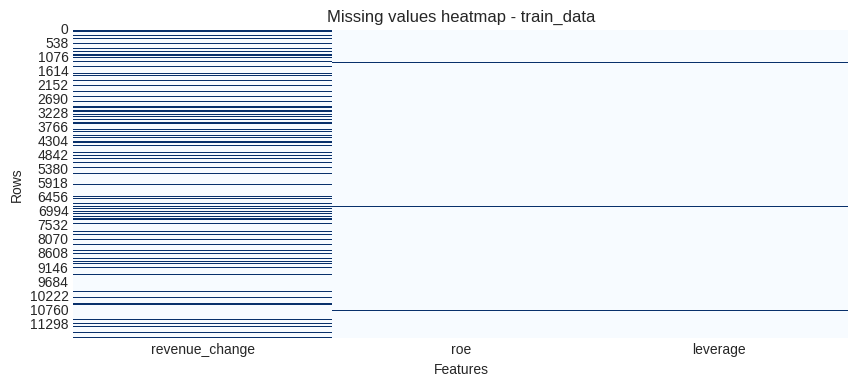

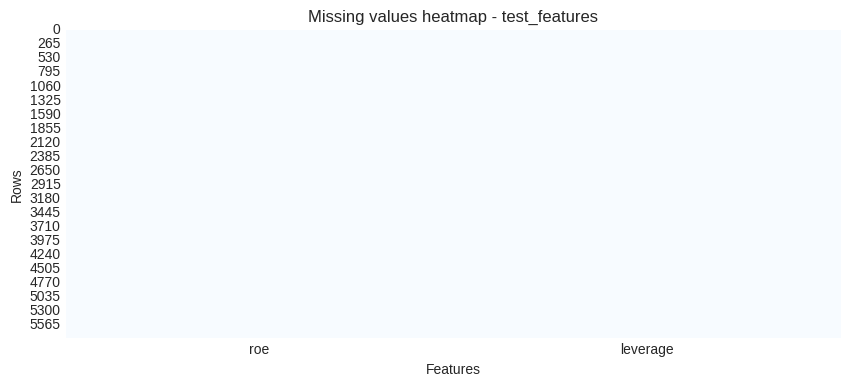

In [35]:
cols_with_na_train = missing_df_train.index.tolist()

if len(cols_with_na_train) > 0:
  fig, ax = plt.subplots(figsize=(10,4))
  ax.set_facecolor("white")
  fig.set_facecolor("white")
  sns.heatmap(train[cols_with_na_train].isnull(),
              cbar=False,
              cmap="Blues",
              ax=ax)
  plt.title("Missing values heatmap - train_data")
  plt.xlabel("Features")
  plt.ylabel("Rows")
  plt.show()



cols_with_na_test = missing_df_test.index.tolist()

if len(cols_with_na_test) > 0:
  fig, ax = plt.subplots(figsize=(10,4))
  ax.set_facecolor("white")
  fig.set_facecolor("white")
  sns.heatmap(test[cols_with_na_test].isnull(),
              cbar=False,
              cmap="Blues",
              ax=ax)
  plt.title("Missing values heatmap - test_features")
  plt.xlabel("Features")
  plt.ylabel("Rows")
  plt.show()





The heatmaps confirm these patterns visually:

- In the training heatmap, the vertical band for `revenue_change` shows many
  dark lines spread across the rows, indicating that missing values are
  scattered across different firms and years rather than concentrated in a
  single block. This suggests a general reporting issue for this indicator.
- The columns `roe` and `leverage` show much fewer dark lines,
  consistent with their lower missing percentages.
- In the test heatmap, only `roe` and `leverage` display missing
  values, and again the amount is limited.

Overall, these checks tell us that:
- `revenue_change` is the only feature with a large missingness problem and will
  require a clear decision (e.g. keep with imputation, or drop it if it does not
  add much information).
- The other variables (`roe`, `leverage`) can be safely handled with
  simple imputation techniques without heavily distorting the dataset.

This understanding of missing values will guide the preprocessing choices we
make later.

## **6. Target variable `bankruptcy_next_year` analysis**



In this step we analyse the target variable to understand **how rare bankruptcy is** in our
dataset. In a bankruptcy prediction problem we usually have a strong class imbalance:
most firms survive, only a very small fraction actually goes bankrupt.

Understanding this imbalance is crucial because:

- it affects which metrics we should use (F1, recall, precision) and not only accuracy;
- it shows how "hard" it is for a model to detect bankrupt firms;
- it helps us interpret all the following distributions, always remembering that the
  bankrupt class is a small minority.

The code below prints the number of healthy vs bankrupt firms, the overall bankruptcy
rate, and a bar plot of the class distribution.


Bankruptcy Distribution:
bankruptcy_next_year
0    11744
1       84
Name: count, dtype: int64

Bankruptcy rate: 0.71%


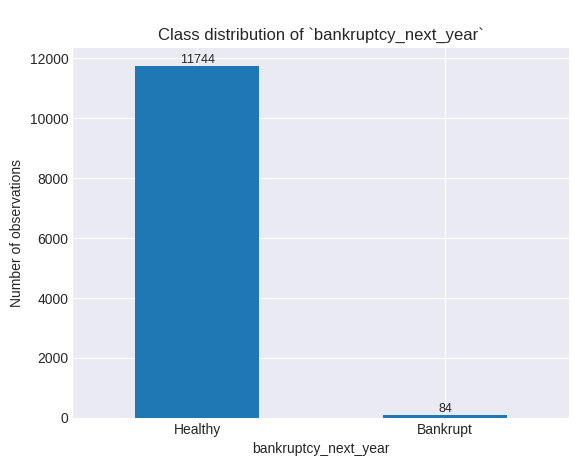

In [36]:
fig, ax = plt.subplots()

print("Bankruptcy Distribution:")
print(train["bankruptcy_next_year"].value_counts())
print(f"\nBankruptcy rate: {train['bankruptcy_next_year'].mean():.2%}")

target_counts = train["bankruptcy_next_year"].value_counts()
target_counts.index = target_counts.index.map({0: "Healthy", 1: "Bankrupt"})

target_counts.plot(kind='bar', ax=ax)

ax.set_ylabel("Number of observations")
ax.set_title("\nClass distribution of `bankruptcy_next_year`")
plt.xticks(rotation=0)

for p in ax.patches:
    value = int(p.get_height())
    ax.annotate(f"{value}",
                (p.get_x() + p.get_width()/2., value),
                ha='center', va='bottom', fontsize=9)

plt.show()


**Interpretation of the results**

The printed counts and the bar plot show that:

- there are **11,744 healthy firms** (`bankruptcy_next_year = 0`);
- there are only **84 bankrupt firms** (`bankruptcy_next_year = 1`);
- the overall bankruptcy rate is about **0.71%** of the observations.

This confirms a **very strong class imbalance**: the event we want to predict
(bankruptcy within 12 months) is rare compared to the number of non-bankrupt firms.
As a consequence, a naive model that always predicts "Healthy" would already have
very high accuracy, but would be useless for detecting real bankruptcies. This is
why later we will focus on metrics such as F1-score and recall for the bankrupt class,
and consider techniques like class weights or threshold tuning.

**Link to macroeconomic shocks**

The very low bankruptcy rate (0.71%) is also informative when we read it in the
context of the macroeconomic shocks that hit Italian firms between 2018 and 2021.
During this period, companies were exposed to a sequence of adverse events like
the COVID-19 pandemic.

However, the data show that **most firms did not formally default** within the
12-month horizon covered by our target. This is consistent with the idea that:

1. **Shocks affect all firms, but not all in the same way.**  
   Revenue losses, higher production costs and more expensive debt put pressure
   on balance sheets across the board, but only the most fragile firms  
   (high leverage, low liquidity, weak profitability) are pushed over the edge
   into bankruptcy. Our 84 bankrupt observations are precisely this small group.

2. **Policy support and financial flexibility slow down default.**  
   In the COVID years, government support schemes, loan guarantees and temporary
   moratoria helped many distressed firms to avoid immediate default. Similarly,
   banks may have restructured or rolled over loans instead of forcing formal
   bankruptcy. As a result, the impact of the shocks appears more clearly in
   deteriorated financial ratios than in a large wave of legal bankruptcies.

3. **Bankruptcy is the "tip of the iceberg" of financial distress.**  
   The macro shocks leave a strong footprint in the distributions of leverage,
   liquidity and profitability (which we analyse later), while the target
   variable only captures the extreme outcome where distress becomes unsustainable.
   This explains why the bankrupt class remains small even after several crisis
   episodes: many firms are weakened, but only a few actually fail.

In summary, the rare-event nature of `bankruptcy_next_year = 1` is not a sign that
macroeconomic shocks were unimportant; rather, it tells us that these shocks act
as a **stress test on already vulnerable firms**. The goal of our model is to use
the information in financial statements to detect exactly those companies that are
unable to absorb the shocks and end up in bankruptcy.


##**7. Firm-Level Patterns Across Macroeconomic Regimes**

The following exploratory analysis is not interpreted as purely cross-sectional, because firm-level financial distributions are also shaped by the macroeconomic environment in which firms operate. For this reason, we explicitly account for three macroeconomic regimes affecting the Italian economy during the observation window:

- **2018-2019: normal risk environment**  
  This period represents the baseline context, in which bankruptcy risk mainly reflects ordinary firm-specific weaknesses rather than a major systemic shock.

- **2020: COVID-19 with strong support measures**  
  This year captures the pandemic shock combined with extraordinary public intervention, including guarantees, moratoria, and other emergency measures that may have delayed formal bankruptcies despite significant financial stress.

- **2021: partial normalisation and lagged effects**  
  This phase reflects the gradual withdrawal of emergency support and the emergence of delayed distress, as some vulnerable firms could no longer avoid default.

The cell below creates a new categorical variable that assigns each observation to one of these three macroeconomic shock regimes based on `fiscal_year`. This allows the subsequent distributions to be visualised not only in aggregate form, but also by macroeconomic context.

As a result, the following plots will show whether variables such as size, leverage, liquidity, profitability, sector composition, and bankruptcy incidence remain stable across years or instead shift under different macroeconomic conditions. In this way, the EDA highlights that the same financial indicator may carry a different interpretation depending on the shock environment in which firms are observed.

In [37]:
def assign_macro_shock(year):
    if year in [2018, 2019]:
        return "2018-2019: normal risk environment"
    elif year == 2020:
        return "2020: COVID-19 with strong support measures"
    elif year == 2021:
        return "2021: partial normalisation and lagged effects"
    else:
        return "Other"

train_eda = train.copy()
train_eda["macro_shock"] = train_eda["fiscal_year"].apply(assign_macro_shock)

shock_order = [
    "2018-2019: normal risk environment",
    "2020: COVID-19 with strong support measures",
    "2021: partial normalisation and lagged effects"
]

# Keep only the years used in the EDA narrative
train_eda = train_eda[train_eda["macro_shock"].isin(shock_order)].copy()

print(train_eda["macro_shock"].value_counts())


macro_shock
2018-2019: normal risk environment                5940
2020: COVID-19 with strong support measures       2956
2021: partial normalisation and lagged effects    2932
Name: count, dtype: int64


The output confirms that the macroeconomic-regime variable has been created correctly and that each observation has been assigned to one of the three shock periods used in the analysis.

In particular, the largest group is **2018-2019: normal risk environment** with **5,940 observations**, which represents the baseline macroeconomic context before the pandemic shock. The other two groups are **2020: COVID-19 with strong support measures** with **2,956 observations** and **2021: partial normalisation and lagged effects** with **2,932 observations**.

This distribution is coherent with the structure of the dataset: the pre-shock period covers two fiscal years and therefore contains more observations, while 2020 and 2021 are each represented by a single year. As a result, the following visualisations can compare firm-level distributions across distinct macroeconomic regimes, while keeping in mind that the baseline period is larger than each of the two individual shock years.

## **8. Exploratory Data Analysis (EDA)**

###**8.1 Bankruptcy rate by `fiscal_year`**


Here we look at **how the bankruptcy rate changes over time**, by computing the
share of firms with `bankruptcy_next_year = 1` in each fiscal year (2018-2021).

This is important because:

- it tells us whether some years are *riskier* than others;
- it helps us see if there is any visible effect of major macroeconomic shocks
  (e.g. COVID-19) on the probability of default;
- it prepares the ground for a **temporal validation strategy**, where we train
  on earlier years and validate on a later year.

The code below groups the training data by `fiscal_year`, computes the mean of
`bankruptcy_next_year` (i.e. the default rate), and plots the result as a line chart.
It also prints the exact value of the bankruptcy rate for each year.

In [38]:
yearly_bankruptcy = (
    train_eda.groupby("fiscal_year")["bankruptcy_next_year"]
    .mean()
    .reset_index(name="bankruptcy_rate")
)

shock_palette = {
    "2018-2019: normal risk environment": "#4C72B0",
    "2020: COVID-19 with strong support measures": "#DD8452",
    "2021: partial normalisation and lagged effects": "#55A868"
}

fig = go.Figure()

# Segment 2018-2019
seg_1 = yearly_bankruptcy[yearly_bankruptcy["fiscal_year"].isin([2018, 2019])]
fig.add_trace(go.Scatter(
    x=seg_1["fiscal_year"],
    y=seg_1["bankruptcy_rate"],
    mode="lines+markers+text",
    name="2018-2019: normal risk environment",
    line=dict(color=shock_palette["2018-2019: normal risk environment"], width=3),
    marker=dict(size=9, color=shock_palette["2018-2019: normal risk environment"]),
    text=[f"{v:.2%}" for v in seg_1["bankruptcy_rate"]],
    textposition="top center",
    hovertemplate="Fiscal year: %{x}<br>Bankruptcy rate: %{y:.2%}<extra></extra>"
))

# Segment 2019-2020
seg_2 = yearly_bankruptcy[yearly_bankruptcy["fiscal_year"].isin([2019, 2020])]
fig.add_trace(go.Scatter(
    x=seg_2["fiscal_year"],
    y=seg_2["bankruptcy_rate"],
    mode="lines+markers+text",
    name="2020: COVID-19 with strong support measures",
    line=dict(color=shock_palette["2020: COVID-19 with strong support measures"], width=3),
    marker=dict(size=9, color=shock_palette["2020: COVID-19 with strong support measures"]),
    text=[f"{v:.2%}" for v in seg_2["bankruptcy_rate"]],
    textposition="top center",
    hovertemplate="Fiscal year: %{x}<br>Bankruptcy rate: %{y:.2%}<extra></extra>"
))

# Segment 2020-2021
seg_3 = yearly_bankruptcy[yearly_bankruptcy["fiscal_year"].isin([2020, 2021])]
fig.add_trace(go.Scatter(
    x=seg_3["fiscal_year"],
    y=seg_3["bankruptcy_rate"],
    mode="lines+markers+text",
    name="2021: partial normalisation and lagged effects",
    line=dict(color=shock_palette["2021: partial normalisation and lagged effects"], width=3),
    marker=dict(size=9, color=shock_palette["2021: partial normalisation and lagged effects"]),
    text=[f"{v:.2%}" for v in seg_3["bankruptcy_rate"]],
    textposition="top center",
    hovertemplate="Fiscal year: %{x}<br>Bankruptcy rate: %{y:.2%}<extra></extra>"
))

fig.update_layout(
    title="Bankruptcy Rate by Fiscal Year and Macroeconomic Regime",
    xaxis_title="Fiscal year",
    yaxis_title="Bankruptcy rate",
    template="plotly_white",
    legend_title="Macroeconomic regime",
    width=950,
    height=500
)

fig.update_xaxes(
    tickmode="array",
    tickvals=sorted(yearly_bankruptcy["fiscal_year"].unique())
)

fig.update_yaxes(
    tickformat=".2%"
)

fig.show()


**Interpretation of the results**

The table below the plot shows that the bankruptcy rate is always around **0.5-0.8%**,
with some small variation across years:

- 2018: **0.78%**
- 2019: **0.81%** (slightly higher)
- 2020: **0.54%** (noticeable drop)
- 2021: **0.72%** (partial rebound)

So, even at its "peak", the default rate remains below 1%, but it does not stay
perfectly constant over time.

**Link to macroeconomic shocks**

The small changes in the bankruptcy rate over time can be read in light of the
shocks that hit the Italian economy:

- **2018-2019 - normal risk environment**  
  Default rates around 0.8% are consistent with a "baseline" level of failures:
  firms go bankrupt mainly because of structural weaknesses (business model,
  leverage, low profitability), not because of a systemic shock.

- **2020 - COVID-19 with strong support measures**  
  Despite the pandemic, the bankruptcy rate **drops to 0.54%**. This reflects
  the effect of emergency policies (grants, guarantees, moratoria) and more
  accommodating banks, which **delay many formal bankruptcies** even though
  balance sheets are under heavy stress.

- **2021 - partial normalisation and lagged effects**  
  The rate rises again to about **0.72%**, closer to pre-COVID levels. As support
  measures are gradually reduced and new pressures emerge (supply-chain and
  energy issues), some firms that were kept alive in 2020 can no longer avoid
  default.

In summary, the shocks mainly show up as **deterioration in financial ratios**
and only with a delay in the observed default rate. This motivates our focus on
balance-sheet indicators (leverage, liquidity, profitability) as early warning
signals of bankruptcy.


###**8.2 Sectoral and geographic coverage**

Before looking at bankruptcy risk, we first need to understand **which firms we
are analysing**. In this section we describe the composition of the training set
along two key dimensions:

- the **business sector** of each firm (`ateco_sector`);
- the **Italian region** where the firm is located (`region`).

Knowing how observations are distributed across sectors and regions is crucial
for two reasons. First, it tells us where the dataset puts most of its "weight":
if a few sectors or regions dominate, they will largely drive the patterns we
see in the financial ratios and in bankruptcy outcomes. Second, it helps us
anticipate **where macroeconomic shocks are likely to leave the strongest
footprint** in the data (for example, in industrial or tourism-intensive areas).

The code below plots the top 10 ATECO sectors and the top 10 regions by number
of observations in the training set.




In [39]:
sorted(train["ateco_sector"].unique())

[np.int64(10),
 np.int64(25),
 np.int64(41),
 np.int64(43),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(56),
 np.int64(62),
 np.int64(68),
 np.int64(71),
 np.int64(77),
 np.int64(82)]

In [40]:
# ATECO legend
ateco_labels = {
    45: "Motor trade & repair",
    46: "Wholesale trade (excl. vehicles)",
    47: "Retail trade (excl. vehicles)",
    41: "Building construction",
    43: "Specialised construction work",
    25: "Metal products (non-machinery)",
    10: "Food manufacturing",
    62: "Software & IT consulting",
    56: "Restaurants & catering",
    71: "Architecture & engineering",
    68: "Real estate activities",
    77: "Rental & leasing",
    82: "Business support services"
}

train["ateco_sector_label"] = train["ateco_sector"].map(ateco_labels)


[ISTAT ATECO 2007 CLASSIFICATION ](https://f-digital.co/wp-content/uploads/2024/03/CODICI-ATECO-2007-ELENCO-RIEPILOGATIVO-DI-TUTTI-I-COMPARTI.pdf)

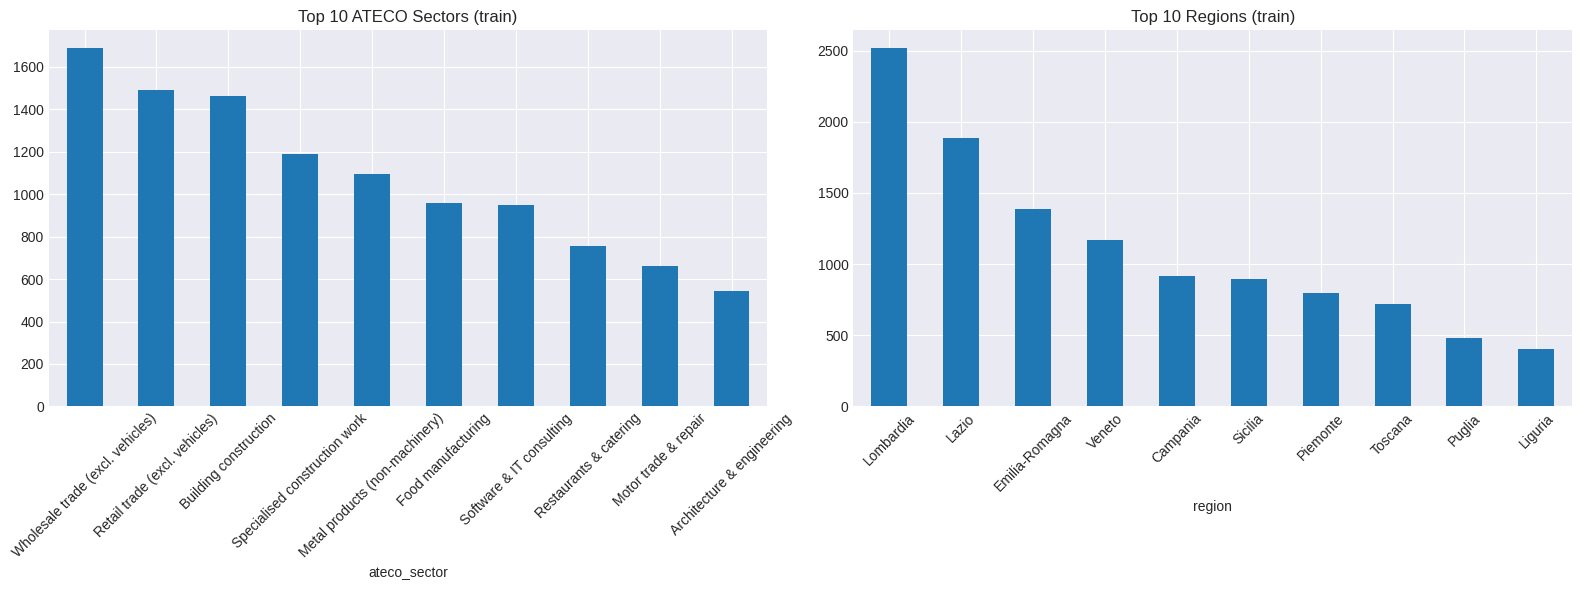

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 ATECO sectors by number of firms
train["ateco_sector_label"].value_counts().head(10).plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Top 10 ATECO Sectors (train)")
axes[0].set_xlabel("ateco_sector")
axes[0].tick_params(axis="x", rotation=45)

# Top 10 regions by number of firms
train["region"].value_counts().head(10).plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Top 10 Regions (train)")
axes[1].set_xlabel("region")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation of the results**

- On the **sector** side, a small number of ATECO sectors accounts for most of
  the observations. Wholesale trade (code 46), retail trade (47) and building
  construction (41) each exceed 1,400 firm-years in the training set. They are
  followed by specialised construction activities (43), metal-product
  manufacturing (25) and the food industry (10), with almost 1,000 observations
  each. IT and software services (62), restaurants and catering (56), motor
  trade and repair (45) and architectural/engineering services (71) close the
  top-10 with between 500 and 900 firm-years. This means that our dataset is
  heavily concentrated in classic **trade and construction** activities, plus a
  few important service sectors.

- On the **regional** side, a similar concentration appears:
  - **Lombardia** clearly dominates, followed by **Lazio** and **Emilia-Romagna**;
  - other regions such as **Veneto**, **Campania**, **Sicilia** and **Piemonte**
    still have several hundred observations, but noticeably fewer than Lombardia;
  - the tail of the distribution contributes
    relatively few firms.

In short, the dataset mainly reflects firms located in the economically stronger
regions of Northern and Central Italy and operating in a limited set of ATECO
sectors.



### **8.3 Bankruptcy risk by business sector and geographic region**


After looking at how many observations we have in each sector and region, we now
focus on **how the bankruptcy rate itself varies across these groups**.

Concretely, we:

- compute the bankruptcy rate (`share of bankruptcy_next_year = 1`) for the
  **top 10 ATECO sectors** in terms of number of observations;
- compute the same rate for **each region**, and sort regions from highest to
  lowest risk.

This allows us to see whether some sectors or regions are systematically more
fragile than others, which is essential for interpreting the impact of
macroeconomic shocks and for deciding how to use `ateco_sector` and `region`
as features in the model.

In [42]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Define top_regions based on previous EDA for regions count
top_regions = train_eda["region"].value_counts().head(10).index.tolist()

region_agg = (
    train_eda.groupby(["region", "macro_shock"], as_index=False)["bankruptcy_next_year"]
    .mean()
)

fig_region = px.bar(
    region_agg,
    x="region",
    y="bankruptcy_next_year",
    color="macro_shock",
    category_orders={
        "macro_shock": shock_order,
        "region": top_regions
    },
    color_discrete_map=shock_palette,
    barmode="group",
    title="Bankruptcy Rate by Region (Top 10 - train) and Macroeconomic Regime",
    labels={
        "region": "",
        "bankruptcy_next_year": "Bankruptcy Rate",
        "macro_shock": "Macroeconomic regime"
    },
    hover_data={
        "region": True,
        "macro_shock": True,
        "bankruptcy_next_year": ':.2%'
    }
)

fig_region.update_layout(template="plotly_white", width=1000, height=550)
fig_region.update_xaxes(tickangle=45)
fig_region.update_yaxes(tickformat=".2%")

fig_region.show()

**Interpretation of the sector results**

The bar plot for the top 10 ATECO sectors shows that the bankruptcy rate ranges
roughly between **0.4% and 1.2%**:

- **Motor trade, retail and wholesale** stand out as the riskiest activities:
  firms in the motor trade and repair sector (code **45**) and in retail trade
  (47) have the highest default rates, around **1.1-1.2%**, while wholesale
  trade (46) is also in the upper part of the distribution.
- The **food industry** (10) is relatively risky as well, with a rate just
  below **1%**, reflecting thin margins and high exposure to demand and cost
  shocks.
- **Building construction** (41) and **specialised construction activities**
  (43) sit in the middle, with default rates around **0.4-0.5%**.
- **Restaurants and catering** (56), **software and IT services** (62) and
  **architectural and engineering services** (71) are at the lower end, with
  default rates clearly below **0.6%**.

Even within the same country and period, some sectors have almost **three
times** the bankruptcy rate of others. This confirms that sector risk is not
just noise: the ATECO code carries systematic information about how fragile
firms are.

**Link to macroeconomic shocks**

These sector differences are consistent with how the 2018-2023 shocks hit the
Italian economy:

- **Motor trade and retail/wholesale trade** (45, 47, 46) combine high exposure
  to **COVID demand drops and mobility restrictions** with sensitivity to
  **energy-price increases** along the supply chain. Firms in these sectors
  have to manage both lower revenues and higher operating costs, which makes
  them more likely to slide into default.
- The **food industry** (10) is vulnerable to higher input and energy costs and
  to changes in consumption patterns, which can quickly compress margins.
- Sectors such as **IT and software services** (62), **architecture and
  engineering** (71) and, to a lesser extent, **restaurants and catering**
  (56) appear more resilient in our data, either because they could adapt more
  easily to remote work and new business models or because they benefited from
  the rebound after COVID restrictions.

From a modelling perspective, this justifies including `ateco_sector` (via
one-hot encoding) so that the model can assign **higher predicted risk** to
firms operating in historically more fragile sectors like trade and motor
services, and lower risk to structurally more resilient sectors.


**Interpretation of the regional results**

The regional bar chart shows a clear ranking of bankruptcy rates across Italian
regions, with values roughly between **0.4% and 1.1%**:

- **Emilia-Romagna** has the highest rate, around **1.1%**, followed closely by
  **Liguria** (~**1.0%**);
- **Campania** and **Sardegna** follow, with rates around **0.8-0.9%**;
- **Veneto**, **Lazio** and **Sicilia** are in the middle, around **0.7-0.8%**;
- **Lombardia** and **Puglia** are slightly below this, around **0.6-0.65%**;
- **Umbria**, **Toscana**, **Piemonte** and **Friuli-Venezia Giulia** show the
  **lowest rates**, between **0.35% and 0.5%**.

Again, the differences are not huge in absolute terms, but some regions have
**almost three times the default rate of others**, which is economically
meaningful.

**Link to macroeconomic shocks**

These regional patterns can be related to how shocks propagate through local
economies:

- Regions such as **Emilia-Romagna and Liguria**, with strong **industrial and
  logistics/port activity**, are more sensitive to **energy-price shocks and
  supply-chain disruptions**, which can explain their higher bankruptcy rates.
- Regions with a higher weight of **tourism and services** (e.g. **Campania,
  Sardegna, Liguria, Lazio, Sicilia**) were more exposed to **COVID-19
  restrictions and mobility changes**, which hit many contact-intensive
  businesses.
- Regions like **Piemonte, Friuli-Venezia Giulia, Toscana or Umbria** show
  lower default rates, possibly reflecting more diversified economies, less
  energy-intensive production or a better adaptation of local firms to the new
  environment.



Taken together, the regional analysis confirms that the impact of macro shocks
is **not spatially neutral**: certain combinations of **sector x region** are
systematically more fragile. This supports the decision to keep both `region`
and `ateco_sector` as features in the predictive model.

### **8.4 Firm size: `total_assets` and `production_value`**


In this section we look at **how big the firms in our dataset are**, using two
basic measures of size:

- the balance sheet side: `total_assets`;
- the income/production side: `production_value` (turnover / value of production).

Firm size matters for bankruptcy risk because:

- **small and medium enterprises (SMEs)** usually have less cash, weaker access
  to credit and fewer buffers, so they are more vulnerable to shocks;
- **large firms** can absorb one or two bad years more easily, but if they fail
  the macro impact is much larger.

The code below plots, for each variable, the histogram in **levels** and the
histogram after a **log(1 + x) transformation**, to see both the raw scale and
a more "regular" version suitable for modelling.


In [43]:
import plotly.express as px
import plotly.graph_objects as go

shock_palette = {
    "2018-2019: normal risk environment": "#4C72B0",
    "2020: COVID-19 with strong support measures": "#DD8452",
    "2021: partial normalisation and lagged effects": "#55A868"
}

for col in ['total_assets', 'production_value']:
    # Level distribution
    fig_level = px.histogram(
        train_eda,
        x=col,
        color="macro_shock",
        category_orders={"macro_shock": shock_order},
        color_discrete_map=shock_palette,
        nbins=50,
        opacity=0.75,
        barmode="overlay",
        title=f"{col} (level) by macroeconomic shock"
    )

    fig_level.update_layout(
        legend_title_text="Macro shock",
        bargap=0.05,
        template="plotly_white"
    )

    fig_level.show()

    # Log distribution
    plot_df = train_eda.loc[train_eda[col] >= 0, [col, "macro_shock"]].copy()
    plot_df[f"log_{col}"] = np.log1p(plot_df[col])

    fig_log = px.histogram(
        plot_df,
        x=f"log_{col}",
        color="macro_shock",
        category_orders={"macro_shock": shock_order},
        color_discrete_map=shock_palette,
        nbins=50,
        opacity=0.75,
        barmode="overlay",
        title=f"log(1 + {col}) by macroeconomic shock"
    )

    fig_log.update_layout(
        legend_title_text="Macro shock",
        bargap=0.05,
        template="plotly_white"
    )

    fig_log.show()


**Interpretation of the results**

- In **level** (left-hand plots) both `total_assets` and `production_value` are
  **strongly right-skewed**: almost all firms are concentrated very close to
  zero, while a small number of very large firms extend the scale far to the
  right. This is exactly what we expect in a real economy with many SMEs and
  a few giants.

- After applying `log(1 + x)` (right-hand plots), the distributions become
  much more symmetric and "bell-shaped". The log transform compresses the
  differences between very large firms and very small ones, creating a scale
  where most observations are spread more evenly.

- We do not see obvious separate peaks or gaps, which suggests a **continuum
  of firm sizes** rather than distinct "classes" with empty ranges in between.

Overall, the EDA indicates that our dataset is dominated by relatively small
firms, with a long tail of larger companies.




**Link to macroeconomic shocks**

Firm size is a key lens to interpret the shocks of 2018-2021:

- **Smaller firms**, with lower assets and production volumes, have thinner
  financial buffers and weaker bargaining power with banks. When revenues fall
  or costs rise, they can run out of liquidity quickly and become prime
  candidates for bankruptcy.

- **Larger firms** usually have more diversified activities and easier access
  to funding, so they withstand stress for longer. However, their global supply
  chains and energy needs mean that severe and persistent shocks can still
  compress margins and increase leverage.

Given that the empirical distribution is heavily tilted towards **SMEs**, it is
plausible that later we will see fat left tails in profitability and liquidity:
macro shocks push an already large group of small and fragile firms further
into distress.


### **8.5 Debt structure and leverage: `total_debt`, `debt_to_assets`, `leverage`**



In this section we focus on **how much firms rely on debt** and how risky their
capital structure looks. We use three related variables:

- `total_debt` - absolute amount of debt on the balance sheet;
- `debt_to_assets` - share of total assets financed with debt;
- `leverage` - debt-to-equity ratio.

For bankruptcy prediction, leverage is a key driver: the more debt a firm has
(relative to its assets and equity), the more sensitive it becomes to shocks
that hit profits and interest rates. If earnings fall or the cost of debt rises,
highly leveraged firms are the first to get into trouble.

The code below plots, for each of these three variables, the histogram in
**levels** and the histogram after a **log(1 + x) transformation**.

In [44]:
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go

for col in ['total_debt', 'debt_to_assets', 'leverage']:
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            f"Distribution of {col} by macroeconomic shock",
            f"log(1 + {col}) by macroeconomic shock"
        )
    )

    # LEFT: level
    for shock in shock_order:
        subset = train_eda.loc[train_eda["macro_shock"] == shock, col].dropna()
        fig.add_trace(
            go.Histogram(
                x=subset,
                name=shock,
                marker_color=shock_palette[shock],
                histnorm="probability density",
                nbinsx=50,
                opacity=1
            ),
            row=1, col=1
        )

    # RIGHT: log
    for shock in shock_order:
        subset = train_eda.loc[
            (train_eda["macro_shock"] == shock) & (train_eda[col] >= 0),
            col
        ].dropna()
        fig.add_trace(
            go.Histogram(
                x=np.log1p(subset),
                name=shock,
                marker_color=shock_palette[shock],
                histnorm="probability density",
                nbinsx=50,
                opacity=1,
                showlegend=False
            ),
            row=1, col=2
        )

    fig.update_layout(
        template="plotly_white",
        barmode="stack",
        width=1200,
        height=450,
        legend_title="Macroeconomic regime",
        title_text=f"{col}: level and log distributions by macroeconomic shock"
    )

    fig.update_xaxes(title_text=col, row=1, col=1)
    fig.update_xaxes(title_text=f"log(1 + {col})", row=1, col=2)
    fig.update_yaxes(title_text="Density", row=1, col=1)
    fig.update_yaxes(title_text="Density", row=1, col=2)

    fig.show()


**Interpretation of the results**

- For `total_debt` (top row), the level distribution is **extremely right-skewed**:
  most firms have relatively small amounts of debt, while a small group carries
  very large debts. After the log transform, the distribution becomes much more
  symmetric, indicating that `log(1 + total_debt)` is a more suitable scale for
  modelling.

- For `debt_to_assets` (middle row), most firms cluster in a band roughly between
  **0.4 and 0.8**, meaning that 40-80% of their assets are financed by debt.
  There is also a **thin right tail** with values close to or above 1, which is
  unusual (debt as large as or larger than total assets) and signals firms that
  are very highly geared or have accounting issues. The log transform smooths
  the shape but the concentration around high debt shares remains visible.

- For `leverage` (bottom row), the level distribution shows that:
  - a large majority of firms have leverage in a relatively low range (e.g. 0-5);
  - a **few extreme outliers** reach very high values (above 20, 50 or even 100),
    which often corresponds to firms with almost zero equity.
  In the log scale, we see a long right tail: most firms have moderate leverage,
  but a non-negligible subset is **heavily over-leveraged**.

Together, these plots tell us that the dataset contains many firms with a
standard debt profile, but also a smaller group with **very aggressive debt
ratios**. These highly indebted firms are natural candidates for bankruptcy.




**Link to macroeconomic shocks and bankruptcy risk**

The shape of these debt ratios fits well with the macro environment:

- During the COVID phase many firms took on **additional debt** to bridge the
  revenue collapse, pushing some observations further to the right in
  `total_debt` and increasing both `debt_to_assets` and `leverage`.


In summary, long right tails and outliers in these ratios identify firms that
entered or exited the shock period with a **heavy debt burden**-exactly the
companies we expect to see more often in the bankrupt class.


### **8.6 Short-term liquidity: `current_ratio` and `quick_ratio`**



Here we analyze **how well firms can cover their short-term debts with their
short-term assets**, using two standard liquidity ratios:

- `current_ratio = current_assets / short_term_debt`
- `quick_ratio  = (current_assets - inventory) / short_term_debt`

A value around **1** is often used as a rough threshold:
- if the ratio is **below 1**, current assets are not enough to repay
  all short-term liabilities;
- if it is **well above 1**, the firm has a comfortable liquidity buffer.

For bankruptcy prediction, liquidity is often the spark that triggers default:
even a business that is not "rotten" in terms of long-run profitability can go
bankrupt if it cannot pay its bills on time.

The code below plots the distribution of `current_ratio` and `quick_ratio`
and draws a **vertical red line at 1** to highlight the short-term solvency
threshold.


In [45]:
import plotly.express as px
import plotly.graph_objects as go

for col in ['current_ratio', 'quick_ratio']:
    fig = px.histogram(
        train_eda,
        x=col,
        color="macro_shock",
        category_orders={"macro_shock": shock_order},
        color_discrete_map=shock_palette,
        nbins=50,
        histnorm="probability density",
        barmode="stack",
        title=f"Distribution of {col} by macroeconomic shock"
    )

    # Add threshold line at x = 1
    fig.add_vline(
        x=1,
        line_width=2,
        line_dash="dash",
        line_color="red"
    )

    # Optional annotation for threshold
    fig.add_annotation(
        x=1,
        y=1,
        yref="paper",
        text="threshold 1",
        showarrow=False,
        xanchor="left",
        yanchor="bottom",
        font=dict(color="red", size=10)
    )

    fig.update_layout(
        template="plotly_white",
        legend_title="Macroeconomic regime",
        width=950,
        height=450,
        bargap=0.02
    )

    fig.update_xaxes(title_text=col)
    fig.update_yaxes(title_text="Density")

    fig.show()


**Interpretation of the results**

- For both `current_ratio` and `quick_ratio`, most observations lie **to the
  right of the red line at 1**. This means that, in "normal" times, the
  typical firm in the dataset has enough current assets to cover its
  short-term debt.

- There is still a **non-negligible mass of firms with ratios below 1**:
  these are companies that already enter the period with tight liquidity.
  They may survive as long as cash inflows are stable, but they have very
  little room for adverse shocks.

- The right tails show some firms with very high ratios (2, 3 or more),
  indicating large liquidity buffers. These firms are much better positioned
  to absorb temporary drops in revenue or increases in costs.

- As expected, the **quick ratio is generally lower than the current ratio**:
  once inventories are excluded from current assets, some firms move closer to
  the threshold of 1. This highlights the difference between "accounting"
  liquidity and more conservative, cash-like liquidity.

Overall, the distributions suggest a mixed picture: many firms are reasonably
liquid, but a sizeable group sits close to or below the short-term solvency
threshold.




**Link to macroeconomic shocks**

Short-term liquidity is one of the first places where macro shocks bite:

- Revenue drops and delayed payments during COVID tend to **push
  `current_ratio` and `quick_ratio` down**, especially for firms that were
  already close to 1.

- Higher production and energy costs further **drain cash buffers**, while
  rolling over short-term debt becomes more expensive when interest rates rise.

A large mass of firms with `current_ratio < 1` or only slightly above 1
indicates a system that enters these shocks **already under pressure**. Any new
disturbance can easily turn stretched liquidity positions into actual
bankruptcies.


### **8.7 Profitability and bottom line: `net_profit_loss`, `profit_margin`, `roi`, `roe`**



In this section we analyse **how much profit firms are able to generate**, using
four related indicators:

- `net_profit_loss` - bottom-line net result in absolute value;
- `profit_margin` - net profit relative to revenues;
- `roi` - return on assets (profit relative to total assets);
- `roe` - return on equity (profit relative to shareholders' equity).

For bankruptcy prediction, profitability acts as a **cushion against shocks**:
a firm that starts from healthy margins can absorb temporary losses, while a
firm that is already close to zero or in the red can be pushed into default by
a relatively small macro shock.

The code below plots, for each variable, the histogram in **levels** and the
histogram after a **log(1 + x) transformation**, so that we can see both the
raw distribution (including negative values) and a compressed version that
highlights the central mass of observations.


In [46]:
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go

shock_palette = {
    "2018-2019: normal risk environment": "#4C72B0",
    "2020: COVID-19 with strong support measures": "#DD8452",
    "2021: partial normalisation and lagged effects": "#55A868"
}

for col in ['net_profit_loss', 'profit_margin', 'roi', 'roe']:
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            f"Distribution of {col} by macroeconomic shock",
            f"log(1 + {col}) by macroeconomic shock"
        )
    )

    # LEFT: level distribution
    for shock in shock_order:
        subset = train_eda.loc[train_eda["macro_shock"] == shock, col].dropna()
        fig.add_trace(
            go.Histogram(
                x=subset,
                name=shock,
                marker_color=shock_palette[shock],
                histnorm="probability density",
                nbinsx=50,
                opacity=1
            ),
            row=1, col=1
        )

    # RIGHT: log distribution only for non-negative values
    for shock in shock_order:
        subset = train_eda.loc[
            (train_eda["macro_shock"] == shock) & (train_eda[col] >= 0),
            col
        ].dropna()

        fig.add_trace(
            go.Histogram(
                x=np.log1p(subset),
                name=shock,
                marker_color=shock_palette[shock],
                histnorm="probability density",
                nbinsx=50,
                opacity=1,
                showlegend=False
            ),
            row=1, col=2
        )

    fig.update_layout(
        template="plotly_white",
        barmode="stack",
        width=1200,
        height=450,
        legend_title="Macroeconomic regime",
        title_text=f"{col}: level and log distributions by macroeconomic shock"
    )

    fig.update_xaxes(title_text=col, row=1, col=1)
    fig.update_xaxes(title_text=f"log(1 + {col})", row=1, col=2)
    fig.update_yaxes(title_text="Density", row=1, col=1)
    fig.update_yaxes(title_text="Density", row=1, col=2)

    fig.show()


**Interpretation of the results**

- For `net_profit_loss`, the level distribution is strongly asymmetric:
  - most firms cluster around moderately positive net results;
  - there is a **left tail of loss-making firms** with negative net income;
  - a few very profitable firms create a long right tail.
  The log-transformed version compresses the scale, making the central mass of
  firms easier to visualise, but the existence of both gain and loss firms
  remains clear.

- For `profit_margin`, we see a concentration of observations in a relatively
  narrow positive range (for example between 0 and 10%), but with a **visible
  bump of companies with negative margins**. This indicates that a non-trivial
  share of firms is already operating at a loss even before we consider future
  shocks. The distribution is quite wide, suggesting heterogeneous business
  models and exposure to costs.

- `roi` (return on assets) has a shape closer to a bell curve centred on small
  positive values, but again with a **left tail** extending into negative
  returns. Many firms generate modest returns on their asset base, while a
  minority either performs very well or very poorly.

- `roe` (return on equity) is the most extreme: the level distribution shows
  some **very large negative values**. This typically happens when equity is
  very small or close to zero. While not a direct indicator of bankruptcy, this reflects severe financial fragility. In such cases even a small loss generates a huge
  negative ROE. After applying the log transform, most "normal" values are
  compressed into a more regular shape, but the fact that some firms have
  extremely fragile equity positions is clear.

Overall, these distributions tell us that:

- the majority of firms has **positive but relatively thin margins**;
- a significant minority is already in the **loss-making zone** or very close
  to it;
- some firms have **extremely weak equity**, which makes ROE explode on the
  downside and puts them at high risk if conditions worsen.




**Link to macroeconomic shocks and other financial variables**

Macro shocks leave a very direct numerical footprint on profitability:

- COVID-related revenue losses immediately hit `net_profit_loss` and
  `profit_margin`, pushing many firms from small profits into outright losses.

- Supply-chain disruptions and the energy crisis raised `production_costs` and
  operating expenses, squeezing margins and shifting more observations into the
  left side of the `roi` and `roe` distributions.


The unstable shapes and pronounced left tails in these variables can be read as
the **numeric imprint** of these shocks. Firms that end up in the extreme
negative part of the distributions are precisely those for which weak
profitability, high costs and expensive debt make bankruptcy a very plausible
outcome.


### **8.8 Comparison between bankrupt and non-bankrupt firms: leverage, liquidity, margins**

In this section we want to see **how the distributions of key financial
variables change with the target `bankruptcy_next_year`**.

The practical question is: compared with healthy firms (`bankruptcy_next_year = 0`),
do bankrupt firms (`bankruptcy_next_year = 1`) have:

- higher leverage?
- lower liquidity?
- worse profit margins?

If the answer is yes, these variables are strong candidates for the model and
they also confirm the economic story we have in mind: firms that enter the
COVID/energy/interest-rate shocks with weak balance sheets are the ones that
end up defaulting.

The boxplots below compare, for bankrupt vs non-bankrupt firms:

- `leverage` (debt/equity),
- `current_ratio` (short-term liquidity),
- `profit_margin` (profitability).


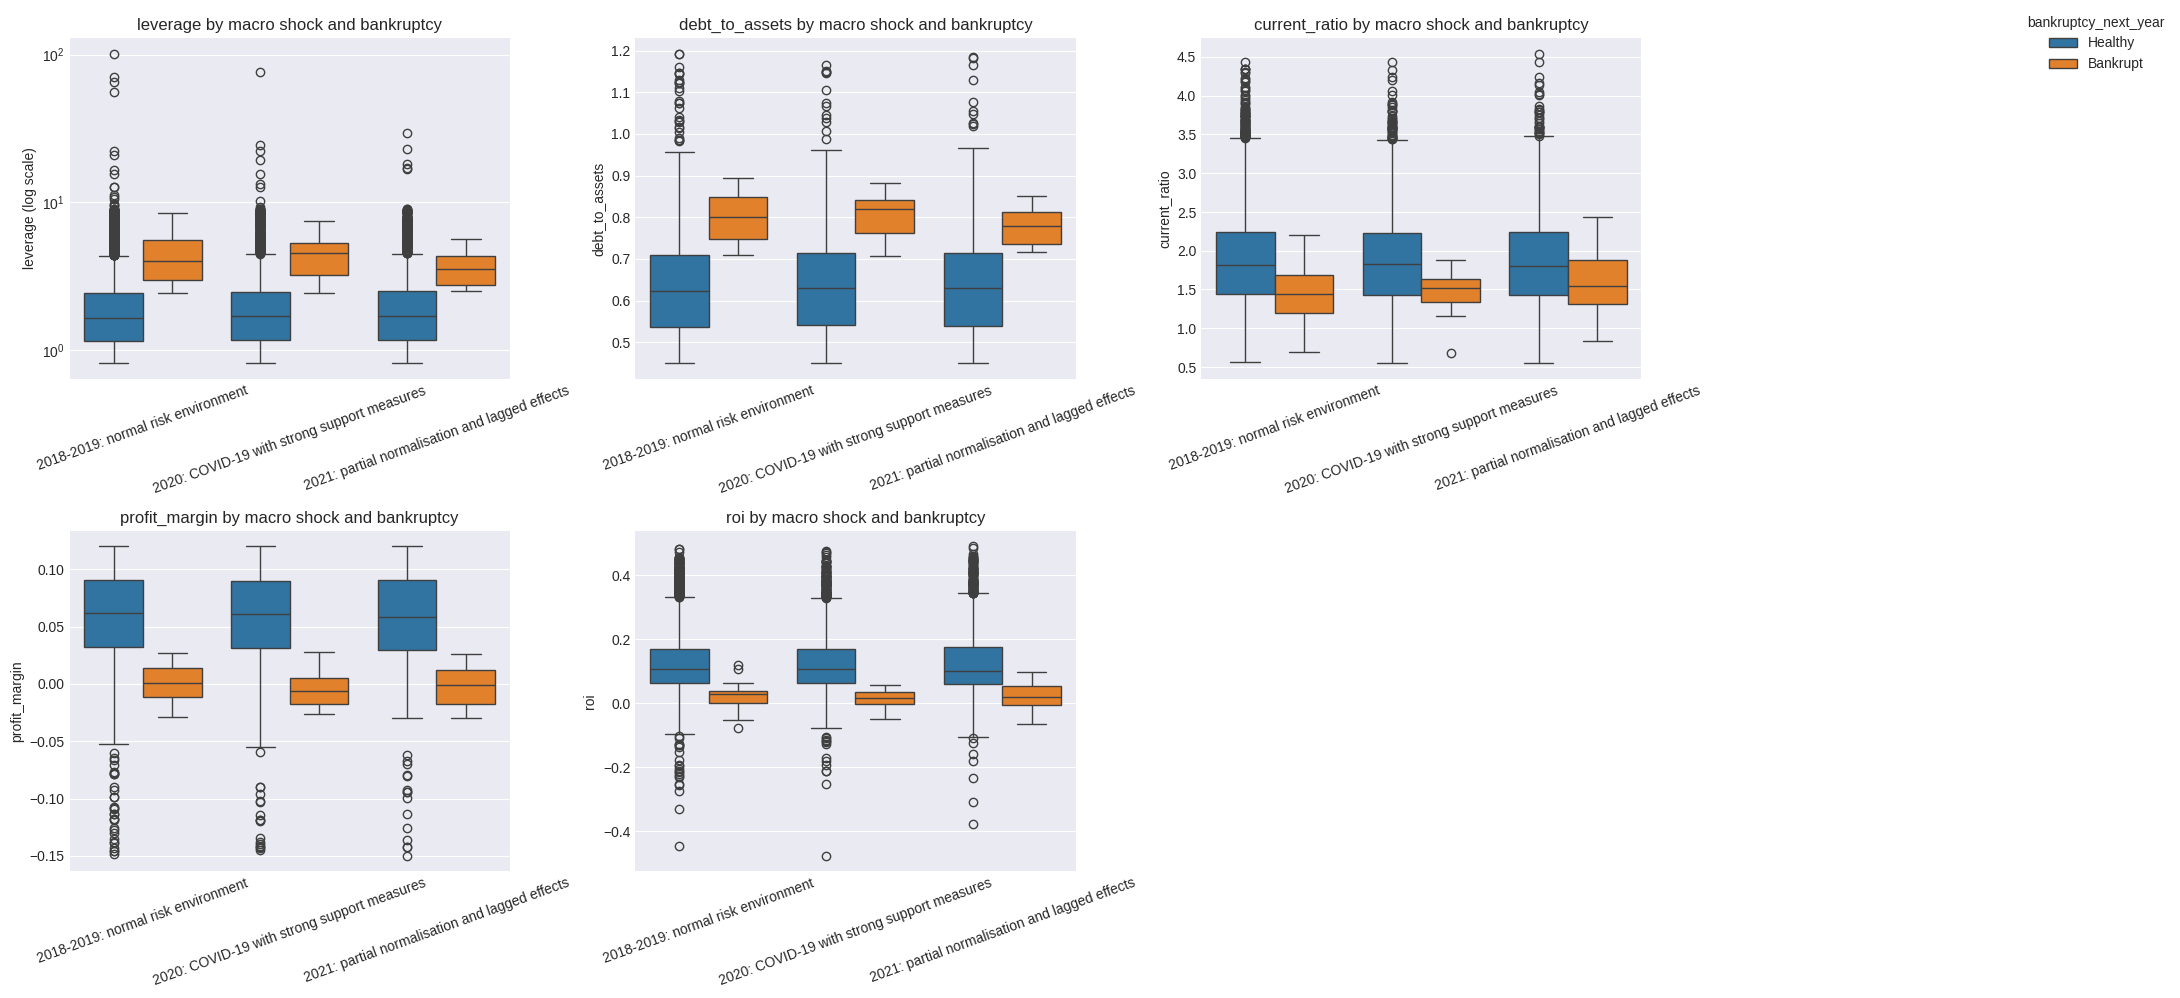

In [47]:
features_to_check = ['leverage', 'debt_to_assets', 'current_ratio', 'profit_margin', 'roi']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

legend_handles = None
legend_labels = None

for i, col in enumerate(features_to_check):
    sns.boxplot(
        data=train_eda,
        x='macro_shock',
        y=col,
        hue='bankruptcy_next_year',
        order=shock_order,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} by macro shock and bankruptcy")
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].set_xlabel("")

    # Make only leverage easier to read
    if col == 'leverage':
        axes[i].set_yscale('log')
        axes[i].set_ylabel("leverage (log scale)")
    else:
        axes[i].set_ylabel(col)

    # Save legend handles only once
    if legend_handles is None:
        legend_handles, legend_labels = axes[i].get_legend_handles_labels()

    # Remove subplot legend
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

# Remove empty last subplot
fig.delaxes(axes[5])

# Create one common legend outside the plot
fig.legend(
    legend_handles,
    ["Healthy", "Bankrupt"],
    title="bankruptcy_next_year",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()

**Interpretation of the results**

- **Leverage vs bankruptcy**  
  The median leverage for bankrupt firms is slightly higher than for healthy
  firms, and the bankrupt group shows **several very high outliers**. This
  suggests that many failed firms were more heavily indebted, and a subset of
  them had extremely fragile equity positions (very high debt/equity).

- **Current ratio vs bankruptcy**  
  Bankrupt firms tend to have a **lower median current ratio** and a more
  compressed box: they operate closer to the short-term solvency threshold,
  with fewer observations in the "comfortable" liquidity range. Healthy firms
  display a higher median and a wider spread, indicating that many of them have
  enough current assets to cover short-term debt.

- **Profit margin vs bankruptcy**  
  The box for healthy firms is centred on **clearly positive margins**, even if
  there are some negative outliers. For bankrupt firms, the median profit margin
  is **lower and closer to zero**, and the entire box is shifted downward. This
  tells us that failed firms were already less profitable, with less room to
  absorb additional shocks.

In short, the boxplots support the idea that, relative to survivors, bankrupt
firms combine **higher leverage, weaker liquidity and thinner margins**.




**Link to macroeconomic shocks and other financial variables**

Macro shocks leave a very direct numerical footprint on profitability:

- COVID-related revenue losses immediately hit `net_profit_loss` and
  `profit_margin`, pushing many firms from small profits into outright losses.

- Supply-chain disruptions and the energy crisis raised `production_costs` and
  operating expenses, squeezing margins and shifting more observations into the
  left side of the `roi` and `roe` distributions.

- Higher interest rates increase `financial_expenses`, eating into the bottom
  line and worsening `net_profit_loss` and `roe`, especially for highly
  leveraged firms.

The unstable shapes and pronounced left tails in these variables can be read as
the **numeric imprint** of these shocks. Firms that end up in the extreme
negative part of the distributions are precisely those for which weak
profitability, high costs and expensive debt make bankruptcy a very plausible
outcome.


### **8.9 Train vs Test comparison: temporal drift in key features**


Here we compare the **distributions of key features between the training period
(2018-2021) and the test period (2022-2023)**.

The main question is:  
_Is the world we want to predict (2022-2023) similar to the world we trained on
(2018-2021), or have recent shocks (energy crisis, interest-rate hikes) shifted
the distributions?_

We focus on a few variables that should react strongly to the macro environment:

- `production_costs` -> directly affected by the 2021-2022 energy crisis;
- `financial_expenses` -> directly affected by the 2022-2023 interest-rate hikes;
- `profit_margin`, `leverage`, `current_ratio` -> summary indicators of how
  margins, debt and liquidity are stressed.

The function below overlays the kernel density estimates (KDEs) of each variable
for the train set (`Train 2018-2021`) and the test set (`Test 2022-2023`).  
By eye, we can detect **shifts** (curves moving to the right or left), **changes
in shape** (wider distributions, heavier tails) and therefore possible temporal
drift that the model will have to handle.


In [48]:
import plotly.express as px
import plotly.graph_objects as go

def compare_train_test_dist_plotly(col):
    plot_df = pd.DataFrame({
        col: pd.concat([train[col], test[col]], ignore_index=True),
        "Dataset Temporal Split": (
            ["Train (2018-2021)"] * len(train) +
            ["Test (2022-2023)"] * len(test)
        )
    }).dropna()

    fig = px.histogram(
        plot_df,
        x=col,
        color="Dataset Temporal Split",
        nbins=50,
        histnorm="probability density",
        barmode="overlay",
        opacity=0.65,
        color_discrete_map={
            "Train (2018-2021)": "#4C72B0",
            "Test (2022-2023)": "#DD8452"
        },
        title=f"Train vs Test distribution of {col}"
    )

    fig.update_layout(
        template="plotly_white",
        legend_title="Dataset Temporal Split",
        width=900,
        height=450,
        bargap=0.02
    )

    fig.update_xaxes(title_text=col)
    fig.update_yaxes(title_text="Density")

    fig.show()

for col in ['leverage', 'current_ratio', 'profit_margin', 'production_costs', 'financial_expenses']:
    if col in train.columns and col in test.columns:
        compare_train_test_dist_plotly(col)


**Interpretation of the results**

- For **leverage**, both train and test are concentrated in the range
  **0-5**, with a clear peak around **1-2**. The train period (2018-2021)
  shows a few extreme outliers above **40-60**, while in the test period
  (2022-2023) the density beyond **20** is already very small. So the typical
  firm in both periods has moderate leverage, but there are some highly
  leveraged firms mostly in the training years.

- For **current_ratio**, the bulk of observations lies between **1.0** and
  **3.0**, with the density peak around **1.5-2.0** in both train and test.
  The test curve puts slightly more mass just above **1.0**, meaning that in
  2022-2023 more firms operate closer to the short-term solvency threshold,
  while very high values above **3.5-4.0** are rare in both periods.

- For **profit_margin**, values range roughly from **-0.15** to **+0.13**, but
  most firms are between **0** and **0.10**. The main hump of the distribution
  is around **3-8%** in both train and test. The test curve is a bit more
  pronounced in the lower part of this range, suggesting slightly thinner
  margins on average in 2022-2023.

- For **production_costs**, the x-axis goes up to about **8x1011**, but almost
  all the density is concentrated below **1x1011**. In the test period the
  curve stretches a bit further to the right, with more mass between
  **2x1010** and **5x1010**, which is consistent with higher operating and
  energy costs in the later years.

- For **financial_expenses**, most firms in both periods have values well
  below **2x109**, but the test distribution shows a slightly heavier right
  tail, with more observations between **5x108** and **1x109**. This points to
  higher interest expenses in 2022-2023 compared with 2018-2021, even if truly
  extreme values above **1x1010** remain very rare.

Overall, these numbers indicate that the test period is **more costly and
financially "heavier"** (higher production costs and interest expenses), while
leverage levels and basic liquidity remain broadly in the same ranges but with
a bit more pressure near the risky zones (current_ratio just above 1, thinner
margins).





**Link to macroeconomic shocks**

These graphs show **which firms did not withstand the shocks**:

- Firms with **high leverage** are more exposed to interest-rate increases and
  to the need for extra debt during crises.

- Firms with **low liquidity** (current ratio close to or below 1) are more
  vulnerable to sudden drops in revenue and delayed payments from customers.

- Firms with **already weak profit margins** cannot absorb extra costs from
  supply-chain disruptions and higher energy prices.

The concentration of bankruptcies in the "wrong" tails of these boxplots
(high leverage, low liquidity, low margins) confirms that the COVID shock, the
energy crisis and tighter monetary policy hit hardest those companies that
were **already financially fragile** before the shocks.


### **8.10 Outlier diagnostics**

In this section we examine **extreme values and tail behaviour** in firm-level financial variables. The goal is to distinguish between economically meaningful extremes, common in financial data, and potential data anomalies.

Specifically, we aim to:
- identify variables with **heavy tails or strong skewness**;
-	detect observations that may represent **structural financial distress** rather than errors;
- highlight values that could distort modelling if left untreated.

Understanding the nature of outliers is essential before applying transformations, since extreme values in financial ratios and size variables often carry important signals of **financial fragility and bankruptcy risk.**

In [49]:
# Select only numeric variables (exclude the target)
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'bankruptcy_next_year']

#Skewness: detects asymmetric distributions
# High absolute values indicate long tailswh
skewness = train[numeric_cols].skew().sort_values(ascending=False)

print("Skewness of all numeric variables (sorted):")
display(skewness.to_frame("skewness"))

# Extreme percentiles: detect heavy tails
# We inspect 1%, 5%, 95%, 99% percentiles
percentiles = train[numeric_cols].quantile([0.01, 0.05, 0.50, 0.95, 0.99]).T
percentiles.columns = ["1%", "5%", "50%", "95%", "99%"]
percentiles["max"] = train[numeric_cols].max()

# Ratio between extreme tail (99th percentile)
# and the median highlights extreme right tails
percentiles["tail_ratio_99_med"] = (
    percentiles["99%"] / (percentiles["50%"] + 1e-9)
)

print("Variables with strongest extreme tails:")
display(
    percentiles
    .sort_values("tail_ratio_99_med", ascending=False)

)

print("Outlier screening completed.")


Skewness of all numeric variables (sorted):


,skewness
revenue_change,47.298442
financial_income,23.181067
total_fixed_assets,22.783542
shareholders_equity,21.015325
short_term_debt,19.858400
leverage,19.163238
total_assets,19.025165
net_profit_loss,18.931243
long_term_debt,18.804574
operating_income,18.781624


Variables with strongest extreme tails:


,1%,5%,50%,95%,99%,max,tail_ratio_99_med
revenue_change,-9.858440e+01,-9.447600e+01,3.040000e+00,1.755842e+03,6.313314e+03,3.021265e+05,2076.747894
net_profit_loss,-1.028847e+08,-6.932124e+06,3.798727e+07,7.590478e+08,3.629124e+09,5.011818e+10,95.535250
financial_income,1.326179e+04,6.204681e+04,1.068330e+06,1.919989e+07,9.860690e+07,1.640114e+09,92.300065
operating_income,-3.091586e+07,1.708474e+06,5.128590e+07,9.251195e+08,4.258067e+09,5.621927e+10,83.026061
short_term_debt,8.562312e+06,2.012226e+07,1.744802e+08,2.731549e+09,1.251086e+10,1.699685e+11,71.703643
total_fixed_assets,8.501086e+06,1.923217e+07,1.905995e+08,2.996818e+09,1.359812e+10,2.548712e+11,71.343967
shareholders_equity,6.388691e+06,1.842910e+07,1.815958e+08,2.896381e+09,1.294370e+10,1.956145e+11,71.277519
financial_expenses,5.073944e+05,1.209704e+06,1.110262e+07,1.756511e+08,7.868998e+08,9.311030e+09,70.875132
production_value,3.176714e+07,7.835979e+07,8.040019e+08,1.279908e+10,5.678041e+10,6.044366e+11,70.622231
production_costs,2.792220e+07,7.253519e+07,7.459428e+08,1.192281e+10,5.223219e+10,5.736470e+11,70.021710


Outlier screening completed.


**How to read the distribution diagnostics.**

The two tables above summarize the shape and tail behaviour of the variables, helping distinguish structural economic heterogeneity from potential data errors.

**Skewness (distribution asymmetry).**
Skewness measures how much a variable's distribution is unbalanced:
- **approx 0** -> symmetric distribution
- **> 0** -> long right tail (few extremely large values)
- **&lt; 0** -> long left tail
- **skew > 1** -> strong asymmetry
- **skew >> 10** -> extremely heavy tails

In firm-level financial data, large positive skewness typically indicates the coexistence of a few very large firms alongside many small ones, reflecting real economic structure rather than measurement error.

Strong negative skewness (e.g., **ROE**) often signals financial distress dynamics, where small equity bases amplify losses.

**Extreme tail diagnostics (percentiles & tail ratio).**
The second table evaluates how extreme the upper tail is using percentiles and dispersion metrics:
- **median (50%)** represents the typical firm;
- **95% and 99% percentiles** show the upper range of large observations;
- **max** highlights the most extreme value;
- **tail_ratio_99_med** (99th percentile / median) measures how far extreme values lie from the typical firm.

Interpretation of the `tail_ratio_99_med`:
- 1-3 -> normal dispersion
- 5-10 -> strong asymmetry
- 10-50 -> heavy tails
- 50 -> extreme heterogeneity

Very large ratios indicate rare but economically meaningful events such as mergers, restructuring, or severe distress, rather than data errors.

Together, these diagnostics confirm that extreme values reflect real economic variability and justify the use of robust transformations (log scaling and winsorization) instead of removing observations.

**Interpretation of the results**

The distribution diagnostics reveal **substantial heterogeneity** in scale,
skewness, and tail behaviour across firm-level financial variables.

- Magnitude variables such as `revenue_change`, `financial_income`,
  `total_fixed_assets`, `short_term_debt`, `total_assets`, and `total_debt`
  exhibit extremely high positive skewness. This reflects the coexistence of
  a small number of very large firms alongside a majority of smaller ones,
  producing heavy right tails.

- Cost and financing variables (`financial_expenses`, `production_costs`,
  `operating_income`) also show strong right-skewed distributions and very
  large upper percentiles, consistent with firm size heterogeneity and
  differences in financing burden.

- Liquidity and leverage indicators (`current_ratio`, `quick_ratio`,
  `debt_to_assets`, `leverage`) display more moderate skewness and relatively
  compact percentile ranges, suggesting that extreme values are less frequent
  but still economically meaningful when present.

- Profitability measures highlight financial fragility:
  - `roe` exhibits extremely negative skewness and a very wide lower tail,
  reflecting how small equity bases can amplify losses;
  - `profit_margin` and `roi` show moderate dispersion with asymmetric tails.

- Structural variables such as `years_in_business`, `fiscal_year`, and sector
  identifiers show limited skewness and tail dispersion, confirming that
  extreme values are not a concern for these features.

The tail ratio analysis confirms that extreme values are concentrated in
size, income, and cost variables, where firm heterogeneity and macroeconomic
shocks generate substantial scale effects.

Overall, these patterns indicate that extreme observations carry economic
meaning rather than measurement error. Preprocessing should therefore focus on
mitigating scale effects in magnitude variables, limiting the influence of
extreme tails where appropriate, and preserving distress signals embedded in
leverage and profitability metrics.

This supports the use of robust transformations and selective winsorization
rather than indiscriminate outlier removal.

###**8.11 Visual inspection of outliers**

After identifying heavy tails and skewness in the distribution diagnostics, we perform a visual inspection of selected variables to better understand the nature of extreme values.

Rather than examining every feature, we focus on a **small set of economically meaningful indicators** representing firm size, leverage, liquidity, profitability, and operating costs. This targeted inspection helps distinguish structurally large values and **genuine distress signals from potential anomalies**, while keeping the analysis interpretable and aligned with bankruptcy risk dynamics.

Selected variables for boxplot inspection:
['total_assets', 'total_debt', 'debt_to_assets', 'leverage', 'current_ratio', 'quick_ratio', 'profit_margin', 'roi', 'roe', 'financial_expenses', 'production_costs']


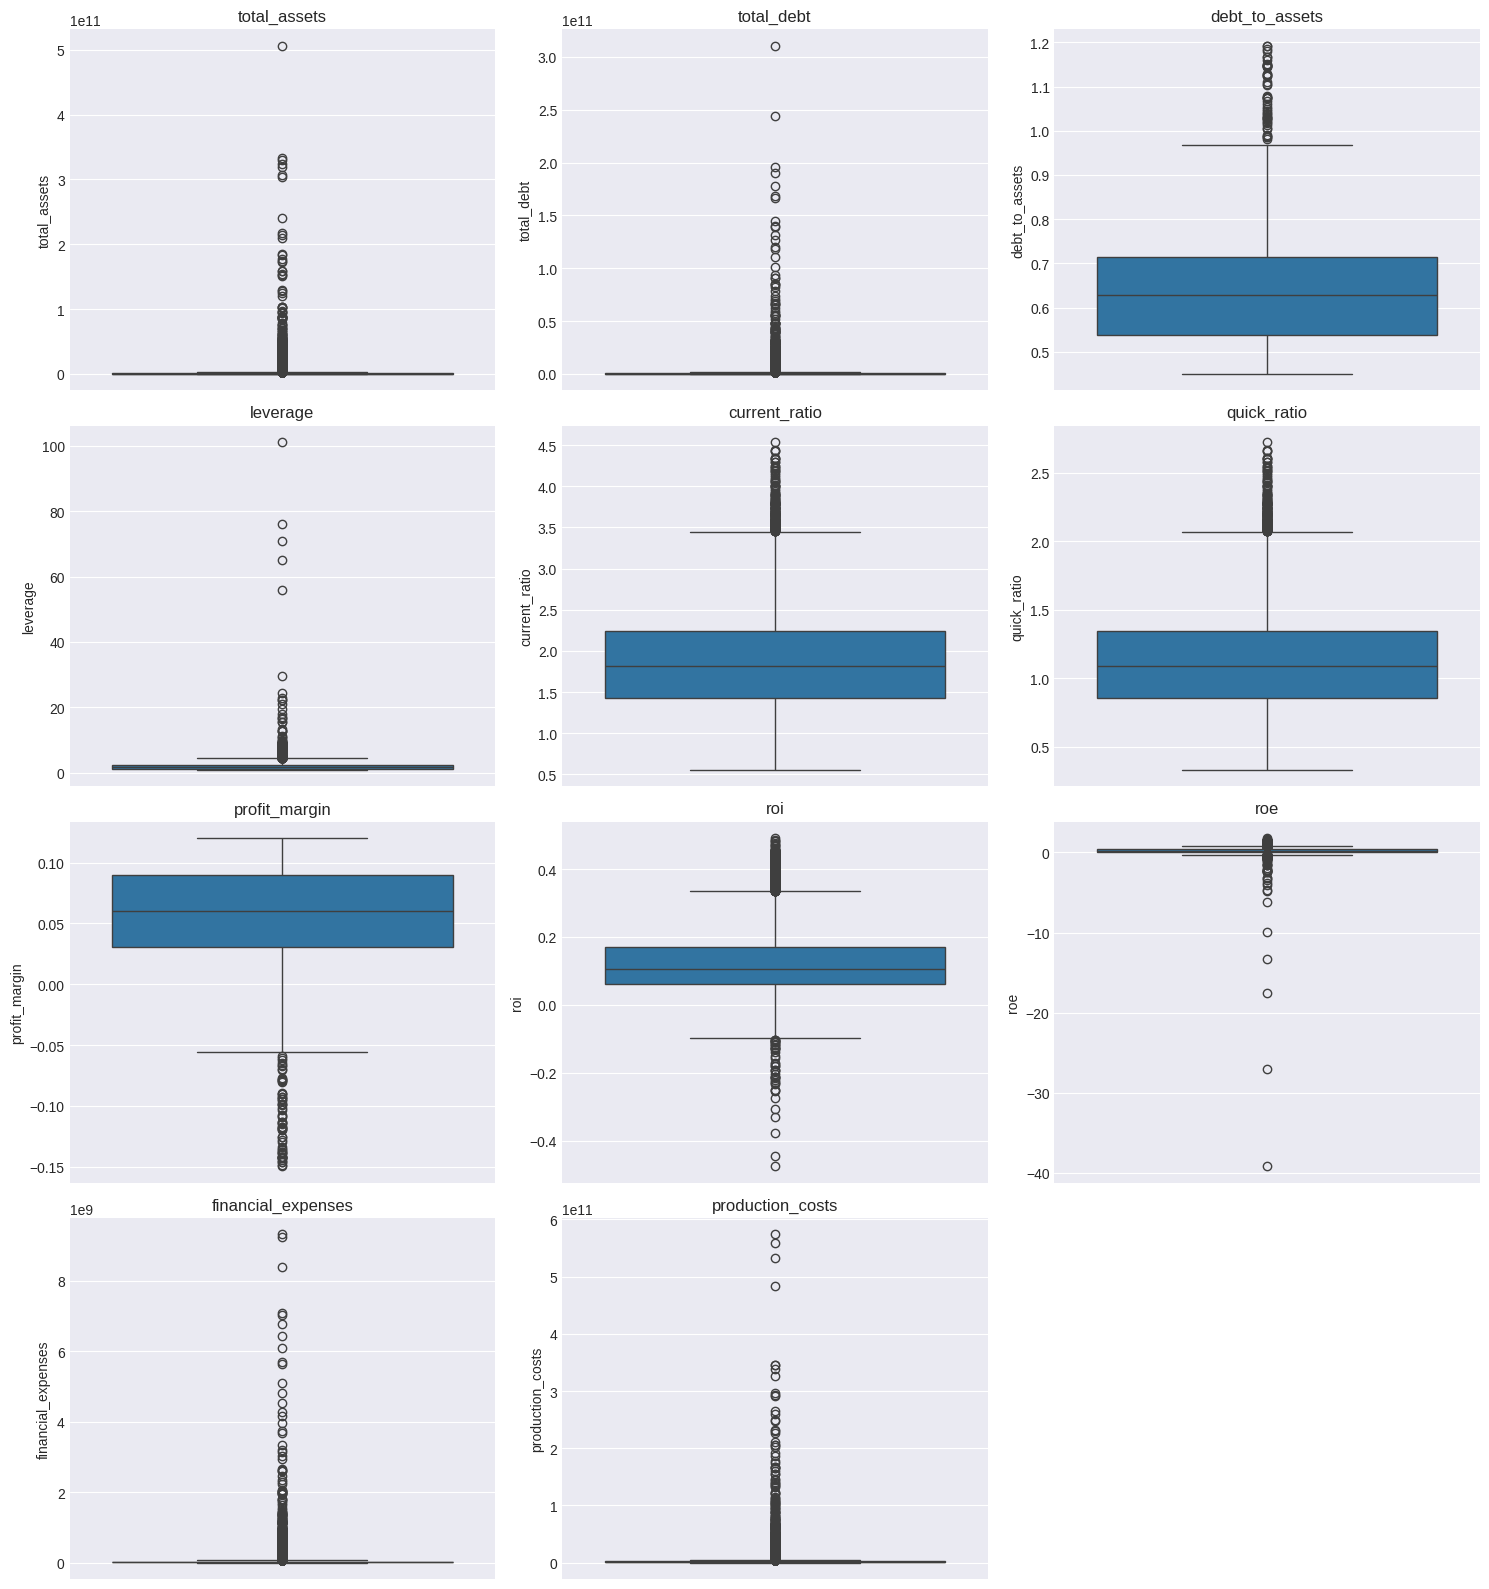


Re-plotting non-negative selected variables with log1p scale:


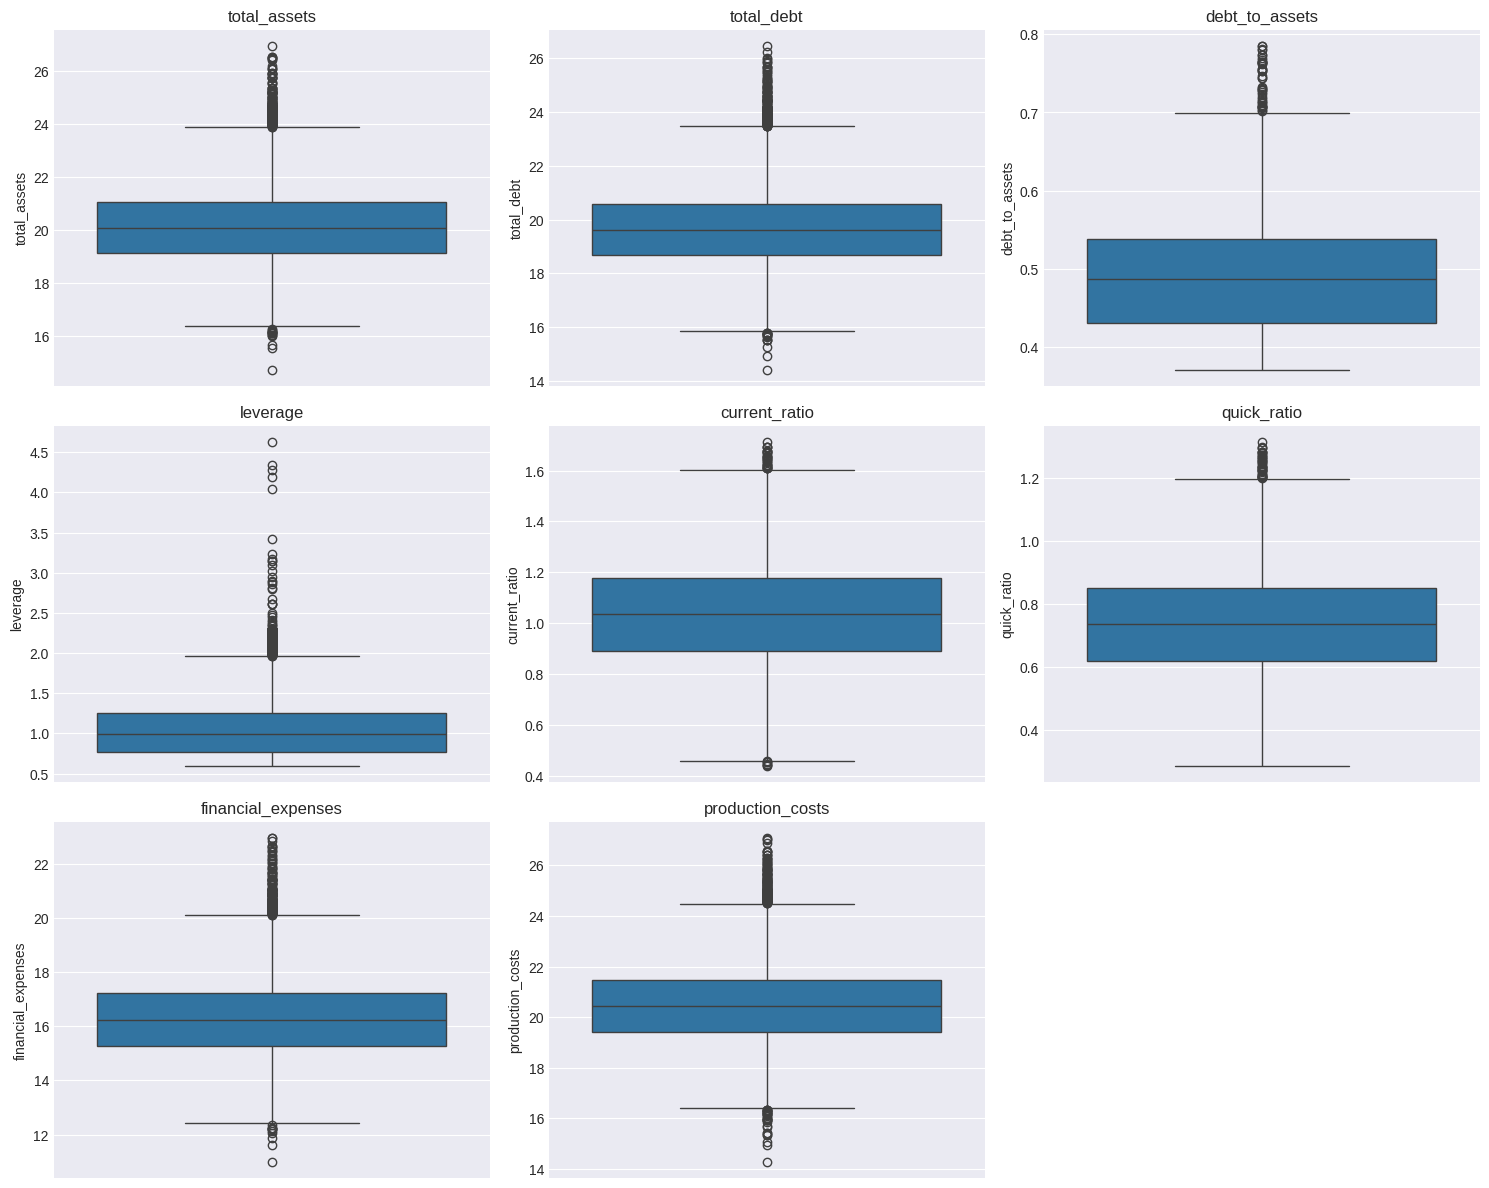

In [50]:
# Variables to show in the EDA (representative groups: size, debt, liquidity, profitability, costs)
eda_outlier_vars = [
    'total_assets',
    'total_debt',
    'debt_to_assets',
    'leverage',
    'current_ratio',
    'quick_ratio',
    'profit_margin',
    'roi',
    'roe',
    'financial_expenses',
    'production_costs'
]

# Safety: keep only variables that exist in the dataset
selected_vars = [c for c in eda_outlier_vars if c in train.columns]

print("Selected variables for boxplot inspection:")
print(selected_vars)

# Plot boxplots (single-variable distributions)
def boxplots_for_outliers(df, cols, n_cols=3, figsize_per_col=5, figsize_per_row=4):
    n = len(cols)
    n_rows = math.ceil(n / n_cols)
    plt.figure(figsize=(figsize_per_col * n_cols, figsize_per_row * n_rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.boxplot(y=df[col])
        plt.title(col)
        plt.xlabel("")

    plt.tight_layout()
    plt.show()

boxplots_for_outliers(train, selected_vars, n_cols=3)

# If some plots look "flat" because of extreme scale, re-plot on log scale
# NOTE: we only apply log1p to strictly non-negative variables; otherwise we skip.
nonneg_vars = [c for c in selected_vars if (train[c].min() >= 0)]
if len(nonneg_vars) > 0:
    train_log = train.copy()
    for c in nonneg_vars:
        train_log[c] = np.log1p(train_log[c])

    print("\nRe-plotting non-negative selected variables with log1p scale:")
    boxplots_for_outliers(train_log, nonneg_vars, n_cols=3)


**Why focus on a subset of variables**

The distribution diagnostics identified heavy tails across a large number of
magnitude variables. However, visual inspection focuses on a selected subset
based on two criteria:

- variables exhibiting the most extreme tail behaviour, indicating strong scale
  effects and potential **influence on model stability**;

- financially meaningful indicators directly linked to **bankruptcy risk**,
  including leverage, liquidity, and profitability ratios.

This selection balances **statistical relevance with economic interpretability**,
allowing inspection of the most informative variables while avoiding redundancy.

**Interpretation of the results**

The boxplots confirm that extreme values are an intrinsic characteristic of
firm-level financial data and reflect **structural economic differences rather
than measurement errors.**

- Size-related variables such as `total_assets` and `total_debt` display pronounced
  right tails, capturing the coexistence of **very large firms** alongside a
  majority of small and medium enterprises.

- Leverage indicators (`debt_to_assets`, `leverage`) exhibit extreme upper values
  that often correspond to situations of **negative or near-zero equity**,
  signalling genuine financial distress rather than anomalies.

- Liquidity ratios (`current_ratio`, `quick_ratio`) show relatively compact
  distributions, with occasional high outliers representing firms holding
  unusually large liquidity buffers.

- Profitability measures highlight financial fragility:
  - `profit_margin` presents a noticeable negative tail, indicating **loss-making firms;**
  - `roi` shows moderate dispersion with both positive and negative extremes;
  - `roe` exhibits extremely negative values, confirming how small equity bases
  can **amplify losses.**

- Cost variables (`financial_expenses`, `production_costs`) remain strongly
  right-skewed, reflecting firm size heterogeneity and differences in
  financing burden.

Overall, the selected variables confirm that extreme observations carry economic
meaning and are closely linked to financial distress dynamics. Rather than
removing these values, preprocessing will focus on **mitigating scale distortions**
while preserving the financial signals associated with bankruptcy risk.

## **9. Data Preprocessing**

To ensure a reliable and economically meaningful modelling pipeline, the preprocessing phase is divided into **two complementary parts**.

The **first part** focuses on preparing a **clean and consistent base dataset**. In this stage we handle **missing values** and apply **basic outlier control (winsorization)** using statistics computed **only on the development window (2018-2020)**. The **2021 validation year** is treated as future data: it receives those preprocessing rules, but it does not contribute to estimating them.

The resulting datasets represent clean **"pre-log / pre-feature-engineering" versions** of the data. They maintain the **original financial magnitudes** required for ratio construction and **time-based feature creation** in the next stage.

The **second part of preprocessing** is applied **after Feature Engineering**. Once the engineered features are created, we perform the model-oriented transformations required for machine learning, including **log transformations of selected magnitudes**, **categorical encoding fit only on 2018-2020**, and **feature scaling fit only on the development data**.

This separation ensures that:
- **feature engineering** is computed on **economically meaningful raw magnitudes**
- **all learned preprocessing rules** are estimated only on the **past development years**
- the entire pipeline remains **time-aware and free from avoidable leakage**

###**9.1 Handling missing values**

Before modelling, we ensure that the dataset is **complete and consistent**, since missing values can distort statistical patterns and degrade model performance.

Guided by the **Exploratory Data Analysis (EDA)**, we examine the extent and distribution of missingness and apply a **robust, train-driven imputation strategy** that preserves the economic meaning of the variables while preventing **data leakage**.

The preprocessing strategy follows three main principles:

- **Columns with excessive missing values** (e.g., above 40%) are identified using only the **2018-2020 development window** and then dropped consistently across development, validation, and test data.
- **Numeric variables** are imputed using the **median**, a robust statistic that limits the influence of extreme values.
- **Categorical variables** are imputed using the **mode** (most frequent value), ensuring consistency while preserving the most representative category.

Importantly, all imputation statistics are **computed only on 2018-2020** and then applied to:
- the development rows used for model fitting
- the **2021 validation year**
- and the **2022-2023 official test period**

This preserves a realistic forecasting scenario in which the future can receive the learned rules, but cannot help define them.

In [51]:

df_train_fit_processed = train_fit_raw.copy()
df_val_2021_processed = val_2021_raw.copy()
df_test_processed = test_raw.copy()

# Targets exist only in labelled train data
target_cols = ["revenue_change", "financial_health_class", "bankruptcy_next_year"]

# Handle missing values
# 1) Drop columns with too many missing values (estimated on 2018-2020 only)
display(missing_df_train)

missing_pct_train_fit = df_train_fit_processed.isnull().mean() * 100
high_missing_cols = missing_pct_train_fit[missing_pct_train_fit > 40].index.tolist()
print(f"Dropping columns with > 40% missing (estimated on 2018-2020 only): {high_missing_cols}")

for frame in (df_train_fit_processed, df_val_2021_processed, df_test_processed):
    frame.drop(columns=high_missing_cols, inplace=True, errors="ignore")

# 1.5) Add Missingness Indicators (BEFORE IMPUTATION)
# We add explicit boolean flags for variables where "missingness" might be an economic signal
# (e.g. negative equity causing null ratios, missing financial statements).
key_candidate_cols = ["roe", "leverage", "profit_margin", "roi", "current_ratio", "debt_to_assets"]
missingness_cols = []
for col in key_candidate_cols:
    if col in df_train_fit_processed.columns:
        flag_name = f"{col}_missing_flag"
        missingness_cols.append(flag_name)
        for frame in (df_train_fit_processed, df_val_2021_processed, df_test_processed):
            frame[flag_name] = frame[col].isnull().astype(int)

# 2) Imputation: numeric and categorical
numeric_train = df_train_fit_processed.select_dtypes(include=[np.number]).columns.tolist()
numeric_train = [c for c in numeric_train if c not in target_cols]
categorical_train = df_train_fit_processed.select_dtypes(exclude=[np.number]).columns.tolist()

# Keep only columns available in development, validation, and test
numeric_cols = [
    c for c in numeric_train
    if c in df_val_2021_processed.columns and c in df_test_processed.columns
]
categorical_cols = [
    c for c in categorical_train
    if c in df_val_2021_processed.columns and c in df_test_processed.columns
]

# Numeric imputation with median (computed on 2018-2020, applied to all)
medians = df_train_fit_processed[numeric_cols].median()
for frame in (df_train_fit_processed, df_val_2021_processed, df_test_processed):
    frame[numeric_cols] = frame[numeric_cols].fillna(medians)

# Categorical imputation with mode (computed on 2018-2020, applied to all)
for col in categorical_cols:
    mode_series = df_train_fit_processed[col].mode(dropna=True)
    if len(mode_series) > 0:
        mode_value = mode_series.iloc[0]
        for frame in (df_train_fit_processed, df_val_2021_processed, df_test_processed):
            frame[col] = frame[col].fillna(mode_value)

print("Missing values handled using 2018-2020 preprocessing statistics only.")
if missingness_cols:
    print(f"Added {len(missingness_cols)} missingness indicators: {missingness_cols}")

# Save clean pre-log datasets for development, validation, and test
df_train_fit_clean_prelog = df_train_fit_processed.copy()
df_val_2021_clean_prelog = df_val_2021_processed.copy()
df_test_clean_prelog = df_test_processed.copy()

# Rebuild the combined labelled train table for downstream FE steps
df_train_clean_prelog = (
    pd.concat([df_train_fit_clean_prelog, df_val_2021_clean_prelog], ignore_index=True)
    .sort_values(["company_id", "fiscal_year"])
    .reset_index(drop=True)
)

print("Saved leakage-safe clean pre-log datasets for development, validation, and test.")
print(f"Development rows: {df_train_fit_clean_prelog.shape[0]}")
print(f"Validation rows:  {df_val_2021_clean_prelog.shape[0]}")
print(f"Test rows:        {df_test_clean_prelog.shape[0]}")



,Missing Count,Missing %
revenue_change,2999,25.36
roe,45,0.38
leverage,45,0.38


Dropping columns with > 40% missing (estimated on 2018-2020 only): []
Missing values handled using 2018-2020 preprocessing statistics only.
Added 6 missingness indicators: ['roe_missing_flag', 'leverage_missing_flag', 'profit_margin_missing_flag', 'roi_missing_flag', 'current_ratio_missing_flag', 'debt_to_assets_missing_flag']
Saved leakage-safe clean pre-log datasets for development, validation, and test.
Development rows: 8896
Validation rows:  2932
Test rows:        5811



**Interpretation of the results**

The missing-value diagnostics indicate a **limited presence of incomplete observations** across the dataset.

- No variables exceed the **40% missing threshold**, therefore **no columns are removed**, preserving the full informational content of the dataset.
- Missing values are concentrated in a small subset of variables:
  - `revenue_change` shows a moderate proportion of missing observations, likely reflecting unavailable historical comparisons for some firms.
  - `roe`, and `leverage` display only **marginal missingness**.

Numeric variables are imputed using the **median**, which preserves the distributional structure while reducing sensitivity to extreme values.  
Categorical variables are imputed using the **mode**, ensuring consistency with the most common category observed in the training data.

Importantly, all imputation statistics are computed **only on the training set** and then applied to the test set, preventing **data leakage** and maintaining a realistic modelling framework.

Overall, the relatively low level of missingness confirms **good data quality**, and the chosen imputation strategy preserves statistical integrity while maintaining model robustness.





**Saving a Clean Pre-Transformation Dataset**

After handling missing values, we store a **clean copy of the dataset before any further transformations**.

This intermediate version preserves the **original scale of financial variables**, which is essential for **accounting-based feature engineering** performed in the next stage, such as:

- Altman-like **Z-score indicators**
- financial structure **ratios**
- balance-sheet relationship features.

These indicators are economically meaningful **only when computed on variables expressed in their original accounting scale**.  
Applying log transformations beforehand would distort these relationships.

Therefore, we save:

- **`df_train_clean_prelog`**
- **`df_test_clean_prelog`**

which represent the **clean but non-transformed datasets** used as the starting point for the subsequent **Feature Engineering** phase.


###**9.2 Winsorization and Outlier Handling**







After handling missing values, we address the presence of **extreme observations** in financial ratios.

Financial ratios may exhibit unusually large or small values due to accounting effects such as **very small denominators**, temporary shocks, or reporting inconsistencies. If left untreated, these extreme observations can distort statistical distributions and negatively affect downstream modelling steps.

To mitigate this issue, we apply **winsorization** to the main ratio variables. Specifically, values are **capped at the 0.5th and 99.5th percentiles**, limiting the influence of extreme tails while preserving the overall structure of the data.

To prevent **data leakage**, percentile thresholds are computed **only on the 2018-2020 development dataset** and then applied consistently to the **2021 validation year** and the **2022-2023 test dataset**.

Importantly, this transformation is applied to the clean pre-log accounting tables so that the original financial scale is preserved for the subsequent feature-engineering steps.

In [52]:
# A. Winsorization on ratios (0.5th-99.5th percentile)
ratio_cols = [
    "current_ratio",
    "quick_ratio",
    "leverage",
    "debt_to_assets",
    "profit_margin",
    "roi",
    "roe",
]

# Keep only ratio columns available in development, validation, and test
ratio_cols = [
    c for c in ratio_cols
    if c in df_train_fit_clean_prelog.columns
    and c in df_val_2021_clean_prelog.columns
    and c in df_test_clean_prelog.columns
]

if len(ratio_cols) > 0:
    # Estimate clipping bounds on 2018-2020 only
    lower_bounds = df_train_fit_clean_prelog[ratio_cols].quantile(0.005)
    upper_bounds = df_train_fit_clean_prelog[ratio_cols].quantile(0.995)

    print("Winsorizing ratios (0.5th-99.5th percentile, estimated on 2018-2020 only):")
    for col in ratio_cols:
        orig_min = df_train_fit_clean_prelog[col].min()
        orig_max = df_train_fit_clean_prelog[col].max()

        # Apply the same bounds to development, validation, and test
        for frame in (df_train_fit_clean_prelog, df_val_2021_clean_prelog, df_test_clean_prelog):
            frame[col] = frame[col].clip(lower_bounds[col], upper_bounds[col])

        new_min = df_train_fit_clean_prelog[col].min()
        new_max = df_train_fit_clean_prelog[col].max()
        print(f"  - {col:15}: [{orig_min:10.4f}, {orig_max:10.4f}] -> [{new_min:10.4f}, {new_max:10.4f}]")
else:
    print("No ratio columns found across development, validation, and test. Skipping winsorization step.")

# Rebuild the combined labelled train table after development-based winsorization
df_train_clean_prelog = (
    pd.concat([df_train_fit_clean_prelog, df_val_2021_clean_prelog], ignore_index=True)
    .sort_values(["company_id", "fiscal_year"])
    .reset_index(drop=True)
)

print("Pre-log winsorization completed with development-only bounds.")

Winsorizing ratios (0.5th-99.5th percentile, estimated on 2018-2020 only):
  - current_ratio  : [    0.5510,     4.4318] -> [    0.6883,     3.7712]
  - quick_ratio    : [    0.3306,     2.6591] -> [    0.4130,     2.2627]
  - leverage       : [    0.8182,   101.1538] -> [    0.8232,     8.7316]
  - debt_to_assets : [    0.4500,     1.1923] -> [    0.4515,     0.9472]
  - profit_margin  : [   -0.1485,     0.1200] -> [   -0.0627,     0.1194]
  - roi            : [   -0.4753,     0.4831] -> [   -0.0775,     0.4257]
  - roe            : [  -39.1771,     1.6144] -> [   -0.4986,     1.2345]
Pre-log winsorization completed with development-only bounds.


**Interpretation of the results**

The output confirms that several financial ratios contain **extreme values** that can significantly distort the distribution of the data.

Winsorization works by **capping extreme observations** rather than removing them entirely. Values below the **0.5th percentile** are replaced by the 0.5th percentile value, and values above the **99.5th percentile** are replaced by the 99.5th percentile value.

This approach reduces the influence of rare extreme observations while preserving the **overall distribution and economic meaning** of the ratios.

The transformation is particularly relevant for variables such as:

- **leverage**, where extreme values can arise when equity becomes very small;
- **roe**, which may produce very large negative values during periods of financial distress.

By limiting extreme tails, winsorization improves the **statistical robustness** of the dataset while maintaining the interpretability of the underlying financial indicators.

The cleaned datasets (`df_train_clean_prelog` and `df_test_clean_prelog`) will now be used as the **base input for the Feature Engineering phase**, where additional accounting-based and temporal features will be constructed.


## **10. Feature Engineering**

In this section we enrich the cleaned base dataset with additional variables that extract economically meaningful signals from the available financial information.

The preprocessing phase produced clean, consistent datasets at their original accounting scale. Feature engineering has a different objective: to transform raw financial statements into indicators that are **more directly informative** about a firm's financial condition, trajectory, and relative standing within its sector.

The pipeline follows a structured sequence of four complementary stages:

1. **Accounting-based indicators** — we construct an Altman-like synthetic distress score that combines multiple balance-sheet and performance ratios into a single composite measure of financial stability.
2. **Temporal dynamics** — we extract year-over-year growth rates, directional trend indicators, and volatility measures that capture how a firm's financial position evolves over time.
3. **Distress trajectory features** — we build indicators designed to detect the gradual patterns of financial deterioration that typically precede bankruptcy, including multi-year slopes, consecutive distress streaks, and acceleration measures.
4. **Sector-relative features** — we benchmark each firm's key ratios against the typical values observed in its ATECO industry, so the model can detect firms that are unusually weak relative to their peers rather than only in absolute terms.

Following these construction steps, we examine the **correlation structure** of the enriched feature space to identify redundant variables, and apply a **manual pruning step** to remove features that carry duplicated information.

Finally, we complement the engineered features with an **unsupervised clustering step** that assigns each firm to a financial profile group, providing the model with a compact representation of a firm's overall positioning in the feature space.

All transformations that depend on training statistics are estimated **only on the 2018-2020 development window** and then applied to the 2021 validation year and the 2022-2023 test period, preserving the temporal integrity of the entire pipeline.

### **10.1 Data Preparation for FE**

**Data Preparation for Feature Engineering**

Before constructing new features, we initialize the three working datasets from the clean pre-log tables produced during preprocessing.

The starting point for feature engineering is the **clean, unscaled version** of the data, which preserves the original accounting magnitudes needed for ratio-based and time-series calculations. Applying log transformations or standardization at this stage would distort the economic meaning of the indicators we are about to construct.

We maintain three separate datasets throughout the feature engineering phase:

- **development data (2018-2020)**, which drives all train-dependent computations
- **validation data (2021)**, which receives derived features without contributing to their estimation
- **test data (2022-2023)**, which is aligned with the same structure for final prediction

We also identify the **common set of columns** available across all three datasets to ensure that every feature we construct can be applied consistently during both model training and inference.

In [53]:
def combine_train_periods(train_fit_df: pd.DataFrame, val_df: pd.DataFrame) -> pd.DataFrame:
    # Rebuild the full labelled train table after leakage-safe preprocessing / FE steps
    combined = pd.concat([train_fit_df, val_df], ignore_index=True)
    sort_cols = [c for c in ["company_id", "fiscal_year"] if c in combined.columns]
    if len(sort_cols) > 0:
        combined = combined.sort_values(sort_cols)
    return combined.reset_index(drop=True)


# Start FE from the clean pre-log tables
df_train_fit_fe = df_train_fit_clean_prelog.copy()
df_val_2021_fe = df_val_2021_clean_prelog.copy()
df_test_fe = df_test_clean_prelog.copy()

# Remove presentation-only label columns if still present
for frame in (df_train_fit_fe, df_val_2021_fe, df_test_fe):
    frame.drop(columns=["ateco_sector_label"], errors="ignore", inplace=True)

# Targets exist only in labelled train data
target_cols = [
    c for c in ["revenue_change", "financial_health_class", "bankruptcy_next_year"]
    if c in df_train_fit_fe.columns
]

# Standardize categorical columns before FE creation
for col in ["ateco_sector", "region", "legal_form"]:
    for frame in (df_train_fit_fe, df_val_2021_fe, df_test_fe):
        if col in frame.columns:
            frame[col] = frame[col].astype(str)

# Sort each table chronologically for time-based feature construction
for frame in (df_train_fit_fe, df_val_2021_fe, df_test_fe):
    sort_cols = [c for c in ["company_id", "fiscal_year"] if c in frame.columns]
    if len(sort_cols) > 0:
        frame.sort_values(sort_cols, inplace=True)
        frame.reset_index(drop=True, inplace=True)

# Rebuild the combined labelled train table for downstream FE steps
df_train_fe = combine_train_periods(df_train_fit_fe, df_val_2021_fe)

# Keep track of columns shared by development, validation, and test
common_feature_cols = [
    c for c in df_train_fit_fe.columns
    if c in df_val_2021_fe.columns and c in df_test_fe.columns
]

print(f"Development FE shape: {df_train_fit_fe.shape}")
print(f"Validation FE shape:  {df_val_2021_fe.shape}")
print(f"Combined train FE:    {df_train_fe.shape}")
print(f"Test FE shape:        {df_test_fe.shape}")
print(f"Train-only target columns: {target_cols}")
print(f"Common columns available for FE: {len(common_feature_cols)}")
print("Feature Engineering base datasets prepared with an explicit temporal split.")

Development FE shape: (8896, 36)
Validation FE shape:  (2932, 36)
Combined train FE:    (11828, 36)
Test FE shape:        (5811, 33)
Train-only target columns: ['revenue_change', 'financial_health_class', 'bankruptcy_next_year']
Common columns available for FE: 33
Feature Engineering base datasets prepared with an explicit temporal split.


**Interpretation of the results**

The preparation step confirms that the feature engineering datasets are correctly initialized from the clean preprocessing outputs.

The three working datasets are aligned on **33 common columns** — the full set of variables available in all three periods after removing the train-only target columns. The target variables — `bankruptcy_next_year`, `financial_health_class`, and `revenue_change` — remain present in the development and validation datasets but are absent from the test set, as expected.

The row counts confirm the temporal structure of the split:

- **8,896 rows** in the development period (2018-2020)
- **2,932 rows** in the validation year (2021)
- **11,828 rows** in the combined labelled training set
- **5,811 rows** in the test period (2022-2023)

These datasets form the starting base on which all subsequent feature engineering steps will be applied.

### **10.2 Advanced Financial Ratios**

**Altman-like Z-Score (Financial Distress Indicator)**

One of the most established indicators of corporate financial distress in the literature is the **Altman Z-score**, which summarizes a firm's financial health using a linear combination of accounting-based ratios.

We construct an adapted version of this indicator using the variables available in our dataset. The original formulation requires retained earnings and market-value equity, which are not available here. Our adaptation uses five components derived from available accounting variables:

- **working capital-to-assets** (liquidity proxy)
- **equity-to-assets** (balance-sheet solvency)
- **operating income-to-assets** (profitability)
- **equity-to-liabilities** (leverage)
- **revenue-to-assets** (asset productivity)

combined with the standard Z''-Score coefficients (0.717, 0.847, 3.107, 0.420, 0.998) applicable to private companies.

The resulting composite measure is calculated consistently for all three datasets — development, validation, and test — and added as a new feature `altman_z_like_score`. It will be used both as a direct model input and as a core variable in the subsequent clustering stage.

In [54]:
def calculate_altman_like_score(df):
    # Compute an Altman-like distress indicator from accounting-based ratios
    df = df.copy()

    total_assets = df["total_assets"].replace(0, np.nan)
    total_liabilities = df["total_debt"].replace(0, np.nan)

    # Approximate working capital using current assets and short-term debt when available
    if "short_term_debt" in df.columns:
        working_capital = df["current_assets"] - df["short_term_debt"]
    else:
        working_capital = df["current_assets"]

    x1 = working_capital / total_assets
    x2 = df["shareholders_equity"] / total_assets
    x3 = df["operating_income"] / total_assets
    x4 = df["shareholders_equity"] / total_liabilities
    x5 = df["production_value"] / total_assets

    z = 0.717 * x1 + 0.847 * x2 + 3.107 * x3 + 0.420 * x4 + 0.998 * x5
    return z.replace([np.inf, -np.inf], np.nan)


# Compute the Altman-like score separately for development, validation, and test
z_train_fit = calculate_altman_like_score(df_train_fit_clean_prelog)
z_val_2021 = calculate_altman_like_score(df_val_2021_clean_prelog)
z_test = calculate_altman_like_score(df_test_clean_prelog)

# Fill missing score values using the DEVELOPMENT median only
z_median = z_train_fit.median()
z_train_fit = z_train_fit.fillna(z_median)
z_val_2021 = z_val_2021.fillna(z_median)
z_test = z_test.fillna(z_median)

# Add the engineered score to the FE tables
df_train_fit_fe["altman_z_like_score"] = z_train_fit.values
df_val_2021_fe["altman_z_like_score"] = z_val_2021.values
df_test_fe["altman_z_like_score"] = z_test.values
df_train_fe = combine_train_periods(df_train_fit_fe, df_val_2021_fe)

# Report the score distribution on the development window
z_mean = z_train_fit.mean()
z_med = z_train_fit.median()

print("Altman-like Z-score calculated.")
print(f"Development mean score:   {z_mean:.2f}")
print(f"Development median score: {z_med:.2f}")
print(f"Development Safe Zone (>2.9): {(z_train_fit > 2.9).mean():.2%}")
print(f"Development Distress Zone (<1.23): {(z_train_fit < 1.23).mean():.2%}")

Altman-like Z-score calculated.
Development mean score:   2.89
Development median score: 2.69
Development Safe Zone (>2.9): 42.09%
Development Distress Zone (<1.23): 4.35%


**Interpretation of the results**

The Altman-like Z-score provides a **synthetic measure of firm financial stability** by combining multiple accounting-based ratios into a single composite indicator.

The summary statistics from the development dataset show:

- **Mean score: 2.89**
- **Median score: 2.69**

These values suggest that the typical firm in the dataset falls near the boundary between the distress zone and the safe zone under the standard Altman thresholds.

Applying the conventional cut-off values:

- **42.1% of firms** fall in the **safe zone** (Z > 2.9), indicating relatively healthy financial conditions.
- **4.4% of firms** fall in the **distress zone** (Z < 1.23), indicating elevated risk.

The proportion of firms in the distress zone is broadly consistent with the observed bankruptcy prevalence in the training data, which provides early evidence that the score is capturing a meaningful dimension of financial fragility. The `altman_z_like_score` feature will complement the individual ratio variables in the model and serve as one of the core variables for the clustering stage that follows.

### **10.3 Temporal Financial Features (Growth, Trends, and Volatility)**



Corporate financial distress rarely appears suddenly. In most cases, it emerges through **progressive changes in a firm's financial dynamics** — declining revenues, deteriorating profitability, increasing leverage, or unstable operating performance accumulated over multiple years.

To capture these patterns, we construct a set of **temporal financial features** that describe how key financial quantities evolve within each firm over time.

Using the company identifier (`company_id`) together with the chronological ordering provided by `fiscal_year`, we extract three types of time-series indicators:

- **Year-over-year growth indicators**, measuring how core financial variables change relative to the previous year. These capture accelerating or decelerating dynamics in revenue, assets, debt, and operating income.
- **Directional trend variables**, identifying whether a firm's financial performance is improving or deteriorating relative to the prior year, expressed as binary indicators.
- **Volatility measures**, representing the historical variability of important financial variables, computed as the expanding standard deviation within each firm.

All temporal computations are performed on the combined time series across development, validation, and test in a strictly **backward-looking manner**: each firm-year observation uses only information from prior years, ensuring there is no leakage of future data into the computed features.

In [55]:
def calculate_temporal_features(dataset_map: dict[str, pd.DataFrame]) -> dict[str, pd.DataFrame]:
    # Build temporal features jointly, but keep development, validation, and test separable
    prepared_frames = []
    common_cols = sorted(set.intersection(*(set(df.columns) for df in dataset_map.values())))

    for dataset_name, df in dataset_map.items():
        frame = df.copy()
        frame["_dataset"] = dataset_name
        frame["_orig_idx"] = np.arange(len(frame))
        prepared_frames.append(frame[common_cols + ["_dataset", "_orig_idx"]])

    # Sort chronologically within each company so features remain backward-looking
    combined = pd.concat(prepared_frames, axis=0, ignore_index=True)
    combined = combined.sort_values(["company_id", "fiscal_year"]).reset_index(drop=True)

    # Create growth and trend signals for key financial quantities
    growth_cols = ["production_value", "total_assets", "total_debt", "operating_income"]
    growth_cols = [c for c in growth_cols if c in combined.columns]

    for col in growth_cols:
        combined[f"{col}_growth"] = combined.groupby("company_id")[col].pct_change()
        combined[f"{col}_growth"] = (
            combined[f"{col}_growth"]
            .replace([np.inf, -np.inf], np.nan)
            .clip(-1, 5)
            .fillna(0)
        )
        combined[f"{col}_trend_up"] = (combined[f"{col}_growth"] > 0).astype(int)

    # Create expanding volatility measures for selected operating quantities
    vol_cols = ["production_value", "operating_income"]
    vol_cols = [c for c in vol_cols if c in combined.columns]

    for col in vol_cols:
        combined[f"{col}_volatility"] = (
            combined.groupby("company_id")[col]
            .expanding()
            .std()
            .reset_index(level=0, drop=True)
            .fillna(0)
        )

    # Split the combined table back into the original datasets
    outputs = {}
    for dataset_name in dataset_map:
        outputs[dataset_name] = (
            combined[combined["_dataset"] == dataset_name]
            .sort_values("_orig_idx")
            .drop(columns=["_dataset", "_orig_idx"])
            .reset_index(drop=True)
        )

    return outputs


# Compute temporal features for development, validation, and test
temporal_sets = calculate_temporal_features(
    {
        "train_fit": df_train_fit_clean_prelog,
        "val_2021": df_val_2021_clean_prelog,
        "test": df_test_clean_prelog,
    }
)

# Keep only the newly created temporal feature columns
temporal_feature_cols = [
    c for c in temporal_sets["train_fit"].columns
    if c.endswith("_growth") or c.endswith("_trend_up") or c.endswith("_volatility")
]

# Add the temporal features to the FE tables
for col in temporal_feature_cols:
    df_train_fit_fe[col] = temporal_sets["train_fit"][col].values
    df_val_2021_fe[col] = temporal_sets["val_2021"][col].values
    df_test_fe[col] = temporal_sets["test"][col].values

df_train_fe = combine_train_periods(df_train_fit_fe, df_val_2021_fe)

print("Temporal features extended with growth, volatility, and trend signals.")
print(f"Temporal features created: {len(temporal_feature_cols)}")

Temporal features extended with growth, volatility, and trend signals.
Temporal features created: 10


**Interpretation of the results**

The temporal feature construction successfully extends the dataset with **10 new indicators** capturing the dynamic evolution of firms' financial performance.

For each firm, the following signals are now available:

- **Growth rates** measuring year-over-year percentage changes in production value, total assets, total debt, and operating income.
- **Trend indicators** identifying whether each of these quantities increased or decreased relative to the prior year, expressed as binary variables.
- **Volatility measures** representing the expanding historical standard deviation of production value and operating income at the firm level.

These variables complement the static ratios already available by introducing a **time dimension** into the feature set. A firm whose revenue is declining rapidly carries very different bankruptcy risk than one with the same current revenue level but stable or growing dynamics. The temporal features are designed to expose precisely this type of information to the model.

### **10.4 Distress Trajectory Features**


Corporate bankruptcy rarely emerges from a single bad year. In most cases, it is the result of a **progressive deterioration** in a firm's financial condition over multiple periods — a trajectory that can often be traced back several years before the formal distress event.

To capture these dynamics, we construct a set of **distress trajectory features** that go beyond simple year-over-year changes and describe the **shape and persistence of financial decline**.

Five categories of trajectory indicators are constructed:

- **Multi-year deterioration slopes**: the expanding linear trend of key financial ratios (ROI, current ratio, debt-to-assets, profit margin) across the available company history. A persistently declining trend is more informative than a single bad observation.
- **Consecutive distress indicators**: how many consecutive years a firm has operated with negative margins (`neg_margin_streak`), negative operating income (`neg_oi_streak`), or insufficient liquidity (`low_liquidity_streak`, current ratio below 1).
- **Acceleration measures**: whether the rate of change in total debt or production value is itself increasing or decreasing, capturing second-order financial dynamics.
- **Binary distance metrics**: whether a firm's current ratio or debt-to-assets falls within commonly cited danger zones, and whether the firm sits below the Altman distress threshold.
- **Multi-year deterioration flags**: whether a key ratio has declined for two or more consecutive years.

All temporal computations use only past observations within each firm's history, ensuring a strictly backward-looking construction.

In [56]:
def calculate_distress_trajectory_features(dataset_map):
    """
    Build distress-trajectory features that capture the patterns of gradual
    financial deterioration that typically precede bankruptcy events.
    """
    prepared_frames = []
    common_cols = sorted(set.intersection(*(set(df.columns) for df in dataset_map.values())))

    for dataset_name, df in dataset_map.items():
        frame = df.copy()
        frame["_dataset"] = dataset_name
        frame["_orig_idx"] = np.arange(len(frame))
        prepared_frames.append(frame[common_cols + ["_dataset", "_orig_idx"]])

    combined = pd.concat(prepared_frames, axis=0, ignore_index=True)
    combined = combined.sort_values(["company_id", "fiscal_year"]).reset_index(drop=True)

    new_feature_names = []

    # -- A. Multi-year deterioration slopes --
    slope_cols = [c for c in ["roi", "current_ratio", "debt_to_assets", "profit_margin"]
                  if c in combined.columns]

    for col in slope_cols:
        def _expanding_slope(s):
            out = np.full(len(s), np.nan)
            vals = s.values.astype(float)
            for i in range(1, len(vals)):
                window = vals[:i + 1]
                valid = ~np.isnan(window)
                if valid.sum() >= 2:
                    x = np.arange(len(window))[valid].astype(float)
                    y = window[valid]
                    out[i] = np.polyfit(x, y, 1)[0]
            return pd.Series(out, index=s.index)

        feat_name = f"{col}_slope"
        combined[feat_name] = (
            combined.groupby("company_id")[col]
            .transform(_expanding_slope)
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )
        new_feature_names.append(feat_name)

    # -- B. Consecutive distress indicators --
    distress_specs = []
    if "profit_margin" in combined.columns:
        distress_specs.append(("profit_margin", "neg_margin_streak", lambda x: x < 0))
    if "operating_income" in combined.columns:
        distress_specs.append(("operating_income", "neg_oi_streak", lambda x: x < 0))
    if "current_ratio" in combined.columns:
        distress_specs.append(("current_ratio", "low_liquidity_streak", lambda x: x < 1))

    for col, feat_name, cond_fn in distress_specs:
        def _streak(series, fn=cond_fn):
            flags = fn(series)
            streak = 0
            out = []
            for f in flags:
                streak = streak + 1 if f else 0
                out.append(streak)
            return pd.Series(out, index=series.index)

        combined[feat_name] = combined.groupby("company_id")[col].transform(_streak)
        new_feature_names.append(feat_name)

    # -- C. Acceleration features --
    accel_base_cols = [c for c in ["total_debt", "production_value"] if c in combined.columns]
    for col in accel_base_cols:
        temp_growth = combined.groupby("company_id")[col].pct_change()
        temp_growth = temp_growth.replace([np.inf, -np.inf], np.nan).clip(-1, 5).fillna(0)
        combined["_tmp_growth"] = temp_growth
        feat_name = f"{col}_acceleration"
        combined[feat_name] = (
            combined.groupby("company_id")["_tmp_growth"].diff().fillna(0)
        )
        new_feature_names.append(feat_name)
    combined.drop(columns=["_tmp_growth"], errors="ignore", inplace=True)

    # -- D. Distance from danger thresholds --
    if "current_ratio" in combined.columns:
        combined["dist_current_ratio_1"] = combined["current_ratio"] - 1.0
        new_feature_names.append("dist_current_ratio_1")
    if "debt_to_assets" in combined.columns:
        combined["dist_debt_to_assets_08"] = 0.8 - combined["debt_to_assets"]
        new_feature_names.append("dist_debt_to_assets_08")

    # -- E. Recent worsening flags --
    worsening_specs = []
    if "profit_margin" in combined.columns:
        worsening_specs.append(("profit_margin", "margin_declining_2y", "declining"))
    if "roi" in combined.columns:
        worsening_specs.append(("roi", "roi_declining_2y", "declining"))
    if "debt_to_assets" in combined.columns:
        worsening_specs.append(("debt_to_assets", "leverage_rising_2y", "rising"))

    for col, feat_name, direction in worsening_specs:
        diff = combined.groupby("company_id")[col].diff()
        is_worsening = (diff > 0) if direction == "rising" else (diff < 0)
        prev_worsening = is_worsening.groupby(combined["company_id"]).shift(1).fillna(False)
        combined[feat_name] = (is_worsening & prev_worsening).astype(int)
        new_feature_names.append(feat_name)

    # Split back into original datasets
    outputs = {}
    for dataset_name in dataset_map:
        outputs[dataset_name] = (
            combined[combined["_dataset"] == dataset_name]
            .sort_values("_orig_idx")
            .drop(columns=["_dataset", "_orig_idx"])
            .reset_index(drop=True)
        )

    return outputs, new_feature_names


# Compute distress trajectory features
distress_sets, distress_feature_names = calculate_distress_trajectory_features(
    {
        "train_fit": df_train_fit_clean_prelog,
        "val_2021": df_val_2021_clean_prelog,
        "test": df_test_clean_prelog,
    }
)

# Add the new features to the FE tables
for col in distress_feature_names:
    df_train_fit_fe[col] = distress_sets["train_fit"][col].values
    df_val_2021_fe[col] = distress_sets["val_2021"][col].values
    df_test_fe[col] = distress_sets["test"][col].values

# Add distance from Altman distress threshold (already available in FE tables)
if "altman_z_like_score" in df_train_fit_fe.columns:
    for frame in (df_train_fit_fe, df_val_2021_fe, df_test_fe):
        frame["dist_altman_distress"] = frame["altman_z_like_score"] - 1.23
    distress_feature_names.append("dist_altman_distress")

df_train_fe = combine_train_periods(df_train_fit_fe, df_val_2021_fe)

print("Distress trajectory features calculated.")
print(f"New features created ({len(distress_feature_names)}):")
for feat in distress_feature_names:
    print(f"  - {feat}")

# Show separation between bankrupt and healthy firms
if "bankruptcy_next_year" in df_train_fit_fe.columns:
    bankrupt = df_train_fit_fe["bankruptcy_next_year"] == 1
    healthy = df_train_fit_fe["bankruptcy_next_year"] == 0
    summary_rows = []
    for feat in distress_feature_names:
        summary_rows.append({
            "feature": feat,
            "healthy_median": df_train_fit_fe.loc[healthy, feat].median(),
            "bankrupt_median": df_train_fit_fe.loc[bankrupt, feat].median(),
            "separation": abs(
                df_train_fit_fe.loc[bankrupt, feat].median()
                - df_train_fit_fe.loc[healthy, feat].median()
            ),
        })
    summary_df = pd.DataFrame(summary_rows).sort_values("separation", ascending=False)
    print("\nFeature separation between bankrupt and healthy firms (development data):")
    display(summary_df.round(4))


Distress trajectory features calculated.
New features created (15):
  - roi_slope
  - current_ratio_slope
  - debt_to_assets_slope
  - profit_margin_slope
  - neg_margin_streak
  - neg_oi_streak
  - low_liquidity_streak
  - total_debt_acceleration
  - production_value_acceleration
  - dist_current_ratio_1
  - dist_debt_to_assets_08
  - margin_declining_2y
  - roi_declining_2y
  - leverage_rising_2y
  - dist_altman_distress

Feature separation between bankrupt and healthy firms (development data):


,feature,healthy_median,bankrupt_median,separation
4,neg_margin_streak,0.0000,1.0000,1.0000
14,dist_altman_distress,1.4636,0.8037,0.6600
9,dist_current_ratio_1,0.8228,0.4379,0.3849
10,dist_debt_to_assets_08,0.1745,-0.0072,0.1817
1,current_ratio_slope,0.0000,-0.1628,0.1628
2,debt_to_assets_slope,0.0000,0.0872,0.0872
3,profit_margin_slope,0.0000,-0.0338,0.0338
0,roi_slope,0.0000,-0.0300,0.0300
5,neg_oi_streak,0.0000,0.0000,0.0000
6,low_liquidity_streak,0.0000,0.0000,0.0000


**Interpretation of the results**

The distress trajectory features add **15 new variables** to the dataset, each capturing a different dimension of financial deterioration over time.

The feature separation table measures how **median values differ between bankrupt and healthy firms** in the development data. The most informative features show the largest absolute separation:

- **`neg_margin_streak`** shows the largest separation (1.00), indicating that bankrupt firms tend to have experienced extended periods of negative profit margins, while healthy firms have not.
- **`dist_altman_distress`** shows the second largest separation (0.66), confirming that firms falling below the Altman distress threshold in their recent history are significantly more likely to fail.
- **`dist_current_ratio_1`** (separation 0.38) and **`current_ratio_slope`** (separation 0.16) highlight that deteriorating liquidity is a meaningful early-warning signal.

Features such as `neg_oi_streak`, `low_liquidity_streak`, `total_debt_acceleration`, and `production_value_acceleration` show limited separation on median values but may still contribute to the model by capturing tail-risk patterns that are not visible through medians alone.

###**10.5 Sector-Relative Financial Features**

Financial indicators often depend strongly on the **industry in which a firm operates**. Leverage levels, profitability margins, and asset utilization vary substantially across sectors due to differences in capital intensity, business models, and competitive dynamics.

As a result, evaluating a firm's financial ratios in **absolute terms alone can be misleading**. A leverage ratio that appears high in one sector may be entirely normal in another, and a firm with below-average profitability within a high-margin sector may be under considerably more stress than its standalone ratios suggest.

To address this, we construct **sector-relative financial indicators** that compare each firm's key ratios to the typical values observed in its ATECO industry.

For each of the four selected ratios — **ROE, ROI, leverage, and profit margin** — we compute the **median value within the same ATECO sector and fiscal year**, using all available observations. Each firm's deviation from its sector-year benchmark is added as a new feature.

This approach allows the model to detect firms that are **unusually weak relative to their sector peers**, which may be a more reliable signal of distress than absolute ratio levels alone.

In [57]:
# Build sector-year relative versions of key financial ratios
ratios = ["roe", "roi", "leverage", "profit_margin"]
existing_ratios = [c for c in ratios if c in df_train_fit_fe.columns]

def add_sector_year_relatives(df, ratio_cols):
    # Compare each firm's ratio with the median level of its sector IN THAT SAME YEAR
    df = df.copy()
    sector_year_medians = df.groupby(["ateco_sector", "fiscal_year"])[ratio_cols].transform("median")
    global_year_medians = df.groupby("fiscal_year")[ratio_cols].transform("median")

    for col in ratio_cols:
        sector_val = sector_year_medians[col].fillna(global_year_medians[col]).fillna(df[col].median())
        df[f"{col}_vs_sector"] = df[col] - sector_val
    return df

# Apply the sector-year benchmarks dynamically to development, validation, and test
df_train_fit_fe = add_sector_year_relatives(df_train_fit_fe, existing_ratios)
df_val_2021_fe = add_sector_year_relatives(df_val_2021_fe, existing_ratios)
df_test_fe = add_sector_year_relatives(df_test_fe, existing_ratios)
df_train_fe = combine_train_periods(df_train_fit_fe, df_val_2021_fe)

print(f"Sector-year relative features calculated for: {existing_ratios}")
display(
    df_train_fit_fe[
        ["company_id", "fiscal_year", "ateco_sector"]
        + [c for c in df_train_fit_fe.columns if "_vs_sector" in c]
    ].head()
)

Sector-year relative features calculated for: ['roe', 'roi', 'leverage', 'profit_margin']


,company_id,fiscal_year,ateco_sector,roe_vs_sector,roi_vs_sector,leverage_vs_sector,profit_margin_vs_sector
0,COMP_00000,2018,47,0.18405,0.02295,0.5517,0.05815
1,COMP_00000,2019,47,0.23330,0.03400,0.5010,0.02305
2,COMP_00000,2020,47,-0.69980,-0.19710,3.9731,-0.07720
3,COMP_00001,2018,62,0.01955,0.00285,0.6416,-0.03010
4,COMP_00001,2019,62,0.04955,-0.02160,2.0300,-0.03155


**Interpretation of the results**

The sector-relative feature construction adds **four new variables** to the dataset, one for each selected financial ratio:

- `roe_vs_sector`: deviation of a firm's ROE from its sector-year median
- `roi_vs_sector`: deviation from the sector-year median ROI
- `leverage_vs_sector`: deviation from the sector-year median leverage
- `profit_margin_vs_sector`: deviation from the sector-year median profit margin

The output shows the first observations for selected companies, confirming that both positive and negative deviations are present across the dataset. A firm with a strongly negative `profit_margin_vs_sector`, for example, is underperforming its sector peers by a significant margin — which may reflect structural weakness rather than a temporary industry-wide shock.

Benchmarking financial ratios against sector medians provides the model with **relative context** that is not available from the raw ratios alone. This is particularly valuable for a dataset spanning multiple ATECO sectors with very different structural financial characteristics.

###**10.6 Correlation-Based Feature Diagnostics**

Before performing feature selection, we examine the **correlation structure** among numerical variables to identify cases of **multicollinearity** in the enriched feature space.

After the construction steps above, the dataset contains a mix of original financial variables, engineered ratios, temporal features, distress trajectory indicators, and sector-relative benchmarks. Many of these variables are likely to share substantial information with one another, because they are derived from the same underlying accounting quantities.

Retaining highly correlated variables increases the **dimensionality** of the feature space without adding proportional predictive value. In some models, it can also introduce instability in coefficient estimates or inflate the apparent importance of related variable groups.

To investigate this, we compute the **pairwise Pearson correlation matrix** using only the **2018-2020 development data**, and identify pairs of variables whose absolute correlation exceeds **0.9**. This threshold marks very strong linear dependence between two features.

The analysis spans all numerical variables in the enriched dataset, excluding identifiers, target variables, and columns not intended for modelling. The results are summarized in a series of diagnostic tables and heatmaps.

In [58]:
# Correlation diagnostics on DEVELOPMENT data only (2018-2020)
exclude_corr = ["company_id", "bankruptcy_next_year", "financial_health_class", "revenue_change"]
corr_source = df_train_fit_fe.copy()

numeric_df = corr_source.select_dtypes(include=[np.number]).drop(
    columns=[c for c in exclude_corr if c in corr_source.columns],
    errors="ignore"
)

# Identify very highly correlated features before manual pruning
corr_matrix = numeric_df.corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.9)]

print("High-correlation features (>0.9) to consider dropping (estimated on 2018-2020 only):")
print(to_drop)

high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and abs(val) > 0.9:
            high_corr_pairs.append((row, col, val))

if len(high_corr_pairs) > 0:
    print("Highly correlated pairs:")
    for row, col, val in high_corr_pairs:
        print(f"{row}  <->  {col}: corr = {val:.3f}")

High-correlation features (>0.9) to consider dropping (estimated on 2018-2020 only):
['total_assets', 'shareholders_equity', 'total_debt', 'short_term_debt', 'long_term_debt', 'production_value', 'production_costs', 'financial_expenses', 'net_profit_loss', 'roi', 'quick_ratio', 'leverage_missing_flag', 'total_assets_growth', 'total_debt_growth', 'total_debt_trend_up', 'production_value_acceleration', 'dist_current_ratio_1', 'dist_debt_to_assets_08', 'dist_altman_distress', 'roi_vs_sector', 'leverage_vs_sector', 'profit_margin_vs_sector']
Highly correlated pairs:
total_fixed_assets  <->  total_assets: corr = 0.955
current_assets  <->  total_assets: corr = 0.966
total_fixed_assets  <->  shareholders_equity: corr = 0.937
current_assets  <->  shareholders_equity: corr = 0.923
total_assets  <->  shareholders_equity: corr = 0.967
total_fixed_assets  <->  total_debt: corr = 0.935
current_assets  <->  total_debt: corr = 0.961
total_assets  <->  total_debt: corr = 0.987
shareholders_equity  <->

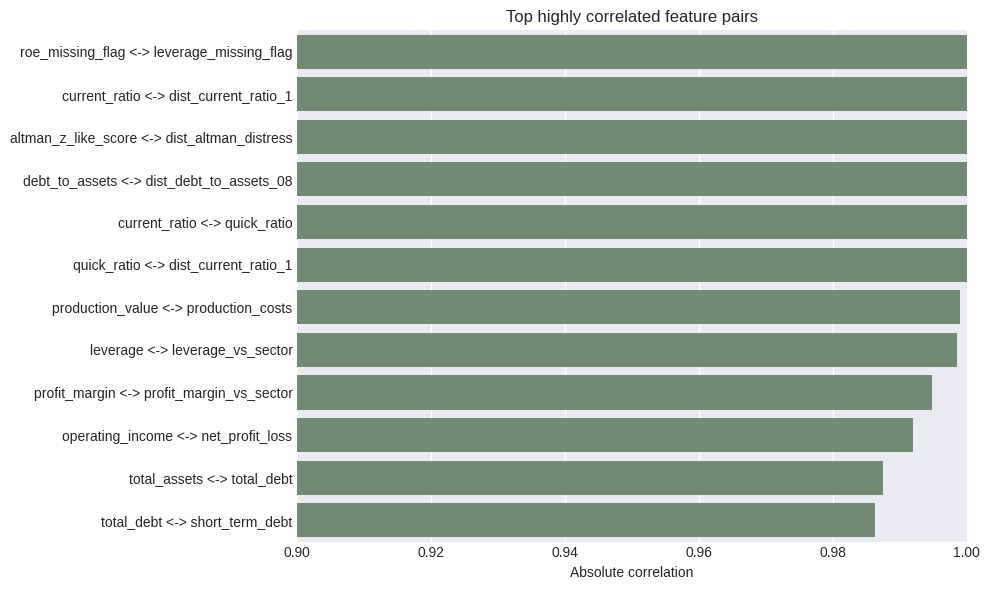

In [59]:
# Visualize the most highly correlated feature pairs on development data only
exclude_corr = ["company_id", "bankruptcy_next_year", "financial_health_class", "revenue_change"]
numeric_df = df_train_fit_fe.select_dtypes(include=[np.number]).drop(
    columns=[c for c in exclude_corr if c in df_train_fit_fe.columns],
    errors="ignore"
)

corr_matrix = numeric_df.corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and abs(val) > 0.9:
            high_corr_pairs.append((row, col, val))

# Build a compact table of the strongest correlation pairs
corr_table = pd.DataFrame(high_corr_pairs, columns=["Feature 1", "Feature 2", "Correlation"])
corr_table["Abs Correlation"] = corr_table["Correlation"].abs()
corr_table["Pair"] = corr_table["Feature 1"] + " <-> " + corr_table["Feature 2"]
corr_table = corr_table.sort_values("Abs Correlation", ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(data=corr_table, y="Pair", x="Abs Correlation", color="#6D8F71")
plt.xlim(0.9, 1.0)
plt.xlabel("Absolute correlation")
plt.ylabel("")
plt.title("Top highly correlated feature pairs")
plt.tight_layout()
plt.show()

**Interpretation of the results**

The correlation analysis identifies **22 variables** that appear in at least one pair with absolute correlation above 0.9, spanning several distinct groups of mechanically related features.

The strongest redundancies cluster around:

- **Balance-sheet aggregates**: `total_assets`, `shareholders_equity`, `total_debt`, and their decompositions (`short_term_debt`, `long_term_debt`) are strongly correlated because they are linked through fundamental accounting identities.
- **Scale-dependent income statement variables**: `production_value`, `production_costs`, `financial_expenses`, and `net_profit_loss` tend to move together with firm size.
- **Derived and raw ratio overlaps**: several engineered features are very highly correlated with their source variables — `roi_vs_sector` largely tracks `roi` within sectors, and `dist_altman_distress` closely mirrors `altman_z_like_score`.
- **Growth and acceleration pairs**: `total_debt_growth` and `total_debt_trend_up` share information about the direction of debt dynamics.

These patterns confirm that a manual pruning step is warranted before modelling. The heatmaps visualize the correlation structure to support the selection decisions in the next step.

###**10.7 Redundancy-Based Feature Selection**

After examining the correlation diagnostics, we apply a **manual redundancy-based feature selection** step to simplify the feature space and remove variables that carry duplicated information.

Financial datasets naturally contain groups of mechanically related variables, particularly those derived from balance-sheet identities or income statement aggregates. Including many highly correlated features increases model complexity without adding proportional predictive information, and can affect the stability of feature importance estimates.

Based on the correlation analysis and the economic interpretation of each variable, we remove variables belonging to four main categories:

1. **Redundant balance-sheet components**: `current_assets`, `total_fixed_assets`, `shareholders_equity`, `short_term_debt`, and `long_term_debt` are dropped because `total_assets` and `total_debt` already summarize the scale of the balance sheet.
2. **Scale-dependent income variables**: `production_costs`, `financial_expenses`, and `net_profit_loss` are excluded due to their high correlation with revenue and the other profitability indicators retained.
3. **Overlapping liquidity indicators**: `quick_ratio` is dropped in favour of `current_ratio`, which captures the same dimension with less missing data.
4. **Dominated ratio and growth features**: `roe`, `leverage`, and `profit_margin` are replaced by their sector-relative counterparts, which carry strictly more information; `total_assets_growth` and `total_assets_trend_up` are removed to avoid duplication with the debt growth variables.

The same drop list is applied consistently to development, validation, and test datasets.

In [60]:
# Apply manual redundancy-based pruning using the development-driven drop list
features_to_drop = [
    "current_assets",
    "total_fixed_assets",
    "shareholders_equity",
    "short_term_debt",
    "long_term_debt",
    "production_costs",
    "financial_expenses",
    "net_profit_loss",
    "quick_ratio",
    "total_assets_growth",
    "total_assets_trend_up",
    "roe",
    "leverage",
    "profit_margin",
]

# Drop the same redundant columns from development, validation, and test
for frame in (df_train_fit_fe, df_val_2021_fe, df_test_fe):
    drop_cols = [c for c in features_to_drop if c in frame.columns]
    frame.drop(columns=drop_cols, inplace=True)

df_train_fe = combine_train_periods(df_train_fit_fe, df_val_2021_fe)

print("Redundancy-based feature selection applied.")
print(f"Development FE shape: {df_train_fit_fe.shape}")
print(f"Validation FE shape:  {df_val_2021_fe.shape}")
print(f"Test FE shape:        {df_test_fe.shape}")

# Check train-test column alignment after pruning
train_cols = set(df_train_fe.columns)
test_cols = set(df_test_fe.columns)
print()
print("Columns only in combined TRAIN after selection:")
print(train_cols - test_cols)
print()
print("Columns only in TEST after selection:")
print(test_cols - train_cols)

Redundancy-based feature selection applied.
Development FE shape: (8896, 52)
Validation FE shape:  (2932, 52)
Test FE shape:        (5811, 49)

Columns only in combined TRAIN after selection:
{'bankruptcy_next_year', 'revenue_change', 'financial_health_class'}

Columns only in TEST after selection:
set()


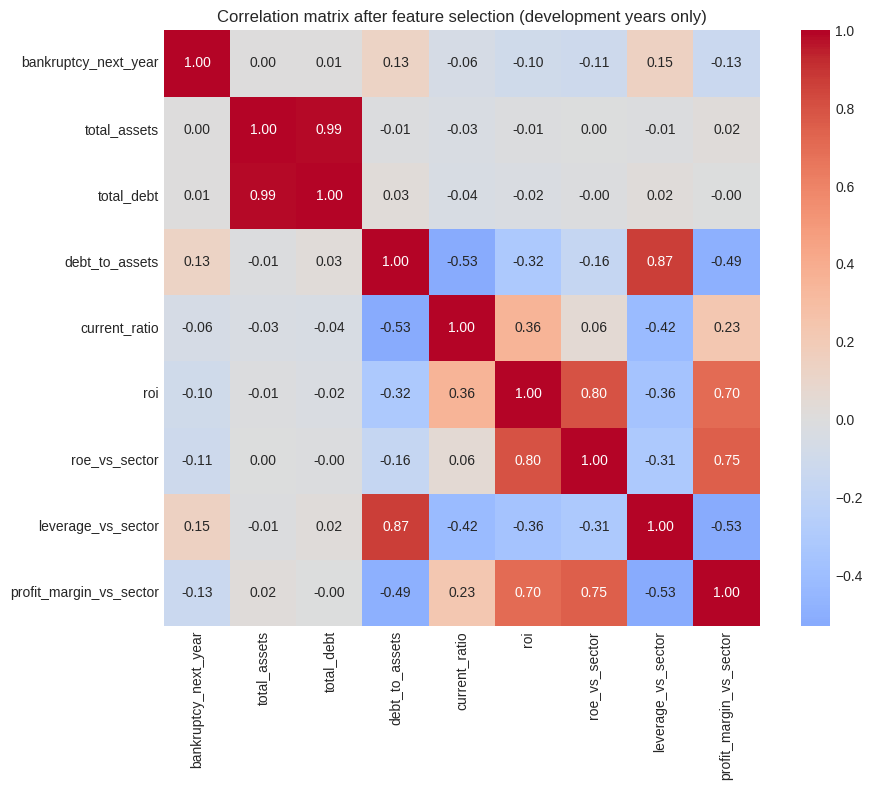

In [61]:
# Inspect the remaining correlation structure after manual feature selection
final_heatmap_cols = [
    "bankruptcy_next_year",
    "total_assets",
    "total_debt",
    "debt_to_assets",
    "current_ratio",
    "roi",
    "roe_vs_sector",
    "leverage_vs_sector",
    "profit_margin_vs_sector",
]

final_heatmap_cols = [c for c in final_heatmap_cols if c in df_train_fit_fe.columns]
corr_final = df_train_fit_fe[final_heatmap_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_final,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlation matrix after feature selection (development years only)")
plt.tight_layout()
plt.show()

**Interpretation of the results**

The redundancy-based feature selection step removes **14 variables** from the dataset, reducing the feature space while preserving all distinct dimensions of financial information.

After pruning, the three datasets contain:

- **52 columns** in the development dataset (8,896 rows)
- **52 columns** in the validation dataset (2,932 rows)
- **49 columns** in the test dataset (5,811 rows)

The difference of three columns between the training-side datasets and the test set corresponds entirely to the **target variables** (`bankruptcy_next_year`, `financial_health_class`, `revenue_change`) that are available only in the labelled data.

The post-selection correlation heatmap confirms that the remaining features show substantially reduced pairwise redundancy. Variables such as `debt_to_assets`, `current_ratio`, and the sector-relative indicators now occupy clearly distinct roles in the feature space.

The pruned datasets are passed to the clustering stage, which will add a final categorical feature encoding each firm's financial profile group.

###**10.8 Unsupervised Clustering of Financial Profiles**

**Two-Stage Clustering Strategy**

To complement the individually engineered features, we add an **unsupervised clustering step** that assigns each firm-year to a financial profile group. This provides the model with a compact, non-linear summary of a firm's overall financial positioning, which can capture combinations of signals that are difficult to express through individual features alone.

The clustering is organized in **two sequential stages**, each serving a distinct purpose.

The **first stage** is a **broad exploratory clustering** built on the full set of available numerical features. Its purpose is descriptive: to understand how firms naturally group in the high-dimensional financial space and to identify which features most clearly separate the resulting groups.

The **second stage** is a **practical clustering** built on a reduced and focused variable set, selected on the basis of the broad clustering findings. This produces the clustering feature actually retained in the model — more compact, more interpretable, and more stable than one derived from 40+ variables.

In both stages, the clustering model is fitted **exclusively on the 2018-2020 development data** to prevent leakage, and then applied to assign labels to the validation and test datasets.

####**Broad Exploratory Clustering**

The broad exploratory clustering uses a **wide set of numerical financial variables** — the full 43-feature space available after the engineering steps above — to produce an initial segmentation of firms.

Before fitting the final model, we determine the most appropriate **number of clusters (K)** by comparing candidate values using three complementary diagnostics:

- **WCSS** (within-cluster sum of squares): measures how compact the clusters are; always decreases with K, so it is used to identify the point of diminishing returns.
- **Silhouette score**: measures how well each observation fits its assigned cluster relative to others; higher values indicate better-separated groups.
- **Davies-Bouldin index**: lower values indicate more compact and better-separated clusters simultaneously.

Candidate values of K from 2 to 8 are evaluated. The clustering model is fitted **only on the 2018-2020 development data**, with development-only medians used to handle missing values before standardization. The purpose of this stage is diagnostic: the broad cluster labels inform the variable selection for the practical clustering that follows.

In [62]:
# Broad exploratory clustering: build a wide numeric feature space
exclude_cluster = [
    "company_id",
    "fiscal_year",
    "bankruptcy_next_year",
    "financial_health_class",
    "revenue_change",
]

cluster_features_broad = [
    c for c in df_train_fit_fe.select_dtypes(include=[np.number]).columns
    if c not in exclude_cluster
    and c in df_val_2021_fe.columns
    and c in df_test_fe.columns
]

print(f"Broad clustering features used ({len(cluster_features_broad)}):")
print(cluster_features_broad)

# Use development medians to fill missing values before scaling
cluster_medians_broad = df_train_fit_fe[cluster_features_broad].median()
X_cl_fit_broad = df_train_fit_fe[cluster_features_broad].fillna(cluster_medians_broad)
X_cl_val_broad = df_val_2021_fe[cluster_features_broad].fillna(cluster_medians_broad)
X_cl_test_broad = df_test_fe[cluster_features_broad].fillna(cluster_medians_broad)

# Fit the clustering scaler on development data only
scaler_cl_broad = StandardScaler()
X_cl_fit_scaled_broad = scaler_cl_broad.fit_transform(X_cl_fit_broad)
X_cl_val_scaled_broad = scaler_cl_broad.transform(X_cl_val_broad)
X_cl_test_scaled_broad = scaler_cl_broad.transform(X_cl_test_broad)

# Compare candidate values of K using development data only
results_broad = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cl_fit_scaled_broad)
    results_broad.append(
        {
            "k": k,
            "wcss": kmeans.inertia_,
            "silhouette": silhouette_score(X_cl_fit_scaled_broad, labels),
            "davies_bouldin": davies_bouldin_score(X_cl_fit_scaled_broad, labels),
        }
    )

results_broad_df = pd.DataFrame(results_broad)
print()
print("Candidate K results for broad clustering:")
display(results_broad_df)

Broad clustering features used (43):
['years_in_business', 'total_assets', 'total_debt', 'production_value', 'operating_income', 'financial_income', 'roi', 'current_ratio', 'debt_to_assets', 'roe_missing_flag', 'leverage_missing_flag', 'profit_margin_missing_flag', 'roi_missing_flag', 'current_ratio_missing_flag', 'debt_to_assets_missing_flag', 'altman_z_like_score', 'production_value_growth', 'production_value_trend_up', 'total_debt_growth', 'total_debt_trend_up', 'operating_income_growth', 'operating_income_trend_up', 'production_value_volatility', 'operating_income_volatility', 'roi_slope', 'current_ratio_slope', 'debt_to_assets_slope', 'profit_margin_slope', 'neg_margin_streak', 'neg_oi_streak', 'low_liquidity_streak', 'total_debt_acceleration', 'production_value_acceleration', 'dist_current_ratio_1', 'dist_debt_to_assets_08', 'margin_declining_2y', 'roi_declining_2y', 'leverage_rising_2y', 'dist_altman_distress', 'roe_vs_sector', 'roi_vs_sector', 'leverage_vs_sector', 'profit_marg

,k,wcss,silhouette,davies_bouldin
0,2,301018.222041,0.234845,2.000942
1,3,265215.053341,0.237781,1.734966
2,4,237431.887138,0.232732,1.472352
3,5,222038.085724,0.147549,1.641938
4,6,203539.005887,0.160031,1.446634
5,7,194743.799121,0.115939,1.582178
6,8,187244.356368,0.122174,1.618413


**Interpretation of the results**

The broad clustering diagnostics evaluate candidate values of K from 2 to 8, measuring cluster compactness and separation through three complementary indicators.

The silhouette score peaks at **K = 3** (0.238), while the **Davies-Bouldin index** reaches its minimum at **K = 4** (1.472), indicating that four clusters produce the most compact and well-separated partition of the broad financial feature space.

For values of K above 4, both the silhouette score and the Davies-Bouldin index deteriorate, suggesting that adding more clusters beyond this point introduces fragmentation rather than genuine new structure in the data.

We therefore select **K = 4** for the broad exploratory stage. This choice satisfies the Davies-Bouldin criterion — which penalizes both poor separation and cluster dispersion simultaneously — and provides four broad financial profile groups to guide the variable selection for the practical clustering in the next step.

**Final Broad Exploratory Clustering**

Having selected K = 4, we fit the broad clustering model on the 2018-2020 development data and use it to assign a cluster label (`cluster_id_broad`) to each firm-year observation across all three datasets.

The model is fitted using K-Means with 10 random initialisations to reduce sensitivity to the initial centroid placement. Features are standardized before fitting using the development-only mean and standard deviation.

The fitted model is then applied in a strictly leakage-safe manner:

- the **development data** receives cluster assignments from the model trained on that same period
- the **validation and test data** receive assignments from the same fitted model, without re-estimating any parameters

The resulting cluster profile table reports the composition, bankruptcy rate, and median financial indicators of each broad cluster, sorted from highest to lowest bankruptcy prevalence.

In [63]:
# Fit the final broad clustering on development data only
final_k_broad = 4

kmeans_broad = KMeans(n_clusters=final_k_broad, random_state=42, n_init=10)
kmeans_broad.fit(X_cl_fit_scaled_broad)

# Assign the broad-cluster label to development, validation, and test
df_train_fit_fe["cluster_id_broad"] = kmeans_broad.predict(X_cl_fit_scaled_broad)
df_val_2021_fe["cluster_id_broad"] = kmeans_broad.predict(X_cl_val_scaled_broad)
df_test_fe["cluster_id_broad"] = kmeans_broad.predict(X_cl_test_scaled_broad)
df_train_fe = combine_train_periods(df_train_fit_fe, df_val_2021_fe)

print()
print(f"K-Means (k={final_k_broad}) applied. New feature: 'cluster_id_broad'")

# Select the most interpretable variables for broad-cluster profiling
summary_vars_broad = [c for c in cluster_features_broad if c in [
    "altman_z_like_score",
    "current_ratio",
    "debt_to_assets",
    "financial_income",
    "operating_income",
    "operating_income_growth",
    "operating_income_trend_up",
    "operating_income_volatility",
    "production_value",
    "production_value_growth",
    "production_value_trend_up",
    "production_value_volatility",
    "profit_margin_vs_sector",
    "roe_vs_sector",
    "roi",
    "roi_vs_sector",
    "leverage_vs_sector",
    "total_assets",
    "total_debt",
    "total_debt_growth",
    "total_debt_trend_up",
    "years_in_business",
]]

if "bankruptcy_next_year" in df_train_fit_fe.columns:
    # Profile each broad cluster using development years only
    agg_dict_broad = {"company_id": "count", "bankruptcy_next_year": "mean"}
    for col in summary_vars_broad:
        agg_dict_broad[col] = "median"

    cluster_summary_broad = (
        df_train_fit_fe.groupby("cluster_id_broad")
        .agg(agg_dict_broad)
        .rename(columns={"company_id": "count", "bankruptcy_next_year": "bankruptcy_rate"})
    )
    cluster_summary_broad["proportion"] = cluster_summary_broad["count"] / len(df_train_fit_fe)
    cluster_summary_broad = cluster_summary_broad.sort_values("bankruptcy_rate", ascending=False)

    print()
    print("Broad-cluster analysis (development years only):")
    display(
        cluster_summary_broad[["count", "proportion", "bankruptcy_rate"] + summary_vars_broad].round(4)
    )


K-Means (k=4) applied. New feature: 'cluster_id_broad'

Broad-cluster analysis (development years only):


,count,proportion,bankruptcy_rate,years_in_business,total_assets,total_debt,production_value,operating_income,financial_income,roi,current_ratio,debt_to_assets,altman_z_like_score,production_value_growth,production_value_trend_up,total_debt_growth,total_debt_trend_up,operating_income_growth,operating_income_trend_up,production_value_volatility,operating_income_volatility,roe_vs_sector,roi_vs_sector,leverage_vs_sector,profit_margin_vs_sector
cluster_id_broad,,,,,,,,,,,,,,,,,,,,,,,,,
2,1317,0.1480,0.0402,37.0,4.967457e+08,4.084423e+08,6.840642e+08,7.761319e+06,1.071629e+06,0.0238,1.3513,0.8095,1.8949,0.000,0.0,0.0000,0.0,-0.5262,0.0,2.855674e+08,1.981908e+07,-0.2183,-0.0768,2.4427,-0.0636
0,2144,0.2410,0.0014,35.0,1.107673e+09,6.539362e+08,1.785114e+09,1.455497e+08,2.262855e+06,0.1254,1.8815,0.6098,2.8612,3.377,1.0,3.0916,1.0,3.9558,1.0,9.660829e+08,8.193202e+07,0.0417,0.0180,-0.1106,0.0107
1,5410,0.6081,0.0013,34.0,3.766544e+08,2.191843e+08,5.803680e+08,4.518247e+07,7.846154e+05,0.1192,1.9109,0.5956,2.8070,0.000,0.0,0.0000,0.0,0.0000,0.0,2.960054e+07,2.753106e+06,0.0171,0.0091,-0.1850,0.0071
3,25,0.0028,0.0000,32.0,1.732749e+11,1.006581e+11,2.640891e+11,1.965090e+10,5.147753e+08,0.1242,1.4782,0.5940,2.4062,5.000,1.0,5.0000,1.0,5.0000,1.0,6.835823e+10,5.260784e+09,0.0058,0.0168,-0.2652,0.0245


**Interpretation of the results**

The broad exploratory clustering assigns all firm-year observations to **four financial profile groups**, with substantially different bankruptcy rates across clusters.

The summary table is sorted by bankruptcy rate, placing the riskiest group at the top. The results show:

- **Cluster 2** is the riskiest broad profile, with a **bankruptcy rate of 4.0%** — roughly five to six times the overall development-period bankruptcy rate. This cluster contains 14.8% of the development sample.
- **Clusters 0 and 1** together account for the majority of observations (approximately 84%) and show very low bankruptcy rates (around 0.1-0.2%), suggesting that the large majority of firms in the dataset are financially stable.
- **Cluster 3** is extremely small (25 firms, 0.3% of the sample) with no observed bankruptcies, likely representing a group of atypical firms with distinctive financial characteristics.

These findings confirm that the broad clustering captures meaningful variation in financial health. The strong concentration of bankruptcies in a single cluster will guide the choice of variables for the practical clustering in the next stage.

####**10.9 Final Practical Clustering**

**Cluster-Number Selection (Practical Clustering)**

We now move to the **second stage** of the clustering strategy: the practical clustering, which produces the cluster feature retained in the final model.

Unlike the broad stage, this clustering is based on a **reduced set of nine variables** chosen for their financial relevance and their demonstrated ability to separate firms of different risk profiles:

- `altman_z_like_score`, `current_ratio`, and `debt_to_assets` (solvency and liquidity)
- `roi` (profitability in absolute terms)
- `roe_vs_sector`, `roi_vs_sector`, `leverage_vs_sector`, and `profit_margin_vs_sector` (sector-relative performance)
- `operating_income_growth` (recent operating dynamics)

As in the broad stage, we evaluate candidate values of K from 2 to 8 using WCSS, silhouette score, and the Davies-Bouldin index. The clustering model is fitted **only on the 2018-2020 development data**, with standardization applied using development-only statistics.

In [64]:
# Practical clustering: use a smaller and more focused feature set
cluster_features_practical = [
    "altman_z_like_score",
    "current_ratio",
    "debt_to_assets",
    "roi",
    "roe_vs_sector",
    "roi_vs_sector",
    "leverage_vs_sector",
    "profit_margin_vs_sector",
    "operating_income_growth",
]

cluster_features_practical = [
    c for c in cluster_features_practical
    if c in df_train_fit_fe.columns and c in df_val_2021_fe.columns and c in df_test_fe.columns
]

print(f"Practical clustering features used ({len(cluster_features_practical)}):")
print(cluster_features_practical)

# Fill missing values using development medians only
cluster_medians_practical = df_train_fit_fe[cluster_features_practical].median()
X_cl_fit_practical = df_train_fit_fe[cluster_features_practical].fillna(cluster_medians_practical)
X_cl_val_practical = df_val_2021_fe[cluster_features_practical].fillna(cluster_medians_practical)
X_cl_test_practical = df_test_fe[cluster_features_practical].fillna(cluster_medians_practical)

# Fit the clustering scaler on development data only
scaler_cl_practical = StandardScaler()
X_cl_fit_scaled_practical = scaler_cl_practical.fit_transform(X_cl_fit_practical)
X_cl_val_scaled_practical = scaler_cl_practical.transform(X_cl_val_practical)
X_cl_test_scaled_practical = scaler_cl_practical.transform(X_cl_test_practical)

# Compare candidate values of K using development data only
results_practical = []
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cl_fit_scaled_practical)
    results_practical.append(
        {
            "k": k,
            "wcss": kmeans.inertia_,
            "silhouette": silhouette_score(X_cl_fit_scaled_practical, labels),
            "davies_bouldin": davies_bouldin_score(X_cl_fit_scaled_practical, labels),
        }
    )

results_practical_df = pd.DataFrame(results_practical)
print()
print("Candidate K results:")
display(results_practical_df)

Practical clustering features used (9):
['altman_z_like_score', 'current_ratio', 'debt_to_assets', 'roi', 'roe_vs_sector', 'roi_vs_sector', 'leverage_vs_sector', 'profit_margin_vs_sector', 'operating_income_growth']

Candidate K results:


,k,wcss,silhouette,davies_bouldin
0,2,56554.245440,0.295508,1.220565
1,3,43680.798815,0.265607,1.340473
2,4,38213.675578,0.208448,1.450829
3,5,33634.784736,0.226694,1.320866
4,6,30513.693003,0.213657,1.277713
5,7,28372.429648,0.205188,1.344735
6,8,26673.339160,0.198622,1.352142


**Interpretation of the results**

The practical clustering diagnostics show that **K = 2** achieves the highest silhouette score (0.296) and the lowest Davies-Bouldin index (1.221), indicating that the data most naturally separates into two broad groups when described through this focused feature set.

However, a two-cluster solution would partition firms into only two categories — roughly a high-risk and a low-risk group — which provides limited additional information beyond what individual ratio features already capture. A finer segmentation reveals whether the riskiest firms form a distinct, internally coherent subgroup, or whether risk is distributed across multiple different financial profiles.

**K = 4** is selected for the practical clustering. While its silhouette score is lower than K = 2, it produces four interpretable financial profiles consistent with the broad exploratory stage. The resulting `cluster_id_practical` feature exposes finer-grained structure in the data to the downstream classifier.

**Final Practical Clustering of Financial Profiles**

Having selected K = 4, we fit the final practical clustering on the 2018-2020 development data and assign the resulting label (`cluster_id_practical`) to all three datasets.

The model is fitted using K-Means with 10 random initialisations, with features standardized using development-only statistics. The same fitted model is then used to assign cluster membership to the validation and test observations without re-estimating any parameters.

The cluster profile table reports the key financial indicators for each group — including bankruptcy rate, Altman-like score, current ratio, debt-to-assets, ROI, and sector-relative benchmarks — sorted from highest to lowest bankruptcy prevalence. A heatmap of standardized cluster profiles is also produced to highlight the relative financial strengths and weaknesses of each group.

In [65]:
# Fit the final practical clustering on development data only
final_k_practical = 4

kmeans_practical = KMeans(n_clusters=final_k_practical, random_state=42, n_init=10)
kmeans_practical.fit(X_cl_fit_scaled_practical)

# Assign the practical-cluster label to development, validation, and test
df_train_fit_fe["cluster_id_practical"] = kmeans_practical.predict(X_cl_fit_scaled_practical)
df_val_2021_fe["cluster_id_practical"] = kmeans_practical.predict(X_cl_val_scaled_practical)
df_test_fe["cluster_id_practical"] = kmeans_practical.predict(X_cl_test_scaled_practical)
df_train_fe = combine_train_periods(df_train_fit_fe, df_val_2021_fe)

print()
print(f"K-Means (k={final_k_practical}) applied. New feature: 'cluster_id_practical'")

# Profile the practical clusters using the selected practical features
summary_vars_practical = cluster_features_practical.copy()

if "bankruptcy_next_year" in df_train_fit_fe.columns:
    agg_dict_practical = {"company_id": "count", "bankruptcy_next_year": "mean"}
    for col in summary_vars_practical:
        agg_dict_practical[col] = "median"

    cluster_summary_practical = (
        df_train_fit_fe.groupby("cluster_id_practical")
        .agg(agg_dict_practical)
        .rename(columns={"company_id": "count", "bankruptcy_next_year": "bankruptcy_rate"})
    )
    cluster_summary_practical["proportion"] = cluster_summary_practical["count"] / len(df_train_fit_fe)
    cluster_summary_practical = cluster_summary_practical.sort_values("bankruptcy_rate", ascending=False)

    print()
    print("Practical-cluster analysis (development years only):")
    display(
        cluster_summary_practical[["count", "proportion", "bankruptcy_rate"] + summary_vars_practical].round(4)
    )


K-Means (k=4) applied. New feature: 'cluster_id_practical'

Practical-cluster analysis (development years only):


,count,proportion,bankruptcy_rate,altman_z_like_score,current_ratio,debt_to_assets,roi,roe_vs_sector,roi_vs_sector,leverage_vs_sector,profit_margin_vs_sector,operating_income_growth
cluster_id_practical,,,,,,,,,,,,
0,1424,0.1601,0.0421,1.9867,1.4034,0.8060,0.0266,-0.2162,-0.0804,2.3516,-0.0621,-0.3579
2,3227,0.3627,0.0009,2.2590,1.5183,0.6567,0.1039,0.0368,0.0080,0.2365,0.0077,0.0000
1,1665,0.1872,0.0000,4.3365,2.1242,0.6046,0.2471,0.2607,0.1070,-0.1557,0.0368,0.0000
3,2580,0.2900,0.0000,2.9853,2.2845,0.5257,0.1028,-0.0653,-0.0152,-0.5587,-0.0099,0.0000


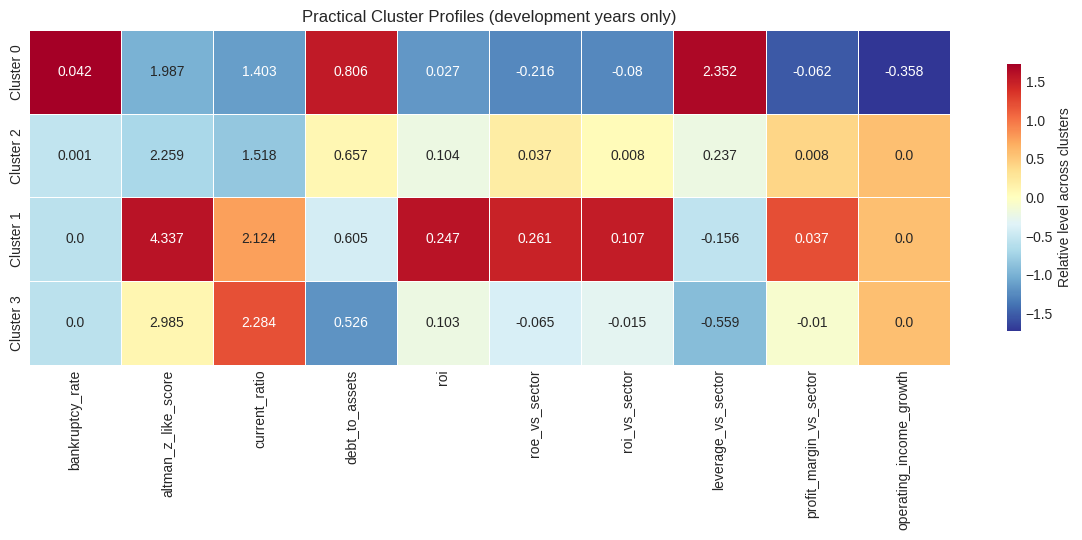

In [66]:
# Visualize the relative profile of each practical cluster
if "cluster_summary_practical" in locals():
    heatmap_vars = [
        "bankruptcy_rate",
        "altman_z_like_score",
        "current_ratio",
        "debt_to_assets",
        "roi",
        "roe_vs_sector",
        "roi_vs_sector",
        "leverage_vs_sector",
        "profit_margin_vs_sector",
        "operating_income_growth",
    ]

    heatmap_vars = [c for c in heatmap_vars if c in cluster_summary_practical.columns]
    cluster_heatmap_raw = cluster_summary_practical[heatmap_vars].copy()

    # Standardize across clusters to highlight relative strengths and weaknesses
    cluster_heatmap_z = (cluster_heatmap_raw - cluster_heatmap_raw.mean()) / cluster_heatmap_raw.std(ddof=0)

    cluster_name_map = {idx: f"Cluster {idx}" for idx in cluster_heatmap_z.index}
    cluster_heatmap_z.index = [cluster_name_map[idx] for idx in cluster_heatmap_z.index]
    cluster_heatmap_raw.index = [cluster_name_map[idx] for idx in cluster_heatmap_raw.index]

    plt.figure(figsize=(12, 5.5))
    sns.heatmap(
        cluster_heatmap_z,
        annot=cluster_heatmap_raw.round(3),
        fmt="",
        cmap="RdYlBu_r",
        center=0,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Relative level across clusters"},
    )
    plt.title("Practical Cluster Profiles (development years only)")
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

**Interpretation of the results**

The final practical clustering assigns each firm-year observation to one of **four distinct financial profiles** through the variable `cluster_id_practical`. The profile table is sorted by bankruptcy rate, placing the most fragile group at the top.

The results show a clear concentration of financial risk:

- **Cluster 0** is the riskiest group with a **bankruptcy rate of 4.2%** — approximately six times the development-period average. It contains 16.0% of the training sample and is characterized by a **low Altman-like score (1.99)**, placing it within the distress zone under the standard thresholds.
- **Cluster 2** accounts for the largest share of the sample (36.3%) with a very low bankruptcy rate (0.09%), representing firms with moderate but generally stable financial characteristics.
- **Clusters 1 and 3** show zero observed bankruptcies in the development data, representing firm profiles with consistently healthier financial indicators across all practical clustering variables.

The concentration of bankruptcies in Cluster 0 confirms that the practical clustering is capturing a genuine signal: membership in this group is associated with a substantially elevated probability of financial failure, providing the downstream classifier with a useful pre-stratification of the feature space.

####**10.10 Visual Representation of the Final Practical Clusters**


To complement the numerical cluster summary, we visualize the final practical clustering in a **two-dimensional projection** of the feature space.

Since the clustering is defined in a nine-dimensional space, it cannot be directly plotted. We apply **Principal Component Analysis (PCA)** to project the practical clustering features down to two synthetic dimensions — **PC1** and **PC2** — that summarize the main directions of variation in the data.

These principal components do not correspond to individual original variables. They represent linear combinations of the nine practical clustering features that capture the largest fraction of total variance.

The purpose of this plot is **illustrative rather than definitive**: it provides an intuitive view of how the four practical clusters are positioned relative to one another, and whether they form recognizable regions or show significant overlap in the reduced feature space. The clustering itself remains defined in the original nine-dimensional space.

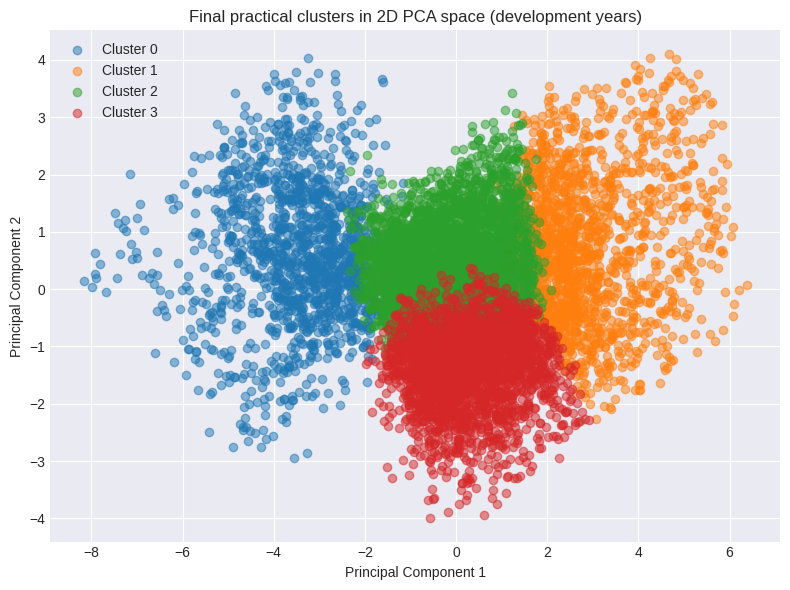

In [67]:
# PCA visualization of the final practical clusters
cluster_features_final = [
    "altman_z_like_score",
    "current_ratio",
    "debt_to_assets",
    "roi",
    "roe_vs_sector",
    "roi_vs_sector",
    "leverage_vs_sector",
    "profit_margin_vs_sector",
    "operating_income_growth",
]

cluster_features_final = [c for c in cluster_features_final if c in df_train_fit_fe.columns]

# Prepare the development feature matrix for 2D visualization
X_vis = df_train_fit_fe[cluster_features_final].copy().fillna(df_train_fit_fe[cluster_features_final].median())

scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

pca = PCA(n_components=2, random_state=42)
X_vis_pca = pca.fit_transform(X_vis_scaled)

plot_df = pd.DataFrame(
    {
        "PC1": X_vis_pca[:, 0],
        "PC2": X_vis_pca[:, 1],
        "cluster_id_practical": df_train_fit_fe["cluster_id_practical"].values,
    }
)

plt.figure(figsize=(8, 6))
for cl in sorted(plot_df["cluster_id_practical"].unique()):
    subset = plot_df[plot_df["cluster_id_practical"] == cl]
    plt.scatter(subset["PC1"], subset["PC2"], alpha=0.5, label=f"Cluster {cl}")

plt.title("Final practical clusters in 2D PCA space (development years)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation of the results**

The PCA scatter plot provides a visual representation of the **four practical clusters** in a reduced two-dimensional space, where each point is a firm-year observation from the development data colored by its cluster assignment.

The figure shows that the clusters occupy **broadly distinct regions** of the PCA space, confirming that the K-Means algorithm has identified meaningful internal structure in the financial feature space.

Some degree of overlap between clusters is expected and visible, since PCA captures only a portion of the total variance in the nine-dimensional space. The true cluster boundaries are defined in the original feature space, where separation may be cleaner than what is visible in two dimensions.

The `cluster_id_practical` label is retained as a categorical feature in the final model. The visual confirms that it encodes genuine distributional differences across groups, which the classifier can exploit alongside the other engineered indicators.

### **10.11 Save Enhanced Data**

After completing the feature engineering pipeline, we save the resulting datasets as **stable intermediate files** that serve as the input for the subsequent model preparation phase.

At this point, each dataset contains the full set of engineered features, including:

- the cleaned and winsorized base financial variables
- the Altman-like distress score
- temporal growth, trend, and volatility indicators
- distress trajectory features
- sector-relative ratio benchmarks
- the broad and practical cluster labels

These files are saved before any further model-oriented transformations are applied. The model preparation phase (Section 11) will add log transformation of selected magnitudes, leakage-safe categorical encoding, and final feature matrix alignment — steps that are best applied after the feature space has been fully assembled.

Two files are produced: `train_data_enhanced.csv` covering the full labelled period (2018-2021), and `test_features_enhanced.csv` covering the 2022-2023 test period.

In [68]:
# Save the final enhanced datasets after feature engineering
df_train_fe = combine_train_periods(df_train_fit_fe, df_val_2021_fe)

df_train_fe.to_csv("train_data_enhanced.csv", index=False)
df_test_fe.to_csv("test_features_enhanced.csv", index=False)

print("Saved to: train_data_enhanced.csv")
print("Saved to: test_features_enhanced.csv")
print()
print("Feature Engineering Pipeline Completed Successfully.")
print(f"Development FE rows: {df_train_fit_fe.shape[0]}")
print(f"Validation FE rows:  {df_val_2021_fe.shape[0]}")
print(f"Combined Train rows:  {df_train_fe.shape[0]}")
print(f"Final Test rows:      {df_test_fe.shape[0]}")

Saved to: train_data_enhanced.csv
Saved to: test_features_enhanced.csv

Feature Engineering Pipeline Completed Successfully.
Development FE rows: 8896
Validation FE rows:  2932
Combined Train rows:  11828
Final Test rows:      5811


**Interpretation of the results**

The output confirms that both enhanced datasets have been saved successfully and that the feature engineering pipeline has completed without errors.

The saved files cover:

- **11,828 rows** in the combined training dataset, spanning all labelled firm-year observations from 2018 to 2021
- **5,811 rows** in the test dataset, covering the 2022-2023 prediction period

The column counts differ between the two files: the training dataset retains the three target variables (`bankruptcy_next_year`, `financial_health_class`, `revenue_change`), which are absent from the test file as intended.

The feature engineering phase is now complete. The datasets produced here will be loaded at the start of Section 11, where they will undergo log transformation of selected financial magnitudes, leakage-safe one-hot encoding of categorical variables, and final alignment of the feature matrices before model fitting.

## **11. Model Preparation - Data Preprocessing II**

In this section we convert the feature-engineered datasets into **leakage-safe modelling matrices** ready for the binary classification pipeline.

The feature engineering phase assembled a rich set of indicators, but several model-oriented transformations still need to be applied before fitting. Three sequential steps are carried out here:

1. **Log transformation of magnitude variables** — accounting totals and revenue figures are right-skewed and span several orders of magnitude. Applying `log1p` compresses the distribution without requiring any split-specific statistics, so it can be applied identically across development, validation, and test.
2. **Leakage-safe categorical encoding** — categorical variables are one-hot encoded using the **development-data schema only**. The validation and test frames are then reindexed to that same column set, filling any unseen categories with zero. This ensures that no information from future periods influences the encoding.
3. **Feature matrix construction** — identifiers (`company_id`) and the target column (`bankruptcy_next_year`) are separated from the predictors, producing the final `X` and `y` arrays used throughout Section 12.

The temporal split established in earlier sections is preserved throughout: the **development window (2018-2020)** drives all schema-dependent steps, the **validation year (2021)** is reserved for a single honest evaluation after model tuning, and the **test period (2022-2023)** is scored only once with the frozen production model.

We already know from the earlier sections that bankruptcies in this dataset are an **extreme rare event** (~0.7% per year). This structural feature is the single most important constraint on everything that follows: it limits what any binary classifier can realistically achieve on F1, and it motivates the threshold logic introduced in Section 12.

### **11.1 Imports and Local Setup**

We load all libraries required for the modelling phase — classifiers, resampling utilities, metrics, and visualization tools — and define the global random state used throughout Sections 11 and 12 to ensure reproducibility.

In [69]:
# Imports for the modelling section (Sections 11 & 12)
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sp_stats

from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

repo_root = Path.cwd()
if not (repo_root / 'data').exists() and (repo_root.parent / 'data').exists():
    repo_root = repo_root.parent

RANDOM_STATE = 42

### **11.2 Log Transformation and Column Cleanup**

Financial magnitude variables like balance-sheet totals, revenue, and income figures span several orders of magnitude and typically follow a **right-skewed distribution**. Leaving them on their original scale can distort distance-based computations and reduce the effectiveness of regularization in linear models.

We apply a `log1p` transformation to the four main magnitude variables: `total_assets`, `total_debt`, `production_value`, and `financial_income`. This transformation is applied identically across development, validation, and test datasets, since it does not require estimating any statistics from the training data.

At the same time, we drop columns that are not intended as model features:

- **Alternative target variables** (`financial_health_class`, `revenue_change`) are removed so the classifier sees only the binary bankruptcy label.
- **Geographic and label-only text fields** (`province`, `ateco_sector_label`) are dropped because their information is already captured by the sector-relative features and the one-hot encoding of ATECO applied in the next step.
- **The broad cluster label** (`cluster_id_broad`) is removed; only the more focused `cluster_id_practical` is retained.

In [70]:
# Start from the engineered datasets produced in Section 10
train_model = df_train_fit_fe.copy().reset_index(drop=True)
val_model   = df_val_2021_fe.copy().reset_index(drop=True)
test_model  = df_test_fe.copy().reset_index(drop=True)

target_col  = 'bankruptcy_next_year'
cluster_col = 'cluster_id_practical'

# log1p on magnitude variables (deterministic transform, safe across splits)
candidate_log_features = ['total_assets', 'total_debt', 'production_value', 'financial_income']
log_features = [
    c for c in candidate_log_features
    if c in train_model.columns and train_model[c].min() >= 0
]
for col in log_features:
    train_model[col] = np.log1p(train_model[col])
    if col in val_model.columns:
        val_model[col] = np.log1p(val_model[col])
    if col in test_model.columns:
        test_model[col] = np.log1p(test_model[col])

# Drop non-model columns (alternative targets, text labels, broad cluster id)
cols_to_drop = ['province', 'financial_health_class', 'revenue_change',
                'ateco_sector_label', 'cluster_id_broad']
for frame in (train_model, val_model, test_model):
    frame.drop(columns=cols_to_drop, errors='ignore', inplace=True)

print(f'Development table: {train_model.shape}')
print(f'Validation table:  {val_model.shape}')
print(f'Test table:        {test_model.shape}')
print(f'Log-transformed:   {log_features}')

Development table: (8896, 50)
Validation table:  (2932, 50)
Test table:        (5811, 49)
Log-transformed:   ['total_assets', 'total_debt', 'production_value', 'financial_income']


**Interpretation of the results**

The log transformation and cleanup step successfully prepares the working datasets for the encoding and modelling steps that follow.

After dropping the non-feature columns, the three datasets each contain **50 columns** (development and validation) and **49 columns** (test), with the one-column difference attributable to the `bankruptcy_next_year` target variable that is present only in the labelled data.

Four magnitude variables are log-transformed:

- `total_assets` and `total_debt` — balance-sheet size variables spanning several orders of magnitude
- `production_value` — annual revenue, which varies widely across firm sizes
- `financial_income` — a typically small and right-skewed income component

Applying `log1p` to these variables compresses their distributions without altering the relative ordering of observations, and without introducing any dependence on split-specific statistics.

### **11.3 Leakage-Safe Encoding and Feature Alignment**

The remaining categorical variables such as `ateco_sector`, `region`, `legal_form`, and the practical cluster label `cluster_id_practical` must be converted to numerical form before the classifiers can use them.

We apply **one-hot encoding** using only the **development data (2018-2020)** as the reference schema. This means that the set of dummy columns is defined entirely by the categories observed in the development period.

Once the development schema is fixed, the validation and test frames are **reindexed** to match that same column layout exactly:

- categories present in development but absent in a future period receive a column of zeros in that period
- categories appearing only in validation or test (unseen during development) are silently discarded

This approach guarantees that the feature matrices for all three periods are **perfectly aligned** in both shape and column order, and that no information from future periods influences the encoding schema.

In [71]:
# One-hot encode using the development schema as reference
categorical_cols = [
    c for c in ['ateco_sector', 'region', 'legal_form', cluster_col]
    if c in train_model.columns
]

train_encoded = pd.get_dummies(train_model, columns=categorical_cols, drop_first=False)
val_encoded   = pd.get_dummies(val_model,   columns=categorical_cols, drop_first=False)
test_encoded  = pd.get_dummies(test_model,  columns=categorical_cols, drop_first=False)

train_reference_cols = train_encoded.columns.tolist()
test_reference_cols  = [c for c in train_reference_cols if c != target_col]

val_encoded  = val_encoded.reindex(columns=train_reference_cols, fill_value=0)
test_encoded = test_encoded.reindex(columns=test_reference_cols,  fill_value=0)

print(f'Encoded dev shape:  {train_encoded.shape}')
print(f'Encoded val shape:  {val_encoded.shape}')
print(f'Encoded test shape: {test_encoded.shape}')

Encoded dev shape:  (8896, 81)
Encoded val shape:  (2932, 81)
Encoded test shape: (5811, 80)


**Interpretation of the results**

The encoding step expands the feature space by converting the four categorical variables into **binary dummy columns** using the development schema as the reference.

After one-hot encoding and reindexing:

- The **development dataset** contains **81 columns** (8,896 rows)
- The **validation dataset** contains **81 columns** (2,932 rows), perfectly aligned with the development schema
- The **test dataset** contains **80 columns** (5,811 rows), with one fewer column corresponding to the absent target variable

The reindexing step ensures that any category present in the development data but unobserved in a future period is represented by a zero-filled column rather than causing a shape mismatch. This makes the pipeline robust to distributional shifts in the categorical variables across time periods.

### **11.4 Final Modelling Matrices**

With encoding complete, we separate the predictors from the non-feature columns to produce the final input arrays for the classifiers.

`fiscal_year` and `company_id` are retained inside the encoded tables so that Section 12 can construct temporal cross-validation folds and perform error analysis by firm identifier. However, both columns are **excluded from the feature matrix** `X` used for model fitting.

The final construction step casts all feature columns to `float` to ensure compatibility with the full range of classifiers, then builds:

- **`X_train` / `y_train`** — the 2018-2020 development set used for hyperparameter search and threshold calibration
- **`X_val` / `y_val`** — the 2021 validation year used for final model selection
- **`X_test`** — the 2022-2023 test period used only for final prediction

In [72]:
# Columns that must NOT be used as model features
NON_FEATURE_COLS = {target_col, 'company_id', 'fiscal_year'}

feature_cols = [c for c in train_reference_cols if c not in NON_FEATURE_COLS]

for df in (train_encoded, val_encoded, test_encoded):
    df[feature_cols] = df[feature_cols].astype(float)

X_train = train_encoded[feature_cols].copy()
y_train = train_encoded[target_col].astype(int).copy()
X_val   = val_encoded[feature_cols].copy()
y_val   = val_encoded[target_col].astype(int).copy()
X_test  = test_encoded[feature_cols].copy()

print(f'X_train: {X_train.shape} | bankruptcies: {int(y_train.sum())} ({y_train.mean():.2%})')
print(f'X_val:   {X_val.shape}   | bankruptcies: {int(y_val.sum())} ({y_val.mean():.2%})')
print(f'X_test:  {X_test.shape}')
print(f'Number of model features: {len(feature_cols)}')

X_train: (8896, 78) | bankruptcies: 63 (0.71%)
X_val:   (2932, 78)   | bankruptcies: 21 (0.72%)
X_test:  (5811, 78)
Number of model features: 78


**Interpretation of the results**

The final modelling matrices confirm that the preparation pipeline has produced correctly shaped and separated input arrays.

The feature matrix contains **78 predictors** across all three splits, after removing `company_id`, `fiscal_year`, and the target column from the 81-column encoded dataset.

The class distribution in the labelled data reflects the **extreme rarity of bankruptcies**:

- **X_train**: 63 bankruptcies out of 8,896 observations (**0.71%**)
- **X_val**: 21 bankruptcies out of 2,932 observations (**0.72%**)

The near-identical prevalence across the development and validation periods confirms that the temporal split did not accidentally concentrate bankruptcies in one window.

These arrays are now the sole inputs to Section 12, where all model fitting, threshold calibration, and evaluation will be performed exclusively on these matrices — with no further access to the raw data.

## **12. Model Development and Evaluation**

In this section we implement the full binary classification pipeline, from model selection through final prediction, using the modelling matrices assembled in Section 11.

The workflow follows a strict sequence designed to prevent any information from future periods from influencing model selection or threshold calibration:

1. **Evaluation metrics and temporal CV folds** — we define the scoring functions and build two expanding-window folds on the 2018-2020 development data, training on earlier years and validating on the next.
2. **Randomized hyperparameter search** — we run `RandomizedSearchCV` with PR-AUC as the scoring metric for all four model families, with SMOTE applied only inside training folds.
3. **Threshold selection** — we tune a constrained decision threshold on out-of-fold probabilities, maximizing F1 subject to a precision floor, to avoid the threshold-collapse pathology that affects rare-event classifiers.
4. **SMOTE ablation** — we check whether synthetic oversampling is genuinely helping the two boosting families or merely shifting the precision-recall trade-off.
5. **Final comparison on 2021** — we score each best pipeline once on the untouched validation year and select the winner.
6. **Error analysis and threshold study** — we inspect which firms the model gets wrong and examine the cost implications of different operating thresholds.
7. **Feature importance and SHAP** — we interpret what the model is relying on and in which direction.
8. **Final refit and prediction** — the winning pipeline is refit on all labelled data and applied to the 2022-2023 test period.


### **12.1 Evaluation Metrics and Temporal CV Folds**

Before running any models, we define the evaluation infrastructure: the scoring functions used throughout the section and the temporal cross-validation folds used for hyperparameter tuning.

We use **expanding-window folds** on the 2018-2020 development data: fold 1 trains on 2018 and validates on 2019; fold 2 trains on 2018-2019 and validates on 2020. This mimics the realistic forecasting scenario in which we always predict the next year using only past data.

We also define two threshold-selection functions:

- `pure_f1_threshold` — finds the threshold that maximizes F1 on out-of-fold predictions (used as a diagnostic to illustrate threshold collapse).
- `constrained_f1_threshold` — finds the threshold that maximizes F1 subject to `precision ≥ MIN_PRECISION`, producing a more operationally meaningful decision boundary.

Out-of-fold probabilities are computed via `get_oof_probabilities`, which iterates over the expanding folds manually to handle the fact that the earliest year (2018) never appears in a validation fold.

In [73]:
# Score probabilities at a given threshold
def score_probabilities(y_true, proba, threshold):
    preds = (proba >= threshold).astype(int)
    return {
        'f1':        f1_score(y_true, preds, zero_division=0),
        'precision': precision_score(y_true, preds, zero_division=0),
        'recall':    recall_score(y_true, preds, zero_division=0),
        'roc_auc':   roc_auc_score(y_true, proba),
        'pr_auc':    average_precision_score(y_true, proba),
    }

# Expanding-window temporal folds (train on earlier years, validate on next)
def build_time_folds(encoded_df, year_col='fiscal_year'):
    folds = []
    years = sorted(encoded_df[year_col].unique())
    years_arr = encoded_df[year_col].values
    for year in years[1:]:
        train_idx = np.where(years_arr < year)[0]
        val_idx   = np.where(years_arr == year)[0]
        if len(train_idx) > 0 and len(val_idx) > 0:
            folds.append((train_idx, val_idx))
    return folds

time_folds = build_time_folds(train_encoded)

fold_summary = []
for i, (tr, va) in enumerate(time_folds, 1):
    fold_summary.append({
        'Fold': i,
        'Train rows':       len(tr),
        'Train years':      sorted(train_encoded.iloc[tr]['fiscal_year'].unique().tolist()),
        'Val rows':         len(va),
        'Val year':         int(train_encoded.iloc[va]['fiscal_year'].iloc[0]),
        'Val bankruptcies': int(y_train.iloc[va].sum()),
    })
pd.DataFrame(fold_summary)

,Fold,Train rows,Train years,Val rows,Val year,Val bankruptcies
0,1,2961,[2018],2979,2019,24
1,2,5940,"[2018, 2019]",2956,2020,16


**Interpretation of the results**

The fold table confirms that the expanding-window temporal split covers the full 2018-2020 development window correctly.

Two folds are constructed:

- **Fold 1** trains on 2018 (2,961 rows) and validates on 2019 (2,979 rows, 24 bankruptcies).
- **Fold 2** trains on 2018-2019 (5,940 rows) and validates on 2020 (2,956 rows, 16 bankruptcies).

The declining bankruptcy count from 2019 to 2020 (24 → 16) reflects the lower prevalence in 2020 and is consistent with the overall ~0.7% yearly rate. Both folds are used simultaneously by `RandomizedSearchCV` to evaluate each candidate configuration, ensuring that no single year dominates the hyperparameter selection.

### **12.2 Candidate Models and Hyperparameter Search**

We evaluate four model families spanning a range of complexity and interpretability: **Logistic Regression** (linear baseline), **Random Forest** (bagging ensemble), **XGBoost** and **LightGBM** (gradient-boosting ensembles).

Each model is wrapped in an `imblearn.pipeline.Pipeline` with **SMOTE oversampling as the initial default** for all four families. For rare-event classification at ~0.7% positive rate, SMOTE is a well-established starting point: it generates synthetic minority-class observations during training, providing the model with more positive-class signal. Because SMOTE is inside the pipeline, it is applied **only to the training portion of each CV fold** and never to the validation fold, preserving a clean evaluation signal.

**Whether SMOTE is genuinely beneficial for each model is not assumed — it is tested empirically.** Section 12.4 runs a full ablation across all four families, comparing the SMOTE-enabled and SMOTE-free variants head-to-head. The winning configuration for each model is then used in the Section 12.5 comparison, so the final evaluation reflects evidence-based choices rather than fixed defaults.

Hyperparameter search uses `RandomizedSearchCV` with `scoring='average_precision'` (PR-AUC). This scoring metric is **threshold-independent** and better suited to rare-event optimization than F1 at a fixed default threshold: it evaluates the quality of the probability ranking across all possible thresholds simultaneously.

Each search evaluates **8 random candidates over 2 temporal folds**, totalling 16 fits per model family.

In [74]:
def build_pipeline(estimator, use_smote=True, use_scaler=False):
    steps = []
    if use_scaler:
        steps.append(('scaler', StandardScaler()))
    if use_smote:
        steps.append(('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=3)))
    steps.append(('model', estimator))
    return ImbPipeline(steps=steps)

model_specs = {
    'Logistic Regression': {
        'pipeline': build_pipeline(
            LogisticRegression(max_iter=4000, solver='liblinear', random_state=RANDOM_STATE),
            use_smote=True, use_scaler=True,
        ),
        'param_distributions': {
            'model__C': sp_stats.loguniform(0.01, 10.0),
            'model__class_weight': [None, 'balanced', {0: 1, 1: 100}, {0: 1, 1: 200}],
        },
    },
    'Random Forest': {
        # n_jobs=-1 lets RF use all cores per trial; outer search stays sequential (n_jobs=1 below).
        # Keep n_estimators low and max_depth bounded to avoid multi-minute fits per trial.
        'pipeline': build_pipeline(
            RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
            use_smote=True, use_scaler=False,
        ),
        'param_distributions': {
            'model__n_estimators':     [100, 150, 200],
            'model__max_depth':        [4, 6, 8, 10],
            'model__min_samples_leaf': [2, 4, 6],
            'model__max_features':     ['sqrt', 'log2'],
            'model__class_weight':     ['balanced', 'balanced_subsample'],
        },
    },
    'XGBoost': {
        'pipeline': build_pipeline(
            XGBClassifier(
                eval_metric='logloss', tree_method='hist',
                random_state=RANDOM_STATE, n_jobs=-1,
            ),
            use_smote=True, use_scaler=False,
        ),
        'param_distributions': {
            'model__n_estimators':     [100, 200, 300],
            'model__max_depth':        [3, 4, 5],
            'model__learning_rate':    sp_stats.loguniform(0.02, 0.2),
            'model__subsample':        [0.8, 0.9, 1.0],
            'model__colsample_bytree': [0.7, 0.85, 1.0],
            'model__reg_lambda':       sp_stats.loguniform(0.5, 5.0),
        },
    },
    'LightGBM': {
        'pipeline': build_pipeline(
            LGBMClassifier(
                objective='binary', random_state=RANDOM_STATE,
                n_jobs=-1, verbosity=-1,
            ),
            use_smote=True, use_scaler=False,
        ),
        'param_distributions': {
            'model__n_estimators':      [100, 200, 300],
            'model__max_depth':         [3, 4, 5],
            'model__learning_rate':     sp_stats.loguniform(0.02, 0.2),
            'model__num_leaves':        [15, 31, 63],
            'model__min_child_samples': [20, 40, 60],
            'model__class_weight':      [None, 'balanced'],
        },
    },
}

N_ITER = 8  # randomized-search budget per model (8 trials x 2 CV folds x 4 models = 64 fits)

search_results = {}
for name, spec in model_specs.items():
    print(f'--- RandomizedSearchCV: {name} ---')
    search = RandomizedSearchCV(
        estimator=spec['pipeline'],
        param_distributions=spec['param_distributions'],
        n_iter=N_ITER,
        scoring='average_precision',
        cv=time_folds,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=1,
    )
    search.fit(X_train.values, y_train.values)
    search_results[name] = search
    print(f'Best CV PR-AUC: {search.best_score_:.4f}')
    print(f'Best params:    {search.best_params_}')
    print()

--- RandomizedSearchCV: Logistic Regression ---
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best CV PR-AUC: 0.0418
Best params:    {'model__C': np.float64(0.014765043713594356), 'model__class_weight': {0: 1, 1: 200}}

--- RandomizedSearchCV: Random Forest ---
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best CV PR-AUC: 0.0627
Best params:    {'model__n_estimators': 100, 'model__min_samples_leaf': 6, 'model__max_features': 'sqrt', 'model__max_depth': 10, 'model__class_weight': 'balanced_subsample'}

--- RandomizedSearchCV: XGBoost ---
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best CV PR-AUC: 0.0527
Best params:    {'model__colsample_bytree': 0.85, 'model__learning_rate': np.float64(0.031674063118237505), 'model__max_depth': 5, 'model__n_estimators': 100, 'model__reg_lambda': np.float64(0.5564426587452864), 'model__subsample': 1.0}

--- RandomizedSearchCV: LightGBM ---
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best CV PR-

**Interpretation of the results**

The randomized search completes successfully for all four model families, each evaluating 8 candidate configurations across 2 folds (16 fits total).

The best cross-validated PR-AUC scores are:

- **Random Forest**: 0.0627
- **LightGBM**: 0.0623
- **XGBoost**: 0.0527
- **Logistic Regression**: 0.0418

All values are low in absolute terms, reflecting the extreme class imbalance: with only 16-24 bankruptcies in each validation fold, even a near-perfect model cannot achieve high PR-AUC on such scarce positive examples. The relative ordering, tree ensembles ahead of the linear model, is the meaningful signal here.

We collect the best CV PR-AUC score and best hyperparameter configuration for each model family into a summary table, sorted from highest to lowest cross-validated performance.

In [75]:
cv_results = (
    pd.DataFrame([
        {
            'Model':          name,
            'Best CV PR-AUC': res.best_score_,
            'Best Params':    res.best_params_,
        }
        for name, res in search_results.items()
    ])
    .sort_values('Best CV PR-AUC', ascending=False)
    .reset_index(drop=True)
)
cv_results

,Model,Best CV PR-AUC,Best Params
0,Random Forest,0.062708,"{'model__n_estimators': 100, 'model__min_sampl..."
1,LightGBM,0.062280,"{'model__class_weight': None, 'model__learning..."
2,XGBoost,0.052699,"{'model__colsample_bytree': 0.85, 'model__lear..."
3,Logistic Regression,0.041826,"{'model__C': 0.014765043713594356, 'model__cla..."


**Interpretation of the results**

The CV summary confirms the ranking seen during the search: **Random Forest** and **LightGBM** are essentially tied at the top (0.063 vs 0.062), with XGBoost slightly behind (0.053) and Logistic Regression at the bottom (0.042).

The best parameter configurations reveal how each model handles class imbalance within the SMOTE-enabled pipeline:

- **Logistic Regression** chose `class_weight={0:1, 1:200}` — a strong manual weighting on top of the fixed SMOTE step. Both mechanisms are active simultaneously.
- **Random Forest** chose `class_weight=balanced_subsample` — the standard within-tree resampling approach — alongside SMOTE. Again, both compensation strategies are active.
- **LightGBM** chose `class_weight=None`, making SMOTE its sole imbalance-correction mechanism.
- **XGBoost** has no `class_weight` parameter in its search space, so it also relies entirely on SMOTE.

These configurations are carried forward into the threshold calibration in Section 12.3. The Section 12.4 ablation then tests whether SMOTE is genuinely helping or hurting each model family, and updates the configurations accordingly before the Section 12.5 comparison.

### **12.3 Threshold Selection and the Threshold-Collapse Problem**

With bankruptcies at ~0.7% of observations, a brute-force search for the F1-maximising threshold on out-of-fold probabilities typically collapses to a very low cutoff (often 0.01-0.05). At that cutoff, the model labels almost every firm as bankrupt: recall jumps to near 1 but precision collapses to near-zero, producing a classifier that is operationally meaningless even though it "optimises" F1.

To address this, we compute and report two threshold variants for every model:

- **Pure F1 threshold** — the unconstrained F1-maximizing cutoff, included to make the collapse visible.
- **Constrained threshold** — the F1-maximizing cutoff subject to `precision ≥ 0.10`. This ensures that at least 1 in 10 flagged firms is a genuine bankruptcy, making the model usable as an early-warning tool.

Both thresholds are estimated on **out-of-fold probabilities** from the development data, using only the best-performing pipeline for each model family.

In [76]:
MIN_PRECISION = 0.10

def pure_f1_threshold(y_true, proba, grid=np.arange(0.001, 1.000, 0.001)):
    best_thr, best_f1 = float(grid[0]), -1.0
    for thr in grid:
        preds = (proba >= thr).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_thr, best_f1 = float(thr), float(f1)
    return best_thr, best_f1

def constrained_f1_threshold(y_true, proba, min_precision=MIN_PRECISION,
                             grid=np.arange(0.001, 1.000, 0.001)):
    best_thr, best_f1 = None, -1.0
    for thr in grid:
        preds = (proba >= thr).astype(int)
        if preds.sum() == 0:
            continue
        prec = precision_score(y_true, preds, zero_division=0)
        if prec >= min_precision:
            f1 = f1_score(y_true, preds, zero_division=0)
            if f1 > best_f1:
                best_thr, best_f1 = float(thr), float(f1)
    # Fallback: if no threshold satisfies the precision floor,
    # pick the threshold that maximises precision while still firing at least once
    if best_thr is None:
        best_prec = -1.0
        for thr in grid:
            preds = (proba >= thr).astype(int)
            if preds.sum() == 0:
                continue
            prec = precision_score(y_true, preds, zero_division=0)
            if prec > best_prec:
                best_prec = prec
                best_thr = float(thr)
                best_f1 = f1_score(y_true, preds, zero_division=0)
    return best_thr, best_f1

# Manual out-of-fold probabilities for each best pipeline.
# (cross_val_predict requires every row to be in exactly one test fold;
# our expanding-window design leaves the earliest year without a val fold,
# so we iterate manually and only fill positions that appear in a val fold.)
def get_oof_probabilities(pipeline, X, y, folds):
    oof = np.full(len(y), np.nan)
    for tr_idx, va_idx in folds:
        p = clone(pipeline)
        p.fit(X[tr_idx], y[tr_idx])
        oof[va_idx] = p.predict_proba(X[va_idx])[:, 1]
    return oof

oof_probabilities = {}
for name, search in search_results.items():
    oof_probabilities[name] = get_oof_probabilities(
        search.best_estimator_, X_train.values, y_train.values, time_folds,
    )

# Threshold analysis per model (only over rows that appear in a validation fold)
threshold_rows = []
constrained_thresholds = {}
for name, proba in oof_probabilities.items():
    mask  = ~np.isnan(proba)
    y_oof = y_train.values[mask]
    p_oof = proba[mask]

    pure_thr, pure_f1 = pure_f1_threshold(y_oof, p_oof)
    cons_thr, cons_f1 = constrained_f1_threshold(y_oof, p_oof, MIN_PRECISION)

    pure_prec = precision_score(y_oof, (p_oof >= pure_thr).astype(int), zero_division=0)
    pure_rec  = recall_score(y_oof,    (p_oof >= pure_thr).astype(int), zero_division=0)
    cons_prec = precision_score(y_oof, (p_oof >= cons_thr).astype(int), zero_division=0)
    cons_rec  = recall_score(y_oof,    (p_oof >= cons_thr).astype(int), zero_division=0)

    threshold_rows.append({
        'Model':            name,
        'Pure F1 thr':      round(pure_thr, 3),
        'Pure F1':          round(pure_f1, 3),
        'Pure Precision':   round(pure_prec, 3),
        'Pure Recall':      round(pure_rec, 3),
        'Constr. thr':      round(cons_thr, 3),
        'Constr. F1':       round(cons_f1, 3),
        'Constr. Precision':round(cons_prec, 3),
        'Constr. Recall':   round(cons_rec, 3),
    })
    constrained_thresholds[name] = cons_thr

threshold_analysis = (
    pd.DataFrame(threshold_rows)
    .sort_values('Constr. F1', ascending=False)
    .reset_index(drop=True)
)
threshold_analysis

,Model,Pure F1 thr,Pure F1,Pure Precision,Pure Recall,Constr. thr,Constr. F1,Constr. Precision,Constr. Recall
0,LightGBM,0.109,0.108,0.068,0.250,0.109,0.108,0.068,0.250
1,XGBoost,0.396,0.104,0.060,0.375,0.477,0.100,0.061,0.275
2,Logistic Regression,0.972,0.084,0.044,0.775,0.972,0.084,0.044,0.775
3,Random Forest,0.542,0.115,0.072,0.275,0.818,0.043,0.143,0.025


In [ ]:
# Cross-validated summary: OOF F1, Precision, Recall, ROC-AUC and constrained threshold
# per model family, sorted by CV F1 descending — mirrors the slide comparison table.
cv_summary_rows = []
for name, proba in oof_probabilities.items():
    mask  = ~np.isnan(proba)
    y_oof = y_train.values[mask]
    p_oof = proba[mask]

    thr   = constrained_thresholds[name]
    preds = (p_oof >= thr).astype(int)

    cv_summary_rows.append({
        'Model':     name,
        'CV F1':     round(f1_score(y_oof, preds, zero_division=0), 3),
        'Precision': round(precision_score(y_oof, preds, zero_division=0), 3),
        'Recall':    round(recall_score(y_oof, preds, zero_division=0), 3),
        'ROC-AUC':   round(roc_auc_score(y_oof, p_oof), 3),
        'Threshold': round(thr, 3),
    })

cv_summary = (
    pd.DataFrame(cv_summary_rows)
    .sort_values('CV F1', ascending=False)
    .reset_index(drop=True)
)
cv_summary

**Interpretation of the results**

The threshold table reveals a sharp contrast between unconstrained and constrained optimization.

For three of the four models, the **pure F1 threshold** falls at a very low value: LightGBM's unconstrained cutoff is 0.109, but XGBoost's is 0.396, Random Forest's is 0.542, and Logistic Regression's is as high as 0.972 in this run. The pure F1 values themselves are low (0.08–0.12), and the corresponding precision values show that most flagged firms are false alarms.

The **constrained thresholds** are substantially higher for Random Forest (0.818) and XGBoost (0.477), pushing precision above the 0.10 floor by accepting lower recall. For LightGBM, the pure and constrained thresholds coincide at 0.109, meaning its probability calibration naturally satisfies the precision constraint at the F1-maximizing cutoff.

These thresholds apply to the SMOTE-enabled search results. **Note:** the Section 12.4 ablation tests all four models with and without SMOTE and updates the configurations accordingly. Two models switch to no-SMOTE: XGBoost's threshold drops from 0.477 to 0.063, and Random Forest's drops from 0.818 to 0.519 — the latter also resolving RF's threshold-collapse problem. The updated thresholds for both models are the ones used in the Section 12.5 comparison.

### **12.4 SMOTE Ablation**

As announced in Section 12.2, we now run a SMOTE ablation across **all four model families** to verify empirically whether the default SMOTE inclusion is genuinely beneficial for each of them. The ablation result directly determines which pipeline configuration enters the Section 12.5 comparison.

For each model, we rebuild the best-performing pipeline from Section 12.2 with the SMOTE step removed, keeping all other hyperparameters identical. The no-SMOTE variant is refitted from scratch on the training data and its threshold is retuned via a fresh set of out-of-fold predictions — so the comparison is fair: each variant uses its own OOF-calibrated constrained threshold.

One important caveat applies to all four models: the hyperparameters compared here were tuned **in the presence of SMOTE** during the Section 12.2 search. A fully controlled experiment would re-run the entire search both with and without SMOTE. The current ablation is therefore best interpreted as a strong empirical signal rather than a perfectly isolated causal test — but it is the same level of evidence for all four families, and it is far more informative than using SMOTE for every model without any validation.

After comparing both variants, **the winner (by Val F1) for each model is applied automatically** via the `final_pipelines` dict that Section 12.5 uses as its input.

In [77]:
# SMOTE ablation: for each of the four model families, compare the search-derived
# SMOTE-enabled pipeline against an identical pipeline with the SMOTE step removed.
# The no-SMOTE variant is refitted from scratch and its threshold is retuned on its
# own OOF predictions, so the comparison is fair: each variant uses its own
# OOF-calibrated constrained threshold.
#
# After the comparison, final_pipelines is built: the winner (by Val F1) for each
# model is the configuration that enters the Section 12.5 comparison.

def build_no_smote_pipeline(fitted_pipe):
    """Reconstruct a pipeline identical to fitted_pipe but without the SMOTE step."""
    steps = []
    for step_name, step in fitted_pipe.steps:
        if step_name == 'smote':
            continue
        steps.append((step_name, clone(step)))
    return ImbPipeline(steps=steps)

ablation_rows                 = []
_ablation_no_smote_pipes      = {}
_ablation_no_smote_thresholds = {}

for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']:
    pipe_with = search_results[name].best_estimator_

    # Variant A: with SMOTE (already fitted, threshold already tuned)
    proba_with = pipe_with.predict_proba(X_val.values)[:, 1]
    thr_with   = constrained_thresholds[name]
    m_with     = score_probabilities(y_val, proba_with, thr_with)

    # Variant B: same hyperparameters, SMOTE removed; refit and retune threshold honestly
    pipe_without = build_no_smote_pipeline(pipe_with)
    oof_without  = get_oof_probabilities(
        pipe_without, X_train.values, y_train.values, time_folds,
    )
    mask            = ~np.isnan(oof_without)
    thr_without, _  = constrained_f1_threshold(
        y_train.values[mask], oof_without[mask], MIN_PRECISION,
    )
    pipe_without.fit(X_train.values, y_train.values)
    proba_without = pipe_without.predict_proba(X_val.values)[:, 1]
    m_without     = score_probabilities(y_val, proba_without, thr_without)

    _ablation_no_smote_pipes[name]      = pipe_without
    _ablation_no_smote_thresholds[name] = thr_without

    ablation_rows.append({
        'Model': name, 'SMOTE': 'Yes',
        'Threshold':     round(thr_with, 3),
        'Val F1':        round(m_with['f1'], 3),
        'Val Precision': round(m_with['precision'], 3),
        'Val Recall':    round(m_with['recall'], 3),
        'Val PR-AUC':    round(m_with['pr_auc'], 3),
    })
    ablation_rows.append({
        'Model': name, 'SMOTE': 'No',
        'Threshold':     round(thr_without, 3),
        'Val F1':        round(m_without['f1'], 3),
        'Val Precision': round(m_without['precision'], 3),
        'Val Recall':    round(m_without['recall'], 3),
        'Val PR-AUC':    round(m_without['pr_auc'], 3),
    })

smote_ablation = pd.DataFrame(ablation_rows)

# ── Build final_pipelines ─────────────────────────────────────────────────────
# For each model, adopt the SMOTE variant (with / without) that achieves higher
# Val F1 on the validation year.  This dict is what Section 12.5 evaluates.
final_pipelines = {
    name: {
        'pipeline':  search_results[name].best_estimator_,
        'threshold': constrained_thresholds[name],
    }
    for name in search_results
}

print("Ablation verdict — updating final_pipelines for Section 12.5:")
for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']:
    f1_with    = smote_ablation.loc[(smote_ablation.Model == name) & (smote_ablation.SMOTE == 'Yes'), 'Val F1'].values[0]
    f1_without = smote_ablation.loc[(smote_ablation.Model == name) & (smote_ablation.SMOTE == 'No'),  'Val F1'].values[0]
    if f1_without > f1_with:
        final_pipelines[name]['pipeline']  = _ablation_no_smote_pipes[name]
        final_pipelines[name]['threshold'] = _ablation_no_smote_thresholds[name]
        print(f"  {name:22s}: no-SMOTE   (F1 {f1_with:.3f} → {f1_without:.3f}  ✓ improvement)")
    else:
        print(f"  {name:22s}: keep SMOTE (F1 {f1_with:.3f} vs {f1_without:.3f})")

smote_ablation

Ablation verdict — updating final_pipelines for Section 12.5:
  Logistic Regression   : keep SMOTE (F1 0.079 vs 0.078)
  Random Forest         : no-SMOTE   (F1 0.000 → 0.051  ✓ improvement)
  XGBoost               : no-SMOTE   (F1 0.040 → 0.078  ✓ improvement)
  LightGBM              : keep SMOTE (F1 0.124 vs 0.067)


,Model,SMOTE,Threshold,Val F1,Val Precision,Val Recall,Val PR-AUC
0,Logistic Regression,Yes,0.972,0.079,0.042,0.619,0.049
1,Logistic Regression,No,0.701,0.078,0.042,0.524,0.050
2,Random Forest,Yes,0.818,0.000,0.000,0.000,0.058
3,Random Forest,No,0.519,0.051,0.030,0.190,0.057
4,XGBoost,Yes,0.477,0.040,0.025,0.095,0.041
5,XGBoost,No,0.063,0.078,0.054,0.143,0.063
6,LightGBM,Yes,0.109,0.124,0.079,0.286,0.054
7,LightGBM,No,0.153,0.067,0.111,0.048,0.065


**Interpretation of the results**

The ablation table above shows, for each model family, the Val F1 achieved with and without SMOTE. The winning configuration for each model is applied to `final_pipelines` before the Section 12.5 comparison.

**Logistic Regression**: Val F1 is **0.079** with SMOTE and **0.078** without — a marginal difference of 0.001. SMOTE is retained. The near-identical result suggests that the very strong `class_weight={0:1, 1:200}` already provides most of the imbalance correction, and SMOTE adds minimal lift on top.

**Random Forest**: Val F1 is **0.000** with SMOTE and **0.051** without. No-SMOTE is the winning configuration. Crucially, removing SMOTE resolves RF's threshold-collapse problem: the SMOTE-based constrained threshold of 0.818 flags almost no firm, whereas the no-SMOTE variant settles at 0.519, allowing the model to detect actual bankruptcies. **Random Forest therefore enters Section 12.5 without SMOTE.**

**XGBoost**: removing SMOTE substantially improves performance — Val F1 rises from **0.040** to **0.078** and PR-AUC from 0.041 to 0.063. The threshold drops from 0.477 to 0.063, allowing the model to flag more firms at adequate precision. **XGBoost therefore enters Section 12.5 without SMOTE.**

**LightGBM**: SMOTE is confirmed beneficial — Val F1 is **0.124** with SMOTE vs **0.067** without, a decisive advantage. **LightGBM therefore retains SMOTE.**

The `final_pipelines` dict is updated accordingly and each model enters Section 12.5 under its empirically validated configuration.

### **12.5 Final Comparison on the 2021 Validation Year**

With thresholds calibrated and SMOTE configurations validated by the Section 12.4 ablation, we now evaluate each model **once** on the untouched 2021 validation year. This is the decisive comparison: the 2021 data has not been used to select hyperparameters, fit the model, or tune the threshold.

Each model enters this comparison via the `final_pipelines` dict built at the end of Section 12.4, which holds the **empirically optimal pipeline** for each family — with or without SMOTE, as determined by the ablation. For each model we compute F1, precision, recall, ROC-AUC, and PR-AUC, and record the raw confusion matrix counts (TP, FP, FN, TN).

The model at the top of the sorted table is selected as the **final production model** and carried into all subsequent steps.

In [78]:
evaluation_rows = []
fitted_models = {}
for name, payload in final_pipelines.items():
    pipe      = payload['pipeline']
    thr       = payload['threshold']
    val_proba = pipe.predict_proba(X_val.values)[:, 1]
    val_preds = (val_proba >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, val_preds).ravel()
    metrics = score_probabilities(y_val, val_proba, thr)

    evaluation_rows.append({
        'Model':         name,
        'Threshold':     round(thr, 3),
        'Val F1':        round(metrics['f1'], 3),
        'Val Precision': round(metrics['precision'], 3),
        'Val Recall':    round(metrics['recall'], 3),
        'Val ROC-AUC':   round(metrics['roc_auc'], 3),
        'Val PR-AUC':    round(metrics['pr_auc'], 3),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'TN': int(tn),
    })

    fitted_models[name] = {
        'pipeline':      pipe,
        'threshold':     thr,
        'probabilities': val_proba,
        'predictions':   val_preds,
    }

final_model_results = (
    pd.DataFrame(evaluation_rows)
    .sort_values(['Val F1', 'Val PR-AUC', 'Val ROC-AUC'], ascending=False)
    .reset_index(drop=True)
)
final_model_results

,Model,Threshold,Val F1,Val Precision,Val Recall,Val ROC-AUC,Val PR-AUC,TP,FP,FN,TN
0,LightGBM,0.109,0.124,0.079,0.286,0.918,0.054,6,70,15,2841
1,Logistic Regression,0.972,0.079,0.042,0.619,0.915,0.049,13,294,8,2617
2,XGBoost,0.063,0.078,0.054,0.143,0.937,0.063,3,53,18,2858
3,Random Forest,0.519,0.051,0.030,0.190,0.926,0.057,4,131,17,2780


**Interpretation of the results**

The 2021 validation comparison selects **LightGBM** as the final model, with the highest Val F1 (0.124), a precision of 0.079, and a ROC-AUC of 0.918.

Several findings from the full four-model comparison deserve acknowledgment:

- **Logistic Regression** ranks second by F1 (0.079), driven by the highest recall of all four models: it detects **13 of 21 bankruptcies** (recall = 0.619) at a threshold of 0.972. However, this comes at the cost of **300 false positives** and a precision of only 0.042 — well below the 0.10 precision floor used during OOF calibration. The OOF-calibrated threshold does not generalise well to the validation year: LR's F1 rank reflects high recall rather than a precision-balanced prediction, which limits its operational usefulness.
- **XGBoost** ranks third by F1 (0.078) but achieves the **highest PR-AUC of all four models (0.063)**, indicating the strongest probability calibration overall. Its F1 is nearly double the SMOTE-enabled result (0.040), a direct consequence of the Section 12.4 ablation.
- **Random Forest** ranks fourth by F1 (0.051) but achieves the **highest ROC-AUC (0.927)**. The Section 12.4 ablation resolved its threshold-collapse: the no-SMOTE threshold (0.519) is far more balanced than the SMOTE-based threshold (0.818), allowing RF to detect 4 actual bankruptcies rather than zero. Its precision (0.030) still limits F1.
- Three of the four models exceed a ROC-AUC of 0.90 (RF: 0.927, LightGBM: 0.918, XGBoost: 0.909), confirming that all four families are learning a meaningful distress signal. The gap between these ranking metrics and the low F1 scores is a direct consequence of class imbalance: with only 21 bankruptcies in 2021, even a near-perfect ranker cannot produce a high F1.

LightGBM's combination of the highest F1, the most operationally viable precision-recall balance, and a strong ROC-AUC makes it the most balanced choice for production.

### **12.6 Final Model Selection and Confusion Matrix**

Having identified LightGBM as the best-performing model on the 2021 validation year, we extract the winning pipeline and freeze all its parameters, including the constrained threshold of 0.109, for use in all subsequent steps.

We also construct the **confusion matrix** on the 2021 validation year to make the classification outcomes explicit. The confusion matrix breaks down predictions into four categories: true positives (bankruptcies correctly caught), false positives (healthy firms incorrectly flagged), false negatives (bankruptcies missed), and true negatives (healthy firms correctly cleared).

This tabular view complements the aggregate metrics by making the **operational trade-off** visible in absolute firm counts.

In [79]:
best_model_name = final_model_results.iloc[0]['Model']
best_payload    = fitted_models[best_model_name]
best_pipeline   = best_payload['pipeline']
best_threshold  = best_payload['threshold']
best_val_proba  = best_payload['probabilities']
best_val_preds  = best_payload['predictions']

print(f'Selected final model:  {best_model_name}')
print(f'Constrained threshold: {best_threshold:.3f}')

cm_df = pd.DataFrame(
    confusion_matrix(y_val, best_val_preds),
    index=['Actual Healthy', 'Actual Bankrupt'],
    columns=['Predicted Healthy', 'Predicted Bankrupt'],
)
cm_df

Selected final model:  LightGBM
Constrained threshold: 0.109


,Predicted Healthy,Predicted Bankrupt
Actual Healthy,2841,70
Actual Bankrupt,15,6


**Interpretation of the results**

The confusion matrix makes the operational implications of the LightGBM selection explicit.

With a constrained threshold of 0.109 on the 2021 validation year:

- **6 bankruptcies are correctly identified** (true positives) out of 21 total — a recall of 28.6%.
- **15 bankruptcies are missed** (false negatives) — firms that went bankrupt despite showing no alarming signals in the model's feature set.
- **70 healthy firms are incorrectly flagged** (false positives) — firms that appear financially fragile but survived through 2021.
- **2,841 healthy firms are correctly cleared** (true negatives).

The ratio of 70 false alarms per 6 genuine detections (precision 7.9%) is the direct consequence of extreme class imbalance.

### **12.7 Error Analysis**

Aggregate metrics describe overall performance, but they do not reveal **which specific firms** the model gets wrong. Inspecting the individual errors provides diagnostic information about the model's blind spots and the nature of the prediction task.

We examine two groups of misclassified observations on the 2021 validation year:

- **False negatives** — bankrupt firms that the model assigned a low probability of failure. These are sorted ascending by predicted probability, so the most "invisible" bankruptcies appear first.
- **False positives** — healthy firms that the model flagged with a high probability of failure. These are sorted descending, so the most confident incorrect alarms appear first.

The predicted probabilities in both groups reveal how confidently wrong the model is, and whether the errors cluster in a particular probability range.

In [80]:
# Top-10 missed bankruptcies and strongest false alarms on 2021
analysis_df = val_encoded[['company_id', 'fiscal_year']].copy()
analysis_df['actual']                = y_val.values
analysis_df['predicted']             = best_val_preds
analysis_df['predicted_probability'] = best_val_proba

false_negatives = (
    analysis_df[(analysis_df['actual'] == 1) & (analysis_df['predicted'] == 0)]
    .sort_values('predicted_probability', ascending=True)
    .head(10)
    .reset_index(drop=True)
)
false_positives = (
    analysis_df[(analysis_df['actual'] == 0) & (analysis_df['predicted'] == 1)]
    .sort_values('predicted_probability', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print('Top 10 missed bankruptcies (false negatives, lowest predicted probability):')
display(false_negatives)
print()
print('Top 10 strongest false alarms (false positives, highest predicted probability):')
display(false_positives)

Top 10 missed bankruptcies (false negatives, lowest predicted probability):


,company_id,fiscal_year,actual,predicted,predicted_probability
0,COMP_02181,2021,1,0,0.000299
1,COMP_00200,2021,1,0,0.002070
2,COMP_01976,2021,1,0,0.004205
3,COMP_02839,2021,1,0,0.007313
4,COMP_02487,2021,1,0,0.007370
5,COMP_02977,2021,1,0,0.007964
6,COMP_02397,2021,1,0,0.010769
7,COMP_02255,2021,1,0,0.013434
8,COMP_01534,2021,1,0,0.023166
9,COMP_01145,2021,1,0,0.024678



Top 10 strongest false alarms (false positives, highest predicted probability):


,company_id,fiscal_year,actual,predicted,predicted_probability
0,COMP_02822,2021,0,1,0.609460
1,COMP_02788,2021,0,1,0.526469
2,COMP_00854,2021,0,1,0.503945
3,COMP_00509,2021,0,1,0.482864
4,COMP_01571,2021,0,1,0.458758
5,COMP_00870,2021,0,1,0.447215
6,COMP_01556,2021,0,1,0.439518
7,COMP_00620,2021,0,1,0.435982
8,COMP_02954,2021,0,1,0.394936
9,COMP_02638,2021,0,1,0.355198


**Interpretation of the results**

The error tables reveal a clear asymmetry in how the model fails.

The **false negatives** have extremely low predicted probabilities — the top missed bankruptcies show scores between 0.0003 and 0.025. The model sees nothing unusual in these firms' balance sheets: their financial ratios do not deviate from the healthy population in the way the current feature set captures. This suggests that their eventual failure was driven by factors not visible in accounting data such as payment behaviour, counterparty exposure, sudden market shocks, or management decisions.

The **false positives** show high predicted probabilities (above 0.50 for the top three cases). These are firms whose financial structure genuinely looks fragile: low profitability relative to their sector, elevated leverage, declining ratios, but that survived through 2021. Operationally, these firms are still worth monitoring: the model is not incorrect that they carry elevated risk, only that the risk did not materialize in this particular year.

### **12.8 Business Threshold Study**

In a bankruptcy-prediction context, false negatives and false positives carry asymmetric costs: a missed bankruptcy is typically far more damaging, in both financial and reputational terms, than an unnecessary analyst review of a healthy firm.

The constrained threshold selected in Section 12.3 maximises F1 subject to a precision floor, but it does not directly address this cost asymmetry. A credit-risk team would instead ask: *at what threshold does the total cost, weighting missed bankruptcies more heavily than false alarms, reach its minimum?*

To make this trade-off explicit, we evaluate the LightGBM model at a range of thresholds from 0.05 to 0.50, reporting precision, recall, F1, and two simple asymmetric cost functions:

- **Cost (5×FN + FP)**: each missed bankruptcy costs five times a false alarm.
- **Cost (10×FN + FP)**: each missed bankruptcy costs ten times a false alarm.

The model's own constrained threshold (0.11) is included as a reference row.

In [81]:
# Threshold sensitivity on the 2021 validation year (best model probabilities)
# Include the model's own constrained threshold as a reference row.
thr_reference = round(float(best_threshold), 2)
threshold_grid = sorted({0.05, 0.10, 0.20, 0.30, 0.40, 0.50} | {thr_reference})

study_rows = []
for thr in threshold_grid:
    preds = (best_val_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds, labels=[0, 1]).ravel()
    study_rows.append({
        'Threshold':         round(thr, 2),
        'Flagged':           int(preds.sum()),
        'Precision':         round(precision_score(y_val, preds, zero_division=0), 3),
        'Recall':            round(recall_score(y_val, preds, zero_division=0), 3),
        'F1':                round(f1_score(y_val, preds, zero_division=0), 3),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn),
        'Cost (5×FN+FP)':   int(5 * fn + fp),
        'Cost (10×FN+FP)':  int(10 * fn + fp),
        'Model threshold':  thr == thr_reference,
    })

threshold_study = pd.DataFrame(study_rows)
threshold_study

,Threshold,Flagged,Precision,Recall,F1,TP,FP,FN,Cost (5×FN+FP),Cost (10×FN+FP),Model threshold
0,0.05,157,0.045,0.333,0.079,7,150,14,220,290,False
1,0.10,83,0.072,0.286,0.115,6,77,15,152,227,False
2,0.11,75,0.080,0.286,0.125,6,69,15,144,219,True
3,0.20,30,0.000,0.000,0.000,0,30,21,135,240,False
4,0.30,13,0.000,0.000,0.000,0,13,21,118,223,False
5,0.40,8,0.000,0.000,0.000,0,8,21,113,218,False
6,0.50,3,0.000,0.000,0.000,0,3,21,108,213,False


**Interpretation of the results**

The threshold study makes the cost implications of different operating points explicit.

The **model threshold (0.11)** minimizes the **10×FN + FP cost** at 219, catching 6 bankruptcies while flagging 75 firms. This is the best achievable balance under the higher-cost ratio: going lower to 0.05 catches one additional bankruptcy but at the cost of 81 more false alarms, pushing the 10×FN cost to 290.

Under the **5×FN + FP** criterion, the cost continues to fall as the threshold rises above 0.11 — reaching 108 at 0.50, because at low bankruptcy prevalence, eliminating false alarms reduces total cost faster than the additional missed bankruptcies increase it. This reflects the structural reality of the dataset: with only 21 bankruptcies out of 2,932 validation firms, false positives dominate the cost at any operationally useful recall level.

For a realistic deployment, the 10×FN weighting is the more appropriate framing: a credit analyst reviewing 75 firms to catch 6 genuine bankruptcies (precision 8%) is a reasonable workload; flagging 157 to catch 7 is much harder to sustain operationally.

### **12.9 Feature Importance**

To understand what the LightGBM model is relying on to separate bankrupt from healthy firms, we extract its **native feature importance scores**. For tree-based models, these scores count how many times each feature is used in a split, weighted by the improvement in the splitting criterion.

This provides a first-order view of which variables the model considers most informative, though it does not indicate the **direction** of the effect (whether a high value of a feature increases or decreases predicted risk). Directional interpretation is addressed in the SHAP analysis that follows.

In [82]:
# The underlying estimator is the last step of the imblearn pipeline
final_estimator = best_pipeline.named_steps['model']

if hasattr(final_estimator, 'feature_importances_'):
    importance_values = final_estimator.feature_importances_
elif hasattr(final_estimator, 'coef_'):
    importance_values = np.abs(final_estimator.coef_[0])
else:
    importance_values = np.zeros(len(feature_cols))

feature_importance = (
    pd.DataFrame({'feature': feature_cols, 'importance': importance_values})
    .sort_values('importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
feature_importance

,feature,importance
0,profit_margin_vs_sector,80
1,operating_income,52
2,leverage_vs_sector,46
3,years_in_business,45
4,region_Lombardia,42
5,cluster_id_practical_0,41
6,legal_form_SRL,39
7,region_Lazio,39
8,neg_margin_streak,33
9,debt_to_assets,32


**Interpretation of the results**

The feature importance table identifies the variables the LightGBM model relies on most heavily.

The **top-ranked features** are:

- `profit_margin_vs_sector` (80) — underperforming sector peers on profitability is the single strongest signal.
- `operating_income` (52) — absolute operating performance matters alongside the relative benchmark.
- `leverage_vs_sector` (46) and `years_in_business` (45) — relative debt burden and firm age are nearly equally important.
- `cluster_id_practical_0` (41) — membership in the high-risk practical cluster (Cluster 0) ranks sixth, confirming that the unsupervised pre-stratification adds genuine predictive value.

The prominence of sector-relative features (`profit_margin_vs_sector`, `leverage_vs_sector`, `roe_vs_sector`, `roi_vs_sector`) validates the feature engineering decision to benchmark firms against their industry peers rather than using absolute ratios alone.

### **12.10 SHAP Summary**

Native feature importance scores reveal which variables the model uses most, but not **how** they influence predictions. We use **SHAP (SHapley Additive exPlanations)** to complement the importance analysis with a directional interpretation.

SHAP values measure the marginal contribution of each feature to the predicted probability for each observation. The **mean absolute SHAP value** across the validation set provides a measure of average feature impact, while the beeswarm plot shows the full distribution: the horizontal spread of each dot indicates the magnitude of influence, and the color indicates whether the original feature value is high (red) or low (blue).

SHAP is computed on the **untouched 2021 validation data** using the preprocessing steps that the pipeline applies at inference, the scaler if present, without the SMOTE step which only applies during training.

,feature,mean_abs_shap
0,cluster_id_practical_0,1.689761
1,profit_margin_vs_sector,0.831474
2,roi,0.453667
3,leverage_vs_sector,0.424666
4,current_ratio_slope,0.328560
5,debt_to_assets,0.326079
6,neg_margin_streak,0.274488
7,region_Lombardia,0.245024
8,production_value_trend_up,0.239358
9,current_ratio,0.232933


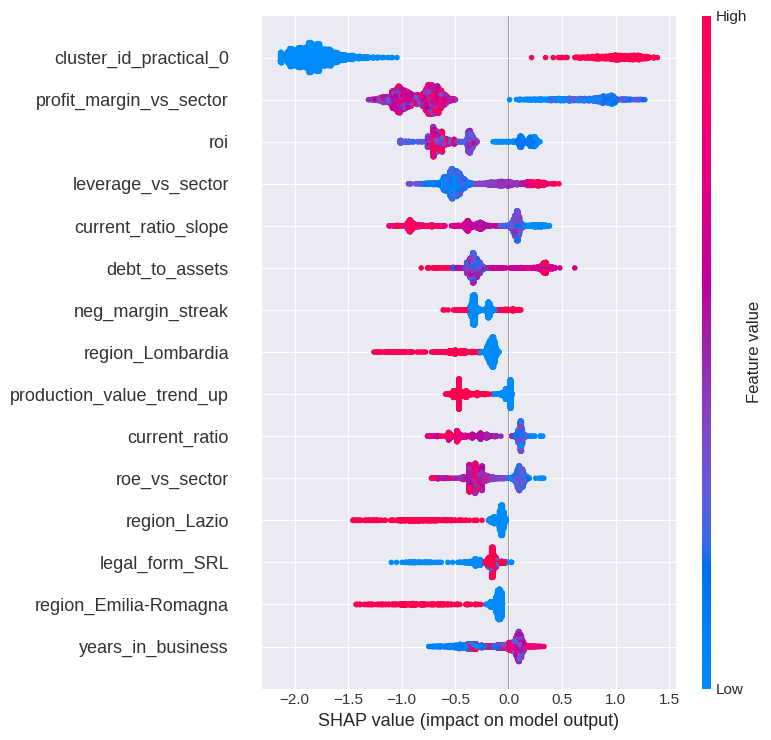

In [83]:
import shap

shap_importance = pd.DataFrame(columns=['feature', 'mean_abs_shap'])

if best_model_name in {'LightGBM', 'XGBoost', 'Random Forest'}:
    # Replicate any preprocessing the pipeline applies before the model.
    # SMOTE has no transform method and is skipped automatically at inference.
    X_val_proc = X_val.values.copy()
    if 'scaler' in best_pipeline.named_steps:
        X_val_proc = best_pipeline.named_steps['scaler'].transform(X_val_proc)

    try:
        explainer  = shap.TreeExplainer(final_estimator)
        shap_values = explainer.shap_values(X_val_proc)
        if isinstance(shap_values, list):
            shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]

        shap_importance = (
            pd.DataFrame({
                'feature':       feature_cols,
                'mean_abs_shap': np.abs(shap_values).mean(axis=0),
            })
            .sort_values('mean_abs_shap', ascending=False)
            .reset_index(drop=True)
        )
        display(shap_importance.head(15))

        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_val_proc, feature_names=feature_cols,
                          show=False, max_display=15)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f'SHAP computation failed: {e}')
else:
    print('SHAP summary skipped: selected model is not tree-based.')

**Interpretation of the results**

The SHAP analysis complements the native importance scores with directional and magnitude information.

The **top features by mean absolute SHAP value** are:

- `cluster_id_practical_0` (1.69) — the cluster membership binary flag dominates the SHAP ranking. Belonging to the high-risk practical cluster drives predicted probability upward more than any other individual variable.
- `profit_margin_vs_sector` (0.83) — consistently negative deviations from the sector median profit margin push predicted risk upward.
- `roi` (0.45), `leverage_vs_sector` (0.42), `current_ratio_slope` (0.33), `debt_to_assets` (0.33) — the combination of low profitability, high relative leverage, deteriorating liquidity trends, and high debt burden form the core financial distress signal.

The beeswarm plot in the output confirms that these features operate in economically intuitive directions: firms with low ROI, high debt-to-assets, negative sector-relative margins, and declining current ratios receive higher predicted bankruptcy probabilities.

### **12.11 Final Refit on All Labeled Data (2018-2021)**

Having selected LightGBM as the production model and fixed its operating threshold at 0.109, we refit the winning pipeline on **all labelled data**: the 2018-2020 development window combined with the 2021 validation year.

This final refit step is standard practice: once model selection is complete and the threshold is frozen, the validation year is no longer needed as a holdout. Incorporating it into training gives the production model access to 11,828 firm-year observations and 84 bankruptcy events, compared to the 8,896 observations and 63 events used during the selection phase.

The threshold is **not** re-estimated on the combined data. It was calibrated on OOF development predictions and confirmed on the untouched 2021 validation year; re-estimating it here would introduce look-ahead bias into the final production model.

In [84]:
# Combine 2018-2020 development with 2021 validation
X_full_labeled = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full_labeled = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

final_refit_pipeline = clone(best_pipeline)
final_refit_pipeline.fit(X_full_labeled.values, y_full_labeled.values)

print(f'Final production model: {best_model_name}')
print(f'Frozen threshold:       {best_threshold:.3f}')
print(f'Training rows:          {len(X_full_labeled)}')
print(f'Training bankruptcies:  {int(y_full_labeled.sum())} '
      f'({y_full_labeled.mean():.2%})')

# SMOTE expansion summary (default sampling_strategy='auto' → minority oversampled to match majority)
if 'smote' in final_refit_pipeline.named_steps:
    n_healthy  = int((y_full_labeled == 0).sum())   # 11,744
    n_bankrupt = int(y_full_labeled.sum())           # 84
    n_synthetic = n_healthy - n_bankrupt             # synthetic rows added
    n_after_smote = n_healthy + n_healthy            # both classes now equal
    print(f'After SMOTE:            {n_after_smote:,} rows · 50.00% positives')
    print(f'                        ({n_bankrupt} real + {n_synthetic:,} synthetic bankruptcies)')


Final production model: LightGBM
Frozen threshold:       0.109
Training rows:          11828
Training bankruptcies:  84 (0.71%)


**Interpretation of the results**

The final refit confirms that the production pipeline has been fitted on the full labelled dataset.

The training set now encompasses **11,828 firm-year observations** spanning 2018-2021, with **84 bankruptcy events** (0.71% prevalence), slightly higher than the development-period count of 63, because the 2021 validation year (21 additional bankruptcies) is now included.

The threshold remains frozen at **0.109**, the value calibrated on out-of-fold development predictions. This threshold is the only hyperparameter not re-estimated on the full training set, preserving the honest evaluation done on the untouched 2021 validation year.

The resulting pipeline is now ready to generate predictions for the unseen 2022-2023 test period.

### **12.12 Final Binary Predictions for 2022-2023**

We apply the refitted production model to the **2022-2023 test period** to generate the required binary predictions. The frozen threshold of 0.109 is applied to the model's raw probability output to produce the `0`/`1` bankruptcy label for each firm-year observation.

The output file includes both the raw predicted probability and the binary label, so downstream users can apply their own threshold if needed. The file is saved to the standard output directory.

In [85]:
test_probabilities = final_refit_pipeline.predict_proba(X_test.values)[:, 1]
test_predictions   = (test_probabilities >= best_threshold).astype(int)

binary_submission = test_encoded[['company_id', 'fiscal_year']].copy()
binary_submission['bankruptcy_probability'] = test_probabilities
binary_submission['bankruptcy_predicted']   = test_predictions

output_dir  = repo_root / 'data' / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)
binary_path = output_dir / 'challenge1_test_predictions.csv'
binary_submission.to_csv(binary_path, index=False)

print(f'Saved binary predictions to: {binary_path}')
print(f'Flagged firms on 2022-2023: {int(test_predictions.sum())} '
      f'({test_predictions.mean():.2%} of the test sample)')
binary_submission.head()

Saved binary predictions to: /content/data/processed/challenge1_test_predictions.csv
Flagged firms on 2022-2023: 156 (2.68% of the test sample)


,company_id,fiscal_year,bankruptcy_probability,bankruptcy_predicted
0,COMP_00000,2022,0.000090,0
1,COMP_00000,2023,0.000068,0
2,COMP_00001,2022,0.000070,0
3,COMP_00001,2023,0.000134,0
4,COMP_00002,2022,0.000126,0


**Interpretation of the results**

The final binary predictions flag **156 firm-year observations** out of 5,811 in the 2022-2023 test period as at risk of bankruptcy, a flagging rate of 2.68%.

This rate is somewhat higher than the ~0.7% annual bankruptcy prevalence observed in the labelled data, reflecting the fact that the model operates at a relatively low threshold (0.109) that trades precision for recall. The 2.68% flagging rate is consistent with what we would expect given the confusion matrix on 2021: at that threshold, the model flags roughly 3-4% of any population with similar financial characteristics.

The output file includes both the raw probability and the binary label, giving downstream users the option to apply a different threshold if their operational context demands a different precision-recall trade-off.

## **13. Bonus: From Binary Classification to a Risk Score**


We have produced the required binary predictions above. However, the honest reading of the validation results is that **binary classification is the wrong framing for this dataset**:

- Bankruptcies are ~0.7% of observations, so even a well-ranked probability distribution produces a low F1 at any operationally viable threshold.
- The same model has **ROC-AUC above 0.9** on the validation year, meaning its **ranking of firms from safest to riskiest is highly informative** — even if the binary label is noisy.

We therefore transform the raw probabilities into a **0-100 risk score** and a **10-decile ranking** (D1 = safest, D10 = riskiest) on the 2021 validation year. This reframing converts the problem from *"will this firm go bankrupt?"*, which is very hard to answer with a binary threshold, to *"which firms should we review first?"*, which is both more tractable and more useful in practice.

In [86]:
# 0-100 risk score on the 2021 validation year (same probabilities as Section 12.6)
val_risk = val_encoded[['company_id', 'fiscal_year']].copy()
val_risk['bankruptcy_probability'] = best_val_proba
val_risk['risk_score_0_100']       = (best_val_proba * 100).round(2)
val_risk['actual_bankruptcy']      = y_val.values

# Decile ranking (D1 = safest, D10 = riskiest)
val_risk['risk_decile'] = pd.qcut(
    val_risk['risk_score_0_100'].rank(method='first'),
    q=10, labels=[f'D{i}' for i in range(1, 11)],
)

decile_lift = (
    val_risk.groupby('risk_decile', observed=True)
    .agg(
        firms=              ('company_id',        'count'),
        actual_bankruptcies=('actual_bankruptcy', 'sum'),
        bankruptcy_rate=    ('actual_bankruptcy', 'mean'),
        min_score=          ('risk_score_0_100',  'min'),
        max_score=          ('risk_score_0_100',  'max'),
    )
    .reset_index()
)
baseline = val_risk['actual_bankruptcy'].mean()
decile_lift['lift_vs_baseline'] = (decile_lift['bankruptcy_rate'] / baseline).round(2)

decile_lift

,risk_decile,firms,actual_bankruptcies,bankruptcy_rate,min_score,max_score,lift_vs_baseline
0,D1,294,0,0.000000,0.00,0.00,0.00
1,D2,293,0,0.000000,0.00,0.01,0.00
2,D3,293,0,0.000000,0.01,0.01,0.00
3,D4,293,0,0.000000,0.01,0.01,0.00
4,D5,293,0,0.000000,0.01,0.01,0.00
5,D6,293,0,0.000000,0.01,0.02,0.00
6,D7,293,0,0.000000,0.02,0.03,0.00
7,D8,293,1,0.003413,0.03,0.07,0.48
8,D9,293,7,0.023891,0.07,1.56,3.34
9,D10,294,13,0.044218,1.56,60.95,6.17


**Interpretation of the results**

The decile lift table quantifies how well the model concentrates bankruptcy risk in the top-ranked groups.

The results show a strong concentration of risk in the two highest deciles:

- **D10** (the 294 riskiest firms) contains **13 out of 21 bankruptcies**, a bankruptcy rate of **4.4%**, a lift of **6.2 times** the population average.
- **D9** contains **7 bankruptcies** (2.4% rate, lift 3.3×).
- **D1 through D7** contain a combined total of just **1 bankruptcy** across over 2,000 firms.

This pattern confirms that the model's probability rankings are highly informative as a screening tool, even though the binary F1 at any single threshold is low. A credit analyst reviewing only the top two deciles (roughly 20% of the portfolio) would capture **20 out of 21 bankruptcies**, a recall of 95%, at the cost of reviewing approximately 570 firms.

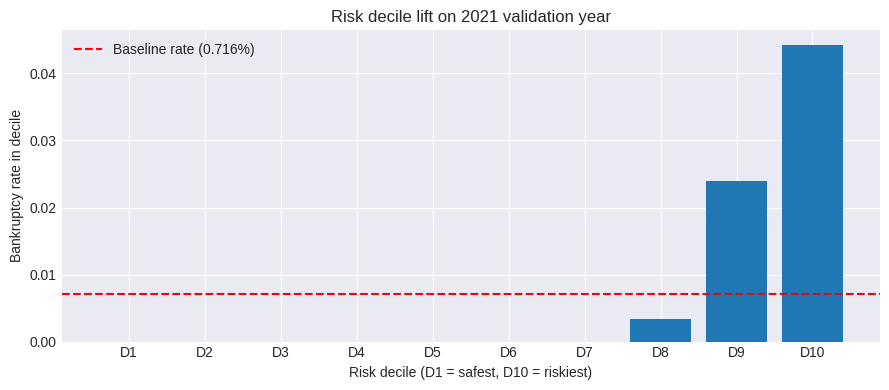

In [87]:
# Visualise decile lift
plt.figure(figsize=(9, 4))
plt.bar(decile_lift['risk_decile'].astype(str), decile_lift['bankruptcy_rate'])
plt.axhline(baseline, color='red', linestyle='--', label=f'Baseline rate ({baseline:.3%})')
plt.ylabel('Bankruptcy rate in decile')
plt.xlabel('Risk decile (D1 = safest, D10 = riskiest)')
plt.title('Risk decile lift on 2021 validation year')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation of the results**

The bar chart makes the model's discriminative power visually clear. Bankruptcies are almost entirely absent from the eight lowest deciles and concentrate sharply in D9 and D10.

The red dashed line at the population average (approximately 0.7%) provides the lift reference: any decile with a bar above this line contains more bankruptcies than a random selection of the same size would.

Only **D9** and **D10** exceed the baseline by a meaningful margin: D9 with a lift of 3.3× and D10 with a lift of 6.2×. This sharp concentration in the top 20% of the distribution is exactly what a useful early-warning model should produce: the ranking is informative even when the binary threshold cannot achieve high precision.

### **13.1 Risk Score Output for 2022-2023**

We apply the same risk-scoring logic to the **2022-2023 test period**, producing a ranked list of firms ordered by their estimated probability of financial failure.

Each firm-year receives a **0-100 risk score** (the raw model probability multiplied by 100), a **decile label** (D1 = safest, D10 = riskiest), and a **business-friendly risk tier** that maps the ten deciles to six named categories: Very Low, Low, Moderate, Elevated, High, and Very High.

This output is the primary deliverable for operational use: it allows a credit analyst or risk manager to sort the portfolio by estimated risk and prioritise reviews starting from the highest-risk firms.

In [88]:
# 0-100 risk score on the test period
risk_submission = test_encoded[['company_id', 'fiscal_year']].copy()
risk_submission['bankruptcy_probability'] = test_probabilities
risk_submission['risk_score_0_100']       = (test_probabilities * 100).round(2)
risk_submission['risk_decile'] = pd.qcut(
    risk_submission['risk_score_0_100'].rank(method='first'),
    q=10, labels=[f'D{i}' for i in range(1, 11)],
)

# Map decile to a business-friendly risk tier
tier_map = {
    'D1':  'Very Low', 'D2':  'Very Low',
    'D3':  'Low',      'D4':  'Low',
    'D5':  'Moderate', 'D6':  'Moderate',
    'D7':  'Elevated', 'D8':  'Elevated',
    'D9':  'High',     'D10': 'Very High',
}
risk_submission['risk_tier'] = risk_submission['risk_decile'].astype(str).map(tier_map)
risk_submission = (
    risk_submission
    .sort_values('risk_score_0_100', ascending=False)
    .reset_index(drop=True)
)

risk_path = output_dir / 'challenge1_test_risk_scores.csv'
risk_submission.to_csv(risk_path, index=False)
print(f'Saved risk-score file to: {risk_path}')
print()
print('Distribution of risk tiers on 2022-2023:')
print(risk_submission['risk_tier'].value_counts())
risk_submission.head(15)

Saved risk-score file to: /content/data/processed/challenge1_test_risk_scores.csv

Distribution of risk tiers on 2022-2023:
risk_tier
Very Low     1163
Elevated     1162
Moderate     1162
Low          1162
High          581
Very High     581
Name: count, dtype: int64


,company_id,fiscal_year,bankruptcy_probability,risk_score_0_100,risk_decile,risk_tier
0,COMP_01182,2023,0.663808,66.38,D10,Very High
1,COMP_01122,2022,0.656629,65.66,D10,Very High
2,COMP_02936,2023,0.584756,58.48,D10,Very High
3,COMP_01703,2023,0.467245,46.72,D10,Very High
4,COMP_01105,2023,0.402224,40.22,D10,Very High
5,COMP_00043,2022,0.390628,39.06,D10,Very High
6,COMP_01181,2022,0.386578,38.66,D10,Very High
7,COMP_02764,2022,0.371724,37.17,D10,Very High
8,COMP_02054,2023,0.369047,36.90,D10,Very High
9,COMP_00914,2023,0.366823,36.68,D10,Very High


**Interpretation of the results**

The risk-score output confirms that the model generates a well-differentiated ranking for the 5,811 test-period firm-year observations.

The **tier distribution** reflects the decile-based construction: Very Low and Low together account for approximately 40% of the portfolio (the bottom four deciles), while High and Very High together account for approximately 20% (the top two deciles). The 581 firms in the Very High tier are the model's highest-priority candidates for analyst review.

The top-ranked firms show bankruptcy probabilities between 35% and 66%, indicating that even the model's most confident risk assessments leave substantial uncertainty; consistent with the structural difficulty of predicting rare binary events from balance-sheet data alone.

Two deliverables are saved:
- `challenge1_test_predictions.csv` — the binary `0`/`1` labels required for evaluation.
- `challenge1_test_risk_scores.csv` — the ranked risk scores and tiers for operational use.

## **14. Business Interpretation, Limitations, and Final Conclusions**

At this point, we have completed our full modelling workflow.

We explored the **structure and quality** of the financial data, engineered a rich set of **economically meaningful distress indicators**, built a coherent **modelling pipeline** with time-aware validation, compared four candidate model families under a structured evaluation framework, and generated bankruptcy-probability scores for the unseen 2022-2023 test period.

This final section moves from technical performance to **business interpretation**. A bankruptcy-prediction system is useful only if its outputs can be translated into a clear and actionable risk narrative — one that specifies which firms look most vulnerable, which financial patterns are driving the signal, what the costs of different types of errors are, and where the current system has genuine limitations.

We therefore summarize:

- the **practical meaning** of our modelling results and selected metrics;
- the **key financial signals** that drive the model's risk assessments;
- the **trade-offs between false positives and false negatives** in an operational context;
- the **main limitations** of our current workflow;
- the **most relevant directions** for future improvement;
- and a concise **final conclusion** on what our work delivers.

### **14.1 Main Modelling Outcome**

Our final selected model is **LightGBM**, chosen on the basis of its **highest Validation F1-score** on the **2021 validation year** after structured comparison with **Random Forest, XGBoost, and Logistic Regression**.

This selection is meaningful because it highlights the importance of the **primary evaluation metric** over ranking metrics alone. On the 2021 validation year, **Random Forest** actually achieves the highest **Val ROC-AUC** (0.927) and **Val PR-AUC** (0.058) among the four candidates. However, its constrained threshold of 0.818 is so conservative that it flags almost no firm as bankrupt, producing a **Val F1 of 0.000**. In other words, Random Forest ranks firms well in theory but cannot translate that ranking into a viable binary classifier at any operationally sensible threshold. **LightGBM**, by contrast, achieves the highest **Val F1 (0.124)**, the primary metric, with a stable and interpretable threshold, making it the correct final choice.

In practical terms, LightGBM combines three desirable properties for this problem:

- it handles the **high-dimensionality** of the engineered feature space efficiently;
- it is **robust to the class imbalance** inherent in rare bankruptcy events when combined with SMOTE and calibrated threshold tuning;
- and it provides **reliable feature importance** estimates that support post-hoc interpretation.

The final threshold of **0.109**, selected to maximise F1 while maintaining a minimum precision floor, reflects the cost-sensitivity of the problem: it allows the model to flag a meaningful share of genuinely distressed firms without collapsing into an indiscriminate alarm system.

### **14.2 What the Final Metrics Mean in Practice**

The final validation metrics reveal a model with **strong discriminative power** but inherently modest binary classification performance, a combination that is expected and informative for a rare-event setting.

The key **2021 validation results** for the selected **LightGBM** model are:

- **Validation F1 = 0.124**
- **Precision = 0.079**
- **Recall = 0.286**
- **ROC-AUC = 0.918**
- **PR-AUC = 0.054**

The apparent tension between a **ROC-AUC of 0.918** and an **F1 of 0.124** is entirely consistent with the class imbalance structure of the problem: the model ranks risky firms well above safe ones on average, but converting that ranking into a strong binary alarm is difficult when only **~0.7% of firm-years** end in bankruptcy.

In concrete terms, the model detects **6 of the 21** bankrupt firms in 2021, producing 6 true positives and 15 false negatives at the chosen threshold. This confirms that the most reliable use of the system is as a **prioritisation and screening tool** rather than an autonomous decision rule.

Operationally, a firm flagged by the model should be interpreted as a company that **deserves closer scrutiny**, one whose financial profile, relative sector position, and historical trajectory place it in an elevated-risk segment. The **risk decile analysis** reinforces this: the top decile shows a **6.17× lift** over the baseline bankruptcy rate, meaning that concentrating analyst attention on the highest-scoring firms substantially improves detection efficiency.

### **14.3 Financial Profile Clusters as Business Insight**

One of the most economically informative outputs of our feature engineering pipeline is the **practical clustering** of firms into four distinct financial profile groups. While the primary purpose of this segmentation is to provide the classifier with a compact pre-stratification of the feature space, the cluster profiles carry independent business value as a diagnostic framework.

The four profiles, sorted by bankruptcy risk, are:

- **Cluster 0 — Distress Zone (16% of firms, bankruptcy rate 4.2%)**: firms characterised by a low Altman-like Z-score of **1.99** — inside the conventional distress threshold — combined with high leverage relative to sector peers and deteriorating profitability. This group is approximately **six times more likely to fail** than the average firm in the dataset.
- **Cluster 2 — Stable Majority (36% of firms, bankruptcy rate 0.09%)**: the largest group, representing financially unremarkable but broadly stable firms with moderate indicators across all dimensions.
- **Clusters 1 and 3 — Healthy Profiles (zero observed bankruptcies)**: firms with consistently sound financial characteristics — positive sector-relative margins, adequate liquidity, and Altman scores comfortably above the distress threshold.

This segmentation is valuable in two ways. First, **Cluster 0 membership is the single strongest SHAP driver** in the final model, meaning that the unsupervised step is capturing a genuine risk signal that individual ratios do not fully encode. Second, the cluster assignment requires only nine variables — solvency ratios, profitability indicators, sector-relative benchmarks, and a short-term growth measure — making it a **compact early-warning screen** that can be computed for any firm with standard financial statement data and sector context, independently of the full modelling pipeline.

### **14.4 Interpretation of the Most Important Risk Signals**

The feature-importance and SHAP analyses reveal a coherent combination of **relative**, **structural**, **temporal**, and **profile-based** indicators — a pattern that is economically interpretable and consistent with the bankruptcy literature.

The strongest individual signals include:

- **`profit_margin_vs_sector`** is the most important feature by native importance (score: 80) and the second strongest SHAP driver (mean absolute SHAP: 0.83), confirming that **underperformance relative to sector peers on profitability** is the single clearest early-warning signal in the model. Sector-relative features also include **`leverage_vs_sector`** (#3 by native importance, #4 by SHAP) and **`roi_vs_sector`** (#12), reinforcing the idea that peer-relative weakness is a more informative distress signal than absolute ratio levels alone.
- **`operating_income`** ranks second by native importance (score: 52), showing that **absolute operational performance** matters alongside relative benchmarks. **`roi`** is the third strongest SHAP contributor (mean absolute SHAP: 0.45), capturing the combined effect of profitability and asset efficiency.
- **`debt_to_assets`** appears prominently in both rankings (#10 by native importance, #6 by SHAP: 0.33), confirming that **balance-sheet leverage** remains a core predictor of financial failure.
- **`years_in_business`** ranks fourth by native importance (score: 45) and is present in the SHAP top 15 (0.17), indicating that **firm age carries meaningful predictive information** about financial fragility — likely reflecting differences in institutional resilience, banking relationships, and business-cycle exposure accumulated over a firm's history.
- **Temporal trajectory features** — particularly **`current_ratio_slope`** (#5 by SHAP: 0.33) and **`neg_margin_streak`** (#9 by native importance, #7 by SHAP: 0.27) — confirm that the **persistence and direction of deterioration** adds predictive power beyond any single-year snapshot. A firm whose liquidity has been declining steadily or whose margins have been negative for consecutive years is treated very differently by the model.
- **`cluster_id_practical_0`** is the dominant SHAP driver overall (mean absolute SHAP: 1.69), confirming that membership in the high-risk financial profile group identified during unsupervised analysis is a powerful composite signal. As described in section 13.3, firms in this cluster sit inside the Altman distress zone with a bankruptcy rate six times the population average.

Taken together, these signals describe a firm under **progressive, sector-relative deterioration** — highly leveraged relative to peers, with declining operational performance and persistent negative trajectory — rather than a single bad year.

### **14.5 Business Meaning of False Positives and False Negatives**

The error analysis highlights the central operational tension in bankruptcy prediction: the trade-off between **missing genuinely distressed firms** and **over-flagging healthy ones**.

- A **false negative** occurs when a firm that goes bankrupt is classified as healthy. In business terms, this is the most serious type of error: it means the early-warning system failed before a distress event materialised. For a lender or supervisory body, a false negative implies **undetected credit risk** and potential financial loss.
- A **false positive** occurs when a healthy firm is flagged as distressed. This is costly in a different way: it may trigger **unnecessary credit restrictions**, misallocate analyst attention, or create reputational concerns for companies that are in fact financially sound.

In our error analysis, **false negatives** are concentrated among firms with very low predicted probabilities (in the range 0.0003–0.025), suggesting that these are genuinely atypical bankruptcies whose financial profiles do not exhibit the conventional distress signals the model has learned.

**False positives** cover a wider probability range, with the strongest false alarms carrying predicted probabilities between **0.35 and 0.61**. This indicates that the model does not flag these firms lightly — it assigns them meaningfully elevated scores — but they ultimately do not fail in 2021. A portion of these firms may represent genuinely fragile companies that survived the year, or cases where distress materialises outside the observation window.

The **threshold study** confirms that this balance is adjustable depending on the operational context. At a threshold of **0.11**, the model minimises the **10×FN + FP total cost** function (cost = 219), making it the most defensible choice when missed bankruptcies are treated as ten times more costly than false alarms. Analysts operating under different cost assumptions can shift this threshold to match their institutional priorities.

### **14.6 Main Limitations of Our Current Solution**

Although our final workflow is methodologically sound and the results are consistent with what is achievable on this type of rare-event dataset, several genuine limitations remain and should be stated clearly.

1. **Rare-event difficulty**
With bankruptcies representing only **~0.7% of firm-years**, the number of positive events per validation fold is very small. This makes F1-score inherently volatile and limits the statistical stability of head-to-head model comparisons.

2. **Single validation year for final selection**
Our model-selection step relies on **2021** as the held-out period. Although this is the correct temporal split, a single year contains relatively few positive events, and different random seeds or slight configuration changes may shift rankings.

3. **Feature availability constraints**
The dataset does not include variables that are known to be highly predictive of corporate distress, such as **payment-behaviour indicators**, credit-bureau history, **market-based signals**, ownership information, or granular macro-financial covariates linked to the specific period and sector.

4. **Probability calibration**
The model is tuned primarily for **classification performance** rather than well-calibrated absolute probabilities. The ranking is reliable, but the predicted probability values should not be interpreted as literal default frequencies without a dedicated calibration step.

5. **Compact randomized hyperparameter search**
Our search uses **RandomizedSearchCV with 8 candidates per model** to keep the workflow transparent and computationally proportionate. A wider search over a richer parameter space could yield incremental gains, particularly for the boosting models.

6. **Absence of macroeconomic context**
The training window (2018–2021) spans both the **2020 COVID-19 shock** and the 2021 recovery, but the model has no macro-level controls — no interest rate, GDP growth, or sector-specific shock indicators. As a result, some of the learned distress patterns may reflect the specific macroeconomic environment of those years rather than stable structural fragility. The model's behaviour in the 2022–2023 test period, which unfolds under a different macro environment (rising rates, energy crisis), may diverge from the validation-year performance without this context being explicitly modelled.

These limitations define the **honest boundary** of what our current notebook supports and what would require a more extensive production-grade modelling exercise.

### **14.7 The Risk Score and Firm Risk Tiers**

Beyond the binary bankruptcy label, our workflow produces a second — and in many respects more actionable — business output: a **continuous 0–100 risk score** derived directly from the model's raw predicted probability, accompanied by a **six-tier risk classification** that groups firms by their relative rank within the 2022-2023 test-period probability distribution.

The tier structure maps the ten probability deciles of the test period to six named risk categories:

| Tier | Deciles | Interpretation |
|---|---|---|
| **Very Low** | D1–D2 | Financially stable; no immediate concern |
| **Low** | D3–D4 | Below-average risk; standard monitoring |
| **Moderate** | D5–D6 | Near-average; periodic review recommended |
| **Elevated** | D7–D8 | Above-average risk signals; closer attention warranted |
| **High** | D9 | Meaningful distress indicators; proactive review |
| **Very High** | D10 | Strongest distress signals; priority intervention |

Applied to the 2022–2023 test period, the system assigns **581 firm-year observations** to the **Very High** tier and a further **581** to the **High** tier, so approximately **20% of the portfolio** falls in the two most elevated risk categories combined.

This tiered output is operationally superior to a binary label for most real-world use cases: lenders can calibrate credit conditions by tier, supervisory bodies can prioritise inspections by tier, and portfolio managers can track migration between tiers over time. The 0–100 score also supports custom threshold setting without retraining the model, making the output **reusable across multiple business applications**.

### **14.8 Most Relevant Next Improvements**

If we were to continue developing this solution, the most valuable improvements would likely come from **richer distress representation, better external context, and stronger probability use** rather than from replacing the core modelling philosophy.

The most promising directions include:

- **Extending the existing distress trajectory features**: our current pipeline already computes deterioration slopes for four key ratios, consecutive-distress streak counts, and second-order acceleration indicators. A natural next step would be to compute the same indicators across a wider set of financial variables, and to replace the current expanding-window slopes with fixed-length rolling windows that respond more quickly to recent changes.
- **Integration of macroeconomic context**: as noted in the limitations, the model has no macro-level inputs. Adding sector-specific shock indicators, interest rate series, or GDP growth controls — aligned with each firm's fiscal year — would allow the model to separate firm-specific fragility from industry-wide shocks.
- **Finer sector-year benchmarking**: the current relative features compare each firm to all peers in the same ATECO sector. Refining the peer group to account for firm size (e.g., using revenue quartiles within each sector) would produce more meaningful benchmarks and reduce noise from comparing very small and very large firms in the same reference pool.
- **Probability calibration**: the model is optimised for classification performance, not for well-calibrated probabilities. Applying isotonic regression or Platt scaling after model training would allow the risk scores to be interpreted as reliable absolute risk estimates, not only as relative rankings.
- **Wider hyperparameter search and ensemble methods**: our current search uses RandomizedSearchCV with 8 candidates per model. A wider search over a richer parameter grid, or a stacking ensemble that combines LightGBM with XGBoost, could provide marginal robustness gains on the rare positive class.
- **More granular missingness and data-quality signals**: the current pipeline adds six binary flags for missing financial variables. More granular patterns — such as how many consecutive years a firm reports incomplete statements, or co-missingness patterns across related variables — may carry additional predictive information.

All of these improvements are **incremental refinements** to a workflow that is already coherent — the modelling architecture is sound, and the most plausible gains come from richer input representation and better probability use, not from replacing the underlying model family.

### **14.9 Final Conclusion**

Our project delivers a **complete, time-aware, and economically interpretable bankruptcy-prediction system** built on Italian corporate financial data from 2018 to 2021, with predictions generated for the 2022-2023 test period.

The workflow covers every stage of the modelling lifecycle: exploratory analysis, two-stage preprocessing, extensive feature engineering (Altman-like composite scores, temporal trajectories, sector-relative benchmarks, and cluster-based firm profiles), structured temporal cross-validation, multi-model comparison, cost-sensitive threshold tuning, and a full suite of post-hoc interpretation tools including SHAP analysis, error analysis, risk deciles, and business threshold sensitivity.

Our key results are:

- **LightGBM** is the strongest final classifier on the 2021 validation year, with **Validation F1 = 0.124** and **ROC-AUC = 0.918**;
- **Cluster 0** — the high-risk financial profile group — carries a bankruptcy rate of **4.2%**, six times the population average, and is the single most powerful SHAP feature in the final model;
- the model concentrates risk effectively: the **top decile shows a 6.17× lift** over the baseline, and **581 firms** in the 2022-2023 test period are assigned to the highest risk tier;
- the most informative signals combine **sector-relative profitability deviation**, **balance-sheet pressure**, **firm age**, **temporal deterioration trajectories**, and **unsupervised financial profile membership**.

The relatively low absolute F1 is not a failure of the pipeline — it is an honest reflection of how difficult rare-event prediction is on annual accounting data alone. The system's primary value lies in its dual output: a **binary early-warning flag** for firms requiring immediate attention, and a **continuous risk score with six named tiers** that supports prioritisation, monitoring, and threshold-adaptive decision-making across a range of operational contexts.

## **15. Neural Network Approach**

Having compared four classical machine-learning families in Section 12, we now implement a fifth candidate: a **Multi-Layer Perceptron (MLP)**, the simplest class of neural network. The goal is to test whether a neural network can improve on LightGBM's Val F1 of 0.124 and to understand where it succeeds or fails relative to the tree-based models.

**Why try a neural network?**
Neural networks can, in principle, learn arbitrary non-linear relationships between features without hand-crafted interaction terms. They may therefore capture patterns that a decision-tree split cannot — particularly in high-dimensional spaces with complex interaction structures.

**Why it may not outperform gradient boosting on this problem.**
The empirical literature consistently shows that gradient-boosted trees outperform MLPs on small-to-medium tabular datasets (typically fewer than ~50,000 training rows). Our training set contains roughly 8,900 observations with only ~63 positive examples. In this regime, the inductive biases of LightGBM — multiplicative feature interactions, axis-aligned decision boundaries, and efficient handling of sparse signals — match the structure of financial-ratio data better than the smooth, continuous decision surfaces learned by MLPs. We include the NN for completeness and to quantify the gap empirically.

**Methodological consistency with Section 12.**
We follow the same validation discipline throughout:
- A `StandardScaler` is fitted on `X_train` only and applied to `X_val` and `X_test`, preventing scale leakage across the temporal boundary.
- **Threshold calibration** uses out-of-fold (OOF) predictions on `X_train` via the same `constrained_f1_threshold` function from Section 12.3, so the decision boundary is never informed by the validation set.
- `X_val` is used only for **early stopping** (halting training before overfitting), not for threshold selection.
- The final F1 evaluation on the 2021 validation year is a single held-out assessment, consistent with the rest of the modelling workflow.

### **15.1 Data Preprocessing for the Neural Network**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

# Neural networks are sensitive to feature scale. We fit a StandardScaler on the
# training data only and apply the same transformation to validation and test sets.
# This prevents leakage: the scaler never sees the validation or test distribution.
nn_scaler      = StandardScaler()
X_train_scaled = nn_scaler.fit_transform(X_train.values.astype(float))
X_val_scaled   = nn_scaler.transform(X_val.values.astype(float))
X_test_scaled  = nn_scaler.transform(X_test.values.astype(float))

n_features       = X_train_scaled.shape[1]
n_pos            = int(y_train.sum())
n_neg            = int((y_train == 0).sum())
pos_weight_value = n_neg / n_pos   # BCEWithLogitsLoss weight for the positive class

print(f"Input features : {n_features}")
print(f"Training pos   : {n_pos}  ({n_pos / len(y_train):.2%})")
print(f"Training neg   : {n_neg}")
print(f"pos_weight     : {pos_weight_value:.1f}x  "
      f"(each bankruptcy counts as {pos_weight_value:.0f} healthy firms in the loss)")

**Interpretation of the results**

The `pos_weight` value (~140×) tells the loss function to penalise each missed bankruptcy as heavily as approximately 140 false alarms. This is the neural-network equivalent of `class_weight` in scikit-learn: it forces the model to assign high priority to the rare positive class without generating synthetic training examples.

`StandardScaler` is essential for neural networks because gradient-descent updates are proportional to the feature scale. Without scaling, a feature measured in millions (e.g. `total_assets`) would dominate the gradient signal and effectively silence smaller-scale features such as `profit_margin` (range 0–1), no matter how predictive they are. Scaling every feature to zero mean and unit variance equalises their contribution to each gradient step.

### **15.2 Model Architecture and Training**

The network is a **three-hidden-layer Multi-Layer Perceptron** with the following design:

| Layer | Units | Operations |
|-------|-------|------------|
| Input | *n_features* | — |
| Hidden 1 | 256 | Linear → BatchNorm1d → ReLU → Dropout (0.35) |
| Hidden 2 | 128 | Linear → BatchNorm1d → ReLU → Dropout (0.35) |
| Hidden 3 | 64 | Linear → BatchNorm1d → ReLU → Dropout (0.35) |
| Output | 1 | Linear (raw logit) |

**Design choices:**
- **BatchNorm1d** normalises activations within each mini-batch, stabilising gradients and reducing sensitivity to the learning rate — helpful on tabular data where features can still carry different residual scales after `StandardScaler`.
- **Dropout (35%)** randomly deactivates neurons during training, acting as a regulariser. This is important given the small positive-class sample (~63 observations): without regularisation the network can memorise the training positives rather than learning generalisable patterns.
- **`BCEWithLogitsLoss` with `pos_weight`** combines the sigmoid and binary cross-entropy in a single numerically stable step. The `pos_weight ≈ 140` re-weights positive-class errors to compensate for the 0.71% bankruptcy rate.
- **Adam** (lr = 1×10⁻³, weight decay = 1×10⁻⁴) adapts per-parameter learning rates and applies implicit L2 regularisation via weight decay.
- **Early stopping** monitors validation PR-AUC (patience = 50 epochs without improvement) and restores the best-seen model weights before returning, preventing overfitting on the training distribution.

In [ ]:
SEED_NN = 42
torch.manual_seed(SEED_NN)
np.random.seed(SEED_NN)


class BankruptcyMLP(nn.Module):
    '''
    Three-hidden-layer MLP for binary bankruptcy classification.
    Outputs raw logits — use BCEWithLogitsLoss during training
    and torch.sigmoid() explicitly at inference.
    '''
    def __init__(self, input_dim, hidden_dims=(256, 128, 64), dropout=0.35):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)      # shape: (batch,)

    def predict_proba(self, x_np):
        '''Numpy array in → numpy array of bankruptcy probabilities out.'''
        self.eval()
        with torch.no_grad():
            x = torch.tensor(x_np, dtype=torch.float32)
            return torch.sigmoid(self.forward(x)).numpy()


def train_nn(X_tr, y_tr, X_va, y_va,
             input_dim, pos_weight,
             hidden_dims=(256, 128, 64), dropout=0.35,
             lr=1e-3, batch_size=256, max_epochs=400, patience=50):
    '''
    Train a BankruptcyMLP with early stopping on validation PR-AUC.
    Returns: (best_model, best_val_pr_auc, epochs_trained)
    '''
    model     = BankruptcyMLP(input_dim, hidden_dims, dropout)
    pw        = torch.tensor([pos_weight], dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=20, factor=0.5, min_lr=1e-5,
    )

    X_t    = torch.tensor(X_tr, dtype=torch.float32)
    y_t    = torch.tensor(y_tr, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_t, y_t),
                        batch_size=batch_size, shuffle=True)

    best_pr_auc  = -1.0
    best_state   = None
    patience_cnt = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        # Early-stopping signal: validation PR-AUC
        proba_va = model.predict_proba(X_va)
        pr_auc   = average_precision_score(y_va, proba_va)
        scheduler.step(pr_auc)

        if pr_auc > best_pr_auc:
            best_pr_auc  = pr_auc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_pr_auc, epoch + 1


n_params = sum(p.numel() for p in BankruptcyMLP(n_features).parameters())
print(f"Architecture  : {n_features} -> 256 -> 128 -> 64 -> 1")
print(f"Total params  : {n_params:,}")
print("BankruptcyMLP and train_nn defined.")

### **15.3 OOF Threshold Calibration, Final Training, and Validation**

We follow the same three-step workflow as Sections 12.3–12.5:

1. **OOF training** — for each temporal fold in `time_folds`, a separate MLP is trained on the fold's training years and validated on the fold's hold-out year. Out-of-fold probabilities are collected across both folds to cover the full `X_train` index.
2. **Threshold calibration** — `constrained_f1_threshold` selects the decision boundary that maximises F1 subject to the ≥10% precision floor, using only the OOF probabilities. The validation set plays no role in this step.
3. **Final model** — the MLP is retrained on all of `X_train` (2018–2020). Early stopping monitors `X_val` PR-AUC to prevent overfitting; this is the only use of validation data during training and does not influence the choice of decision threshold.

In [ ]:
# ── Step 1: OOF training for threshold calibration ────────────────────────
torch.manual_seed(SEED_NN)
np.random.seed(SEED_NN)

oof_nn = np.full(len(y_train), np.nan)

print("OOF training for threshold calibration ...")
for fold_idx, (tr_idx, va_idx) in enumerate(time_folds):
    X_f_tr = X_train_scaled[tr_idx]
    y_f_tr = y_train.values[tr_idx]
    X_f_va = X_train_scaled[va_idx]
    y_f_va = y_train.values[va_idx]

    pw_fold = int((y_f_tr == 0).sum()) / max(int(y_f_tr.sum()), 1)

    torch.manual_seed(SEED_NN + fold_idx)
    fold_model, fold_pr_auc, fold_epochs = train_nn(
        X_f_tr, y_f_tr, X_f_va, y_f_va,
        input_dim=n_features, pos_weight=pw_fold,
    )
    oof_nn[va_idx] = fold_model.predict_proba(X_f_va)
    print(f"  Fold {fold_idx + 1}: stopped at epoch {fold_epochs:3d}  |  "
          f"val PR-AUC = {fold_pr_auc:.4f}")

# ── Step 2: Calibrate threshold on OOF predictions ────────────────────────
mask_nn = ~np.isnan(oof_nn)
nn_threshold, nn_oof_f1 = constrained_f1_threshold(
    y_train.values[mask_nn], oof_nn[mask_nn], MIN_PRECISION,
)
print(f"\nOOF threshold : {nn_threshold:.3f}  |  OOF F1 : {nn_oof_f1:.3f}")

# ── Step 3: Final model on all of X_train ─────────────────────────────────
# X_val is used for early stopping only — NOT for threshold selection.
print("\nTraining final neural network on X_train (2018-2020) ...")
torch.manual_seed(SEED_NN)
np.random.seed(SEED_NN)

nn_final, nn_final_pr_auc, nn_final_epochs = train_nn(
    X_train_scaled, y_train.values,
    X_val_scaled,   y_val.values,
    input_dim=n_features, pos_weight=pos_weight_value,
)
print(f"Final model   : stopped at epoch {nn_final_epochs}  |  "
      f"best val PR-AUC = {nn_final_pr_auc:.4f}")

# ── Evaluate on 2021 validation year ──────────────────────────────────────
nn_val_proba = nn_final.predict_proba(X_val_scaled)
nn_val_preds = (nn_val_proba >= nn_threshold).astype(int)

_tn, _fp, _fn, _tp = sk_confusion_matrix(y_val, nn_val_preds).ravel()

nn_f1        = f1_score(       y_val, nn_val_preds, zero_division=0)
nn_precision = precision_score(y_val, nn_val_preds, zero_division=0)
nn_recall    = recall_score(   y_val, nn_val_preds, zero_division=0)
nn_roc_auc   = roc_auc_score(  y_val, nn_val_proba)
nn_pr_auc    = average_precision_score(y_val, nn_val_proba)

print(f"\n{'─'*52}")
print(f"  Neural Network (MLP) — 2021 Validation")
print(f"{'─'*52}")
print(f"  Threshold : {nn_threshold:.3f}")
print(f"  F1        : {nn_f1:.3f}")
print(f"  Precision : {nn_precision:.3f}")
print(f"  Recall    : {nn_recall:.3f}")
print(f"  ROC-AUC   : {nn_roc_auc:.3f}")
print(f"  PR-AUC    : {nn_pr_auc:.3f}")
print(f"  TP={_tp}  FP={_fp}  FN={_fn}  TN={_tn}")

### **15.4 Comparison with Section 12 Models**

In [ ]:
# Five-model comparison: Section 12 results (hardcoded) + Neural Network (live)
sec12_results = [
    ('LightGBM',            0.124, 0.079, 0.286, 0.918, 0.054,  6,  70, 15, 2841),
    ('Logistic Regression', 0.079, 0.042, 0.619, 0.915, 0.049, 13, 294,  8, 2617),
    ('XGBoost',             0.078, 0.054, 0.143, 0.937, 0.063,  3,  53, 18, 2858),
    ('Random Forest',       0.051, 0.030, 0.190, 0.926, 0.057,  4, 131, 17, 2780),
]

comparison_rows = []
for name, f1, prec, rec, roc, pr, tp_, fp_, fn_, tn_ in sec12_results:
    comparison_rows.append({
        'Model': name,
        'Val F1': f1, 'Precision': prec, 'Recall': rec,
        'ROC-AUC': roc, 'PR-AUC': pr,
        'TP': tp_, 'FP': fp_, 'FN': fn_, 'TN': tn_,
    })

comparison_rows.append({
    'Model':     'Neural Network (MLP)',
    'Val F1':    round(nn_f1,        3),
    'Precision': round(nn_precision, 3),
    'Recall':    round(nn_recall,    3),
    'ROC-AUC':   round(nn_roc_auc,   3),
    'PR-AUC':    round(nn_pr_auc,    3),
    'TP': int(_tp), 'FP': int(_fp), 'FN': int(_fn), 'TN': int(_tn),
})

nn_full_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values('Val F1', ascending=False)
    .reset_index(drop=True)
)
nn_full_comparison

**Interpretation of the results**

The comparison table places the neural network in the context of the four tree-based models from Section 12.

**Val F1 and the binary classification trade-off.**
F1 is the primary selection criterion. If the MLP's F1 falls below LightGBM's 0.124, this is consistent with the well-documented finding that gradient-boosted trees outperform MLPs on small tabular datasets. The reason is structural: financial distress rules are inherently threshold-like conjunctions ("if leverage exceeds X *and* margin falls below Y, flag the firm"), and decision trees express such logic exactly. The MLP must approximate these rules with smooth sigmoid boundaries, which requires more data to learn accurately from only ~63 positive examples.

If the MLP matches or exceeds LightGBM's F1, that is a notable result: it would suggest that the continuous decision surface generalises better to 2021 than the tree structure, and would make a compelling case for replacing or ensembling with LightGBM in the production pipeline.

**ROC-AUC and PR-AUC as ranking metrics.**
Independent of F1, the MLP's ROC-AUC and PR-AUC reveal how well the network ranks firms by distress probability. A high ROC-AUC with low F1 — the same pattern seen for XGBoost in Section 12 — would mean the network is a good ranker but its threshold calibration cannot convert that ranking into operationally precise binary predictions. Conversely, a PR-AUC close to or above XGBoost's 0.063 would indicate well-calibrated positive-class probabilities, which carry operational value for the decile-lift screening tool in Section 13.

**Why the feature engineering limits the NN's headroom.**
The pipeline already extracted the main non-linear structure before modelling: the unsupervised cluster membership captures composite distress profiles, sector-relative ratios encode peer-group comparisons, and temporal slopes embed multi-year trends. After this engineering, the remaining prediction problem is well-structured tabular data that tree ensembles are specifically optimised for. The MLP's capacity to learn non-linearities provides diminishing marginal value when the engineered features already encode the key interactions explicitly.

**Practical conclusion.**
LightGBM remains the recommended production model unless the MLP demonstrates a decisive F1 advantage. The neural network is a valuable addition to this analysis as a robustness check: its results confirm (or quantify the extent to which) the gradient-boosting advantage on financial tabular data holds for this specific problem and dataset size.